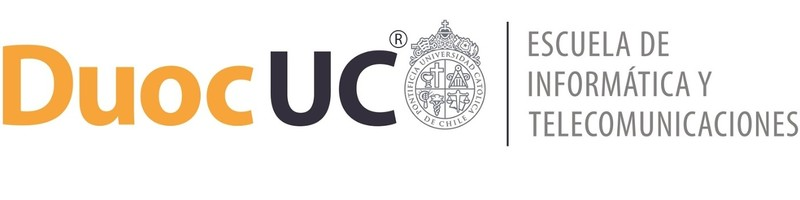


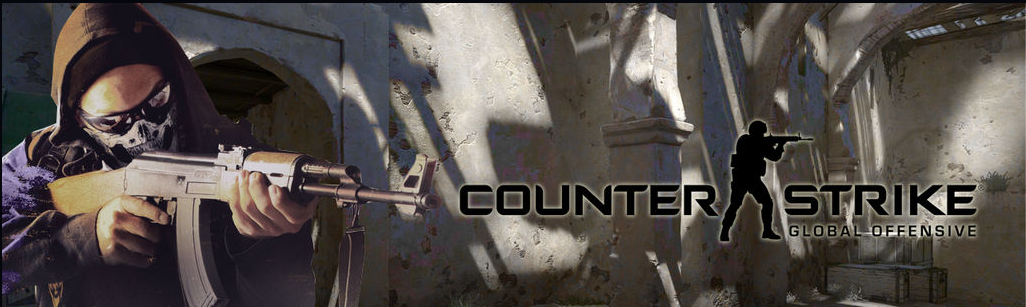


# Informe Técnico - Examen Transversal: Caso Counter Strike


Integrantes:
* Flavio Henriquez
* Jose Parra
* Pedro Campos
* Fabian Molina

Docente: Marco Japke

Sección: MLY0100

Asignatura: Fundamentos de Machine learning


**Caso Fundamentos de Machine Learning**


## Fase 1: Business Understanding


### 1.1 Contexto del caso


Counter-Strike: Global Offensive (CS:GO) es un videojuego competitivo por rondas en el que dos equipos de cinco jugadores se enfrentan en roles opuestos: Terrorist y Counter-Terrorist. El desempeño de cada ronda depende de factores económicos, tácticos y contextuales, como el mapa, el bando, el valor del equipamiento inicial, la composición de armas y las decisiones tomadas durante la partida.

Valve dispone de datos históricos extraídos desde replays y preprocesados en formato CSV. En el archivo de trabajo existen 79.157 registros y 30 variables. Cada registro representa el desempeño de un jugador dentro de una ronda, por lo que la información original se encuentra a nivel jugador-ronda. Para analizar decisiones de equipo, se propone transformar la base a nivel equipo-ronda, agrupando por `MatchId`, `RoundId` y `Team`.

El interés del proyecto es convertir estos datos históricos en una base analítica que permita comprender qué condiciones iniciales se asocian con mejores resultados competitivos y cómo esa información puede apoyar decisiones estratégicas de compra.


### 1.2 Diccionario de datos


| Variable | Descripción |
| :--- | :--- |
| `Unnamed: 0` | Índice original del archivo CSV. No representa una variable explicativa del juego. |
| `Map` | Mapa en el que se juega la ronda. |
| `Team` | Bando del jugador en la ronda: Terrorist o Counter-Terrorist. |
| `InternalTeamId` | Identificador interno del equipo dentro de la partida. |
| `MatchId` | Identificador de la partida. |
| `RoundId` | Número de ronda dentro de la partida. |
| `RoundWinner` | Indica si el equipo del registro ganó la ronda. Es la variable objetivo del problema de clasificación. |
| `MatchWinner` | Indica si el equipo del registro ganó la partida. |
| `Survived` | Indica si el jugador sobrevivió al final de la ronda. |
| `AbnormalMatch` | Indica si el registro pertenece a una partida con comportamiento anómalo. |
| `TimeAlive` | Tiempo que el jugador permaneció vivo durante la ronda. |
| `TravelledDistance` | Distancia recorrida por el jugador durante la ronda. |
| `RLethalGrenadesThrown` | Cantidad de granadas letales lanzadas por el jugador en la ronda. |
| `RNonLethalGrenadesThrown` | Cantidad de granadas no letales lanzadas por el jugador en la ronda. |
| `PrimaryAssaultRifle` | Indica uso o presencia de rifle de asalto como arma principal. |
| `PrimarySniperRifle` | Indica uso o presencia de rifle de francotirador como arma principal. |
| `PrimaryHeavy` | Indica uso o presencia de arma pesada como arma principal. |
| `PrimarySMG` | Indica uso o presencia de subfusil como arma principal. |
| `PrimaryPistol` | Indica uso o presencia de pistola como arma principal. |
| `FirstKillTime` | Tiempo en el que ocurre la primera baja registrada en la ronda. |
| `RoundKills` | Cantidad de bajas realizadas por el jugador en la ronda. |
| `RoundAssists` | Cantidad de asistencias realizadas por el jugador en la ronda. |
| `RoundHeadshots` | Cantidad de bajas con disparo a la cabeza realizadas por el jugador en la ronda. |
| `RoundFlankKills` | Cantidad de bajas por flanqueo realizadas por el jugador en la ronda. |
| `RoundStartingEquipmentValue` | Valor del equipamiento inicial del jugador al comenzar la ronda. |
| `TeamStartingEquipmentValue` | Valor total del equipamiento inicial del equipo al comenzar la ronda. |
| `MatchKills` | Cantidad de bajas acumuladas por el jugador durante la partida. |
| `MatchFlankKills` | Cantidad de bajas por flanqueo acumuladas por el jugador durante la partida. |
| `MatchAssists` | Cantidad de asistencias acumuladas por el jugador durante la partida. |
| `MatchHeadshots` | Cantidad de disparos a la cabeza acumulados por el jugador durante la partida. |


### 1.3 Descripción del problema de negocio


En CS:GO, la decisión de comprar armas y utilidad al inicio de una ronda es crítica. Un equipo puede invertir una gran cantidad de recursos y aun así perder por condiciones desfavorables de mapa, bando o composición de armas. También puede ocurrir lo contrario: ahorrar recursos en una ronda donde existían condiciones razonables para competir.

Esta incertidumbre dificulta decidir entre compra completa, compra forzada o ronda eco. Por eso, el problema de negocio se centra en comprender qué condiciones iniciales aumentan o reducen la probabilidad de victoria de un equipo en una ronda.


### 1.4 Problemática de negocio


La problemática principal es que las decisiones económicas dentro de una partida se toman bajo presión y con información incompleta. Una mala decisión de compra no solo afecta la ronda actual, sino también la economía de las rondas siguientes.

Desde una mirada práctica, se necesita una forma ordenada de relacionar economía, equipamiento, mapa y bando con el resultado competitivo. Esto permitiría apoyar a analistas, entrenadores o sistemas internos en la identificación de escenarios donde conviene invertir, forzar compra o conservar recursos.


### 1.5 Objetivo general del proyecto


Desarrollar y evaluar una propuesta de modelado predictivo que estime la probabilidad de victoria de un equipo en una ronda de CS:GO a partir de variables económicas, contextuales y de equipamiento disponibles antes o al inicio de la ronda, con el fin de apoyar decisiones estratégicas de compra y gestión de recursos.


### 1.6 Objetivos específicos


- Preparar la información original del dataset para trabajar con una unidad de análisis coherente a nivel equipo-ronda.
- Identificar variables económicas, contextuales y de equipamiento disponibles antes o al inicio de la ronda.
- Analizar la relación entre mapa, bando, economía inicial, composición de armamento y resultado competitivo.
- Entrenar modelos de clasificación supervisada que permitan estimar probabilidades de victoria.
- Evaluar el desempeño de los modelos mediante indicadores técnicos adecuados.
- Traducir los resultados en criterios comprensibles para apoyar decisiones como compra completa, compra forzada o ronda eco.


### 1.7 Pregunta de negocio


¿Bajo qué condiciones económicas, tácticas y contextuales conviene que un equipo invierta en una ronda, y cuándo la probabilidad de victoria es suficientemente baja como para justificar una ronda eco?


### 1.8 Alcance del proyecto


El proyecto se enfocará en construir un análisis predictivo a partir del CSV histórico disponible. El trabajo considera limpieza básica, transformación de datos, agregación a nivel equipo-ronda, análisis exploratorio, entrenamiento de modelos de clasificación y evaluación de resultados.

El alcance se mantiene dentro del análisis del dataset. No se contempla predicción en tiempo real, integración con CS:GO o CS2, ni incorporación de variables externas como comunicación del equipo, ping, estado psicológico, estrategia declarada o nivel exacto de habilidad de los jugadores.


### 1.9 Criterios de éxito del negocio


El proyecto será exitoso si convierte los datos históricos en una herramienta interpretable para apoyar decisiones estratégicas. En términos prácticos, esto implica identificar rangos de `TeamStartingEquipmentValue` asociados a mayor o menor probabilidad de victoria, entregar probabilidades comprensibles por equipo-ronda y detectar factores relevantes como economía, mapa, bando o composición de armas.

También se espera que los resultados permitan proponer una regla inicial para decisiones de compra y que el comportamiento del modelo sea razonablemente estable entre mapas y bandos.


### 1.10 Restricciones y limitaciones


El proyecto está condicionado por la naturaleza del dataset y por el momento en que se desea realizar la predicción. Los datos provienen de replays históricos preprocesados, por lo que pueden existir errores de extracción, valores faltantes o tipos de datos mezclados.

Además, la base original está a nivel jugador-ronda, mientras que la decisión de compra es más útil a nivel equipo-ronda. Esto obliga a realizar una agregación cuidadosa antes del modelado.

También existen limitaciones propias del dominio: no se dispone de información sobre comunicación del equipo, estrategia planificada, ping, economía futura o estado emocional de los jugadores. Algunas variables describen eventos ocurridos durante la ronda, por lo que su uso debe controlarse para evitar fuga de información.


### 1.11 KPI o indicadores preliminares


Los KPI preliminares se definen para conectar el problema de negocio con el analisis exploratorio. En esta fase no se busca medir solamente el rendimiento de un modelo, sino entender si el dataset permite responder preguntas relevantes sobre economia, mapa, bando y resultado de ronda.

**KPIs de negocio y desempeno competitivo**

| KPI | Formula / variable base | Proposito dentro del negocio |
| :--- | :--- | :--- |
| Total de rondas analizadas | Conteo de registros o combinaciones `MatchId` + `RoundId` + `Team` | Dimensionar la cobertura real del dataset y validar si existe suficiente informacion para analizar patrones competitivos. |
| Cantidad de victorias | Conteo de `RoundWinner = True` | Medir cuantos casos positivos tiene la variable objetivo. |
| Cantidad de derrotas | Conteo de `RoundWinner = False` | Medir cuantos casos negativos tiene la variable objetivo. |
| Winrate global | Victorias / total de rondas | Evaluar si la variable objetivo esta balanceada para una tarea de clasificacion. |
| Winrate por mapa | Victorias por `Map` / rondas por `Map` | Identificar mapas donde el resultado competitivo cambia de forma relevante. |
| Winrate por bando | Victorias por `Team` / rondas por `Team` | Comparar si Terrorist o Counter-Terrorist presenta ventaja relativa. |
| Promedio de equipamiento inicial | Media o mediana de `TeamStartingEquipmentValue` | Medir el nivel economico tipico con el que los equipos inician una ronda. |
| Diferencia de equipamiento entre ganadores y perdedores | Promedio de equipamiento en victorias - promedio en derrotas | Evaluar si invertir mas recursos se asocia realmente con mayor probabilidad de victoria. |
| Tasa de rondas de baja inversion | Proporcion de rondas con bajo `TeamStartingEquipmentValue` | Identificar escenarios tipo eco o compra limitada que pueden afectar la toma de decisiones. |
| Tiempo promedio de supervivencia | Media de `TimeAlive` o variable transformada a segundos | Analizar si sobrevivir mas tiempo se relaciona con mejores resultados competitivos. |

**KPIs de calidad y utilidad del dataset**

| KPI | Formula / variable base | Proposito dentro del analisis |
| :--- | :--- | :--- |
| Numero de registros | `df.shape[0]` | Verificar el volumen de datos disponible. |
| Numero de variables | `df.shape[1]` | Conocer la dimensionalidad inicial del problema. |
| Porcentaje de valores nulos | Nulos por variable / total de registros | Determinar si se requieren imputaciones, eliminacion o revision de calidad. |
| Porcentaje de outliers | Outliers detectados / total de registros | Identificar rondas o jugadores con comportamiento atipico. |
| Balance de la variable objetivo | Distribucion porcentual de `RoundWinner` | Confirmar si el problema de clasificacion esta balanceado o requiere tratamiento adicional. |
| Cardinalidad de variables categoricas | Cantidad de valores unicos por variable | Anticipar necesidades de encoding y posibles problemas de alta dimensionalidad. |

**Metricas tecnicas para fases posteriores**

| Metrica | Tipo | Uso esperado |
| :--- | :--- | :--- |
| Accuracy | Clasificacion | Medir la proporcion global de predicciones correctas. |
| Precision | Clasificacion | Evaluar que tan confiables son las predicciones de victoria. |
| Recall | Clasificacion | Medir cuantas rondas ganadas logra detectar el modelo. |
| F1-score | Clasificacion | Balancear precision y recall en una sola metrica. |
| ROC-AUC | Clasificacion | Evaluar la capacidad del modelo para separar victorias y derrotas usando probabilidades. |

Como criterio inicial de exito, el analisis debe mostrar que existen diferencias interpretables en los KPI de victoria segun economia, mapa y bando. En la etapa de modelado, cualquier modelo predictivo debera superar una linea base simple basada en la clase mayoritaria o en reglas economicas basicas para ser considerado util.



### 1.12 Hipótesis del negocio


Para este proyecto, la variable objetivo se define como `RoundWinner`, ya que representa si el equipo asociado al registro ganó o perdió la ronda. Esta definición se utilizará para formular el problema como una clasificación binaria.

La hipótesis del negocio plantea que la probabilidad de victoria aumenta cuando el equipo cuenta con mayor valor de equipamiento inicial, una composición de armamento más sólida y un contexto favorable de mapa, bando y momento de la partida. Sin embargo, esta relación no necesariamente será lineal, porque dos equipos con una inversión similar pueden tener armas, utilidad y condiciones tácticas distintas.

Bajo esta lógica, se espera que las rondas eco presenten menor probabilidad de victoria que las rondas con compra completa, y que un modelo que combine economía, contexto y armamento supere una regla simple basada solo en `TeamStartingEquipmentValue`.


## Fase 2: Data Understanding


### 2.0 Imports y ruta del dataset


In [1]:
from datetime import datetime
from pathlib import Path
from matplotlib.patches import RegularPolygon
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d %H:%M')

url = 'https://raw.githubusercontent.com/FabianMolinaa/CSV/refs/heads/main/Anexo%20ET_demo_round_traces_2022.csv'
df = pd.read_csv(url, sep=';', low_memory=False)
print(f"Dataset cargado exitosamente. Dimensiones: {df.shape}")

Dataset cargado exitosamente. Dimensiones: (79157, 30)


### 2.1 KPIs preliminares del negocio y del dataset

Antes de entrar al detalle de estructura, tipos de variables y estadistica descriptiva, se calculan KPI generales para obtener una primera lectura del caso. Estos indicadores permiten evaluar si el dataset tiene volumen suficiente, si la variable objetivo esta balanceada y si existen diferencias iniciales por mapa, bando y economia.

Como la base original esta a nivel jugador-ronda, los KPI competitivos se calculan a nivel **equipo-ronda** agrupando por `MatchId`, `RoundId` y `Team`. Esto evita contar varias veces una misma decision de equipo solo porque aparecen varios jugadores registrados en la misma ronda.



In [2]:
# Calculo de KPI preliminares de negocio y calidad del dataset

# Se trabaja sobre una copia para no alterar el dataframe original usado en el resto del analisis.
df_kpi = df.copy()
original_cols_kpi = df.columns.tolist()

# Limpieza basica de la variable objetivo.
df_kpi['RoundWinner_KPI'] = (
    df_kpi['RoundWinner']
    .astype(str)
    .str.strip()
    .replace({'False4': 'False'})
    .map({'True': True, 'False': False})
)

# Funcion auxiliar para transformar TimeAlive a segundos cuando sea posible.
def clean_time_kpi(x):
    try:
        if pd.isna(x) or x == '':
            return np.nan
        val = str(x).strip()
        if val.count('.') > 1:
            val = val.split('.')[0]
        if ':' in val:
            parts = val.split(':')
            return int(parts[0]) * 60 + int(parts[1])
        num_val = float(val)
        if num_val > 1000000:
            return (num_val / 1e9) % 115
        return num_val if num_val < 200 else 200
    except Exception:
        return np.nan

df_kpi['TimeAlive_Sec_KPI'] = df_kpi['TimeAlive'].apply(clean_time_kpi)

# Unidad de analisis para KPI de negocio: equipo-ronda.
valid_team_round_kpi = df_kpi.dropna(subset=['MatchId', 'RoundId', 'Team', 'RoundWinner_KPI']).copy()
team_round_kpi = (
    valid_team_round_kpi
    .groupby(['MatchId', 'RoundId', 'Team'], as_index=False, observed=False)
    .agg(
        Map=('Map', 'first'),
        RoundWinner=('RoundWinner_KPI', 'first'),
        TeamStartingEquipmentValue=('TeamStartingEquipmentValue', 'median'),
        AvgTimeAliveSec=('TimeAlive_Sec_KPI', 'mean')
    )
)

# Outliers preliminares en variables clave mediante criterio IQR.
key_outlier_cols = [
    'TeamStartingEquipmentValue', 'RoundStartingEquipmentValue', 'RoundKills', 'RoundAssists',
    'RoundHeadshots', 'RoundFlankKills', 'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown',
    'MatchKills', 'MatchAssists', 'MatchHeadshots', 'MatchFlankKills'
]
key_outlier_cols = [col for col in key_outlier_cols if col in df_kpi.columns]
num_key_kpi = df_kpi[key_outlier_cols].apply(pd.to_numeric, errors='coerce')
q1_kpi = num_key_kpi.quantile(0.25)
q3_kpi = num_key_kpi.quantile(0.75)
iqr_kpi = q3_kpi - q1_kpi
outlier_mask_kpi = (num_key_kpi < (q1_kpi - 1.5 * iqr_kpi)) | (num_key_kpi > (q3_kpi + 1.5 * iqr_kpi))

# Umbral operativo preliminar para baja inversion: primer cuartil del equipamiento de equipo.
low_investment_threshold = team_round_kpi['TeamStartingEquipmentValue'].quantile(0.25)
low_investment_rounds = team_round_kpi['TeamStartingEquipmentValue'] <= low_investment_threshold

# Tabla 1: KPI generales del dataset.
kpi_dataset = pd.DataFrame({
    'KPI': [
        'Registros originales',
        'Variables originales',
        'Partidas distintas',
        'Mapas distintos',
        'Rondas equipo validas',
        'Filas con algun valor nulo',
        'Celdas nulas totales',
        'Filas con outlier IQR en variables clave',
        'Umbral baja inversion equipo-ronda'
    ],
    'Valor': [
        df_kpi.shape[0],
        len(original_cols_kpi),
        df_kpi['MatchId'].nunique(),
        df_kpi['Map'].nunique(),
        team_round_kpi.shape[0],
        df_kpi[original_cols_kpi].isna().any(axis=1).sum(),
        df_kpi[original_cols_kpi].isna().sum().sum(),
        outlier_mask_kpi.any(axis=1).sum(),
        low_investment_threshold
    ],
    'Lectura': [
        'Volumen base disponible para el analisis.',
        'Dimension inicial del dataset.',
        'Cobertura de partidas historicas.',
        'Variedad de escenarios competitivos.',
        'Unidad recomendada para decisiones de compra.',
        'Indicador general de calidad de datos.',
        'Magnitud total de valores faltantes.',
        'Registros con comportamiento atipico en economia o desempeno.',
        'Corte preliminar para identificar rondas tipo eco o baja compra.'
    ]
})

# Tabla 2: KPI de resultado global a nivel equipo-ronda.
total_team_rounds = len(team_round_kpi)
wins_team_rounds = int(team_round_kpi['RoundWinner'].sum())
losses_team_rounds = int(total_team_rounds - wins_team_rounds)
kpi_resultado = pd.DataFrame({
    'KPI': ['Victorias', 'Derrotas', 'Winrate global', 'Rondas de baja inversion', 'Tasa de baja inversion'],
    'Valor': [
        wins_team_rounds,
        losses_team_rounds,
        round(wins_team_rounds / total_team_rounds * 100, 2),
        int(low_investment_rounds.sum()),
        round(low_investment_rounds.mean() * 100, 2)
    ],
    'Unidad': ['rondas equipo', 'rondas equipo', '%', 'rondas equipo', '%']
})

# Tabla 3: KPI por mapa.
kpi_mapa = (
    team_round_kpi
    .groupby('Map', observed=False)
    .agg(
        Rondas_equipo=('RoundWinner', 'size'),
        Victorias=('RoundWinner', 'sum'),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Equipamiento_mediana=('TeamStartingEquipmentValue', 'median'),
        Tiempo_vivo_promedio_seg=('AvgTimeAliveSec', 'mean')
    )
    .reset_index()
)
kpi_mapa['Derrotas'] = kpi_mapa['Rondas_equipo'] - kpi_mapa['Victorias']
kpi_mapa['Winrate_%'] = kpi_mapa['Victorias'] / kpi_mapa['Rondas_equipo'] * 100
kpi_mapa = kpi_mapa[[
    'Map', 'Rondas_equipo', 'Victorias', 'Derrotas', 'Winrate_%',
    'Equipamiento_promedio', 'Equipamiento_mediana', 'Tiempo_vivo_promedio_seg'
]].round(2)

# Tabla 4: KPI por bando.
kpi_bando = (
    team_round_kpi
    .groupby('Team', observed=False)
    .agg(
        Rondas_equipo=('RoundWinner', 'size'),
        Victorias=('RoundWinner', 'sum'),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Equipamiento_mediana=('TeamStartingEquipmentValue', 'median'),
        Tiempo_vivo_promedio_seg=('AvgTimeAliveSec', 'mean')
    )
    .reset_index()
)
kpi_bando['Derrotas'] = kpi_bando['Rondas_equipo'] - kpi_bando['Victorias']
kpi_bando['Winrate_%'] = kpi_bando['Victorias'] / kpi_bando['Rondas_equipo'] * 100
kpi_bando = kpi_bando[[
    'Team', 'Rondas_equipo', 'Victorias', 'Derrotas', 'Winrate_%',
    'Equipamiento_promedio', 'Equipamiento_mediana', 'Tiempo_vivo_promedio_seg'
]].round(2)

# Tabla 5: KPI por resultado de ronda.
kpi_por_resultado = (
    team_round_kpi
    .groupby('RoundWinner', observed=False)
    .agg(
        Rondas_equipo=('RoundWinner', 'size'),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Equipamiento_mediana=('TeamStartingEquipmentValue', 'median'),
        Tiempo_vivo_promedio_seg=('AvgTimeAliveSec', 'mean')
    )
    .reset_index()
)
kpi_por_resultado['Resultado'] = kpi_por_resultado['RoundWinner'].map({False: 'Derrota', True: 'Victoria'})
kpi_por_resultado = kpi_por_resultado[[
    'Resultado', 'Rondas_equipo', 'Equipamiento_promedio',
    'Equipamiento_mediana', 'Tiempo_vivo_promedio_seg'
]].round(2)

print('KPI generales del dataset')
display(kpi_dataset)

print('KPI globales de resultado competitivo')
display(kpi_resultado)

print('KPI por mapa')
display(kpi_mapa)

print('KPI por bando')
display(kpi_bando)

print('KPI por resultado de ronda')
display(kpi_por_resultado)

KPI generales del dataset


,KPI,Valor,Lectura
0,Registros originales,79157.0,Volumen base disponible para el analisis.
1,Variables originales,30.0,Dimension inicial del dataset.
2,Partidas distintas,333.0,Cobertura de partidas historicas.
3,Mapas distintos,4.0,Variedad de escenarios competitivos.
4,Rondas equipo validas,15832.0,Unidad recomendada para decisiones de compra.
5,Filas con algun valor nulo,3.0,Indicador general de calidad de datos.
6,Celdas nulas totales,3.0,Magnitud total de valores faltantes.
7,Filas con outlier IQR en variables clave,32165.0,Registros con comportamiento atipico en econom...
8,Umbral baja inversion equipo-ronda,10887.5,Corte preliminar para identificar rondas tipo ...


KPI globales de resultado competitivo


,KPI,Valor,Unidad
0,Victorias,7925.00,rondas equipo
1,Derrotas,7907.00,rondas equipo
2,Winrate global,50.06,%
3,Rondas de baja inversion,3958.00,rondas equipo
4,Tasa de baja inversion,25.00,%


KPI por mapa


,Map,Rondas_equipo,Victorias,Derrotas,Winrate_%,Equipamiento_promedio,Equipamiento_mediana,Tiempo_vivo_promedio_seg
0,de_dust2,3824,1912,1912,50.00,18888.98,22475.0,31.26
1,de_inferno,5774,2886,2888,49.98,19054.64,22575.0,28.52
2,de_mirage,3804,1905,1899,50.08,18793.24,22650.0,31.23
3,de_nuke,2430,1222,1208,50.29,18650.78,22425.0,29.18


KPI por bando


,Team,Rondas_equipo,Victorias,Derrotas,Winrate_%,Equipamiento_promedio,Equipamiento_mediana,Tiempo_vivo_promedio_seg
0,CounterTerrorist,7916,3356,4560,42.40,20866.93,25150.0,30.44
1,Terrorist,7916,4569,3347,57.72,16912.74,20850.0,29.42


KPI por resultado de ronda


,Resultado,Rondas_equipo,Equipamiento_promedio,Equipamiento_mediana,Tiempo_vivo_promedio_seg
0,Derrota,7907,22105.33,23900.0,29.80
1,Victoria,7925,15681.64,19700.0,30.07


**Analisis de KPIs preliminares**

Los KPI muestran que el dataset tiene una base suficiente para continuar con el analisis: contiene **79.157 registros**, **30 variables**, **333 partidas** y **4 mapas**. Al agrupar la informacion a nivel equipo-ronda se obtienen **15.832 rondas equipo validas**, que es una unidad mas coherente para estudiar decisiones de compra y resultado competitivo.

La variable objetivo esta muy balanceada: existen **7.925 victorias** y **7.907 derrotas** a nivel equipo-ronda, con un **winrate global de 50,06%**. Esto es positivo para una futura tarea de clasificacion, porque no se observa un sesgo fuerte hacia una clase dominante.

Por mapa, `de_inferno` concentra la mayor cantidad de rondas equipo (**5.774**), mientras que `de_nuke` tiene la menor presencia (**2.430**). Los winrates por mapa se mantienen muy cerca del 50%, por lo que el mapa por si solo no parece determinar el resultado; aun asi, sigue siendo importante porque puede modificar la relacion entre economia, bando, armas y desempeno.

Por bando aparece una diferencia relevante: `Terrorist` alcanza un **57,72%** de winrate, mientras que `CounterTerrorist` llega a **42,40%**. Esto indica que el bando debe considerarse una variable predictora importante y tambien debe revisarse por mapa, ya que la ventaja no necesariamente se distribuye igual en todos los escenarios.

El KPI economico mas interesante es contraintuitivo: las rondas ganadas tienen un equipamiento promedio menor (**15.681,64**) que las rondas perdidas (**22.105,33**). Esto refuerza la idea de que invertir mas no garantiza ganar; la economia debe analizarse junto con mapa, bando, armas, utilidad y desempeno. Tambien se define un umbral preliminar de baja inversion en **10.887,5**, correspondiente al primer cuartil del equipamiento de equipo-ronda.

En calidad de datos, solo aparecen **3 filas con algun valor nulo** y **3 celdas nulas totales**, por lo que los valores faltantes no representan un problema critico. En cambio, el criterio IQR detecta **32.165 registros atipicos** en variables clave, equivalentes al **40,63%** de los registros originales. Esto no debe interpretarse automaticamente como error, porque en CS:GO muchas rondas atipicas pueden representar eco rounds, desempenos excepcionales o compras no estandar.



### 2.2 Estructura del dataset
En esta sección se revisa la estructura general del archivo, considerando tipos de variables, cantidad de observaciones, dimensiones y diccionario de datos.


In [3]:
df.head(10)

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,600,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,750,4400,0,0,0,0
1,601,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,800,4400,0,0,0,0
2,602,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,1000,4400,0,0,0,0
3,603,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,850,4400,0,0,0,0
4,604,de_inferno,Terrorist,1,4,1,False,True,True,False,...,0,0,0,0,1000,4400,0,0,0,0
5,605,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,0,0,0,850,3750,0,0,0,0
6,606,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,0,0,0,400,3750,0,0,0,0
7,607,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,1,0,0,800,3750,0,0,1,0
8,608,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,3,0,1,1,850,3750,3,1,0,1
9,609,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,2,0,2,0,850,3750,2,0,0,2


`df.head(10)` muestra las primeras 10 filas del dataframe, permitiéndonos ver cómo se ven los datos originales.


In [4]:
df.tail(10)

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
79147,123770,de_mirage,Terrorist,1,511,5,True,True,False,False,...,2,0,1,0,4200,14700,5,1,0,2
79148,123771,de_mirage,Terrorist,1,511,5,True,True,False,False,...,0,0,0,0,2300,14700,0,0,1,0
79149,123772,de_mirage,Terrorist,1,511,5,True,True,False,False,...,1,0,1,0,2900,14700,5,2,1,3
79150,123773,de_mirage,Terrorist,1,511,5,True,True,False,False,...,0,0,0,0,2750,14700,0,0,0,0
79151,123774,de_mirage,Terrorist,1,511,5,True,True,False,False,...,1,0,0,0,2550,14700,2,0,0,1
79152,123775,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,5600,27100,4,0,2,2
79153,123776,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,1,0,1,0,5500,27100,8,5,1,3
79154,123777,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,4950,27100,5,0,2,3
79155,123778,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,4950,27100,1,0,1,0
79156,123779,de_mirage,CounterTerrorist,2,511,5,False,False,True,False,...,4,0,2,0,6100,27100,5,1,1,2


`df.tail(10)` muestra las últimas 10 filas del dataframe, permitiéndonos ver cómo se ven los datos originales.


#### 2.2.1 Tipos de variables Númericas y Categóricas

Aquí se ve el tipo de variables de todas las columnas


Aqui se expresan los tipos de datos de todas las variables del dataset


In [5]:
df.dtypes

Unnamed: 0                       int64
Map                             object
Team                            object
InternalTeamId                   int64
MatchId                          int64
RoundId                          int64
RoundWinner                     object
MatchWinner                     object
Survived                          bool
AbnormalMatch                     bool
TimeAlive                       object
TravelledDistance               object
RLethalGrenadesThrown            int64
RNonLethalGrenadesThrown         int64
PrimaryAssaultRifle            float64
PrimarySniperRifle             float64
PrimaryHeavy                   float64
PrimarySMG                     float64
PrimaryPistol                    int64
FirstKillTime                   object
RoundKills                       int64
RoundAssists                     int64
RoundHeadshots                   int64
RoundFlankKills                  int64
RoundStartingEquipmentValue      int64
TeamStartingEquipmentValu

Aquí podemos ver que el dataset se divide en variables del tipo: `Int`, `Object`, `Float` y `Bool`


In [6]:
for x in df.columns:
    if("Id" in x or "Unnamed" in x):
        df[x] = df[x].astype("category")
df.select_dtypes(include=["object","category"]).dtypes

Unnamed: 0           category
Map                    object
Team                   object
InternalTeamId       category
MatchId              category
RoundId              category
RoundWinner            object
MatchWinner            object
TimeAlive              object
TravelledDistance      object
FirstKillTime          object
dtype: object

Recorremos el dataframe para convertir los datos categóricos ordinales de `Int64` a `category` para poder analizar el dataset de forma más eficiente


#### 2.2.2 Número de observaciones y dimensiones


In [7]:
print(f"Hay {df.shape[0]} filas")
print(f"Hay {df.shape[1]} columnas")

Hay 79157 filas
Hay 30 columnas


Esto nos dice que hay *79157* **observaciones** y *30* **dimensiones**


###2.3 Estadística Descriptiva

#### 2.3.1 Variables numéricas

Aquí veremos las métricas de las variables tipo numéricas


In [8]:
dfNum = df.select_dtypes(include=[np.number])
# 1. Obtener estadísticas base (incluyendo percentiles) y trasponer
numeric_desc = df.describe(include=[np.number], percentiles=[.25, .5, .75]).T

# 2. Agregar la mediana y únicos manualmente
numeric_desc['median'] = dfNum.median()
numeric_desc['unique'] = dfNum.nunique()

# 3. Calcular el rango (Max - Min)
numeric_desc['range'] = numeric_desc['max'] - numeric_desc['min']

# 4. Agregar el tipo de dato y nulos
numeric_desc['nulls'] = dfNum.isna().sum()
numeric_desc['nulls%'] = round((dfNum.isna().sum() / dfNum.shape[0]) * 100, 2)
numeric_desc['dtype'] = df[numeric_desc.index].dtypes

for i in dfNum:
    numeric_desc.loc[i,'duplicated'] = df[i].duplicated().sum()
    numeric_desc.loc[i,'duplicated%'] = round((df[i].duplicated().sum()/df[i].shape[0])*100, 2)

numeric_desc['IQR'] = numeric_desc['75%'] - numeric_desc['25%']

lower_bound = numeric_desc['25%'] - 1.5 * numeric_desc['IQR']
upper_bound = numeric_desc['75%'] + 1.5 * numeric_desc['IQR']

numeric_desc['outliers'] = ((dfNum < lower_bound) | (dfNum > upper_bound)).sum()
numeric_desc['outliers%'] = round((numeric_desc['outliers']/df.shape[0])*100, 2)

# 5. Organizar las columnas: dtype primero, luego el resto solicitado
column_order = ['dtype',
                'count',
                'std',
                'mean',
                'median',
                'unique',
                'min',
                'max',
                'range',
                'outliers',
                'outliers%',
                'nulls',
                'nulls%',
                'duplicated',
                'duplicated%',
                '25%',
                '50%',
                '75%',
                'IQR'
                ]
# Redondear todo el dataframe a 2 decimales antes de organizar
numeric_desc = numeric_desc.round(2)
numeric_desc = numeric_desc[column_order]

# Mostramos el resultado
display(numeric_desc)

,dtype,count,std,mean,median,unique,min,max,range,outliers,outliers%,nulls,nulls%,duplicated,duplicated%,25%,50%,75%,IQR
RLethalGrenadesThrown,int64,79157.0,0.60,0.50,0.0,5,0.0,4.0,4.0,98,0.12,0,0.0,79152.0,99.99,0.0,0.0,1.0,1.0
RNonLethalGrenadesThrown,int64,79157.0,1.18,1.26,1.0,7,0.0,6.0,6.0,15,0.02,0,0.0,79150.0,99.99,0.0,1.0,2.0,2.0
PrimaryAssaultRifle,float64,79157.0,0.46,0.68,1.0,4324,0.0,1.0,1.0,0,0.00,0,0.0,74833.0,94.54,0.0,1.0,1.0,1.0
PrimarySniperRifle,float64,79157.0,0.28,0.09,0.0,4049,0.0,1.0,1.0,9570,12.09,0,0.0,75108.0,94.88,0.0,0.0,0.0,0.0
PrimaryHeavy,float64,79157.0,0.08,0.01,0.0,187,0.0,1.0,1.0,561,0.71,0,0.0,78970.0,99.76,0.0,0.0,0.0,0.0
PrimarySMG,float64,79157.0,0.08,0.01,0.0,160,0.0,1.0,1.0,656,0.83,0,0.0,78997.0,99.80,0.0,0.0,0.0,0.0
PrimaryPistol,int64,79157.0,0.42,0.22,0.0,2,0.0,1.0,1.0,17556,22.18,0,0.0,79155.0,100.00,0.0,0.0,0.0,0.0
RoundKills,int64,79157.0,0.88,0.67,0.0,6,0.0,5.0,5.0,3505,4.43,0,0.0,79151.0,99.99,0.0,0.0,1.0,1.0
RoundAssists,int64,79157.0,0.39,0.15,0.0,5,0.0,4.0,4.0,10692,13.51,0,0.0,79152.0,99.99,0.0,0.0,0.0,0.0
RoundHeadshots,int64,79157.0,0.58,0.30,0.0,6,0.0,5.0,5.0,19582,24.74,0,0.0,79151.0,99.99,0.0,0.0,0.0,0.0


**Análisis de métricas de variables numéricas:**

Al examinar las variables numéricas, emerge un conjunto de patrones que revelan tanto la estructura del juego como los comportamientos de los jugadores.

* **Presencia de outliers y distribución del desempeño**: Variables como `RoundKills` (media 0.67, máximo 5) y `RoundAssists` (media 0.15, máximo 4) presentan distribuciones fuertemente sesgadas a la derecha, con medianas iguales a 0, esto refleja que la mayoría de los jugadores no registra bajas ni asistencias en una ronda específica, mientras que un pequeño grupo concentra los valores altos, estos *outliers* son inherentes a la naturaleza competitiva del juego y no representan errores de datos, por lo que no deben eliminarse automáticamente, sin embargo, su presencia señala la necesidad de aplicar métricas robustas o escalamiento adecuado durante la preparación de datos para evitar que estos valores dominen el aprendizaje del modelo.

* **Variabilidad económica y sesgo en la distribución**: `TeamStartingEquipmentValue` muestra una alta dispersión (desviación estándar ≈ 9.743), con una diferencia notable entre *media* (18.890) y *mediana* (22.550), evidenciando un sesgo hacia la izquierda, este comportamiento se explica por las rondas eco, donde el equipamiento es mínimo y arrastra el promedio hacia abajo, en este contexto, la mediana resulta ser una medida más representativa del comportamiento típico de inversión, este hallazgo será relevante en la fase de preparación, donde se deberá considerar imputación mediante mediana y técnicas de normalización para manejar la alta variabilidad de escala.

* **Uso de armas y concentración del meta**: Las variables de armamento muestran una clara dominancia de rifles de asalto (`PrimaryAssaultRifle`, promedio 0.68), contrastando marcadamente con otras categorías como `francotiradores` (0.09) o `SMG` (0.01), esta baja diversidad refleja un meta definido en el juego, desde la perspectiva del modelado, esta concentración puede reducir la capacidad explicativa de estas variables, por lo que será necesario evaluar su relevancia real o considerar su agrupación para evitar redundancia.

* **Naturaleza discreta y repetición de valores**: El alto porcentaje de valores repetidos en `RoundKills`, `RoundAssists` y `RoundHeadshots` es coherente con su naturaleza discreta y acotada, aunque esto no representa un problema de calidad de datos, sí implica que estas variables tienen baja variabilidad en ciertos rangos, lo que podría limitar su poder predictivo individual y requerir combinación con otras variables para capturar mejor el desempeño.

* **Desempeño individual vs. grupal**: La comparación entre `MatchKills` (media 8.51) y `RoundKills` (media 0.67) evidencia que el desempeño se acumula a lo largo de múltiples rondas, mostrando mayor variabilidad a nivel de partida completa (desviación estándar 6.20), esto sugiere que variables agregadas podrían ser más informativas que métricas por ronda aisladas.

* **rol de granadas y jugadas tácticas:** Las variables `RLethalGrenadesThrown` (media 0.50) y `RNonLethalGrenadesThrown` (media 1.26) evidencian un mayor uso de granadas no letales, reforzando la importancia del componente táctico, este tipo de variables podría tener un impacto indirecto en el resultado de la ronda, influyendo en posicionamiento, control de zonas y generación de ventajas estratégicas, por lo que su inclusión en el modelo aportaría valor explicativo adicional.

En conjunto, el análisis de variables numéricas revela aspectos clave del juego, la presencia de outliers en `RoundKills` y `RoundAssists` es completamente esperada en métricas de desempeño individual, la economía del juego muestra una alta variabilidad, donde las rondas eco desplazan el promedio hacia abajo, haciendo que la mediana sea una métrica más representativa del comportamiento típico, los **rifles de asalto** dominan de manera clara en el meta actual, reflejando una baja diversidad en el uso de armas, las variables de conteo presentan una alta repetición de valores, coherente con su naturaleza discreta y acotada, por su parte, el desempeño acumulado a lo largo de una partida completa muestra una variabilidad considerablemente mayor que el rendimiento por ronda individual y finalmente, el uso frecuente de granadas no letales subraya la importancia del componente táctico en el juego, donde herramientas como smokes y flashes prevalecen sobre el daño directo.

Estos hallazgos no solo permiten comprender mejor los datos, sino que también orientan decisiones clave para la fase de preparación, el uso de imputación robusta, normalización de variables y selección de características relevantes, de este modo, se establece una base sólida para construir modelos más precisos y generalizables.

#### 2.3.2 Variables categóricas
Aquí veremos las métricas de las variables tipo categóricas


In [9]:
cat_cols = df.select_dtypes(include=['object','category']).columns
categorical_desc = df[cat_cols].describe().T
categorical_desc['dtype'] = df[cat_cols].dtypes
categorical_desc['nulls'] = df[cat_cols].isna().sum()
categorical_desc['relfreq'] = categorical_desc['freq']/df.shape[0]
categorical_desc['freq%'] =  categorical_desc['relfreq']*100
categorical_desc['relfreq'] = categorical_desc['relfreq'].apply(lambda x: round(x, 2))
categorical_desc['freq%'] = categorical_desc['freq%'].apply(lambda x: round(x, 2))

# Calculate nulls% and add it to the dataframe before reordering
categorical_desc['nulls%'] = round((df[cat_cols].isna().sum()/df[cat_cols].shape[0])*100,2)

# Reorder the columns correctly
categorical_desc = categorical_desc[['dtype',
                                     'count',
                                     'unique',
                                     'top',
                                     'relfreq',
                                     'freq',
                                     'freq%',
                                     'nulls',
                                     'nulls%'
                                     ]]
display(categorical_desc)

,dtype,count,unique,top,relfreq,freq,freq%,nulls,nulls%
Unnamed: 0,category,79157,79157,600,0.00,1,0.00,0,0.0
Map,object,79157,4,de_inferno,0.36,28869,36.47,0,0.0
Team,object,79155,2,Terrorist,0.50,39591,50.02,2,0.0
InternalTeamId,category,79157,2,2,0.50,39579,50.00,0,0.0
MatchId,category,79157,333,29,0.00,360,0.45,0,0.0
RoundId,category,79157,36,1,0.04,3330,4.21,0,0.0
RoundWinner,object,79157,3,False,0.50,39588,50.01,0,0.0
MatchWinner,object,79156,2,False,0.53,42017,53.08,1,0.0
TimeAlive,object,79157,51627,0.0,0.00,68,0.09,0,0.0
TravelledDistance,object,79157,78001,0.0,0.00,272,0.34,0,0.0


**Análisis de Variables Categóricas:**

Al revisar las variables categóricas se pueden identificar varios puntos importantes sobre la calidad y estructura del dataset:

* **Equilibrio de Equipos**:  El dataset presenta un balance prácticamente perfecto entre **Terroristas** (50.02%) y **Contra-Terroristas** (49.98%), lo que es altamente favorable para modelos de clasificación, este equilibrio evita sesgos hacia una clase dominante y permite un aprendizaje más balanceado, se detecto únicamente 2 valores faltantes en la variable Team, los cuales no representan un problema significativo, pero seran tratados en la fase de preparación para garantizar consistencia en los datos

* **Concentración en mapas**: El mapa **de_inferno** concentra un **36.47**% de las observaciones, lo que implica que una proporción considerable del dataset proviene de un solo entorno, esto puede inducir al modelo a aprender patrones específicos de este mapa, reduciendo su capacidad de generalización a otros escenarios, por esta razón, será importante **evaluar el desempeño del modelo de manera segmentada por mapa.**

* **Resultados de Ronda**: La variable `RoundWinner` se encuentra correctamente balanceada, lo que es fundamental en problemas de clasificación, este equilibrio permite que el modelo aprenda patrones reales a partir de las variables explicativas, en lugar de inclinarse por predecir una clase mayoritaria.

* **Consistencia de udentificadores**: La alta diversidad en variables como `MatchId` y `RoundId` indica que el dataset incluye una amplia variedad de partidas, lo que contribuye a reducir el riesgo de sobreajuste y mejora la representatividad de los datos, sin embargo,** estas variables no aportan valor predictivo directo, por lo que deberán ser excluidas en la fase de modelado.**

En resumen, las variables categóricas presentan una estructura adecuada para el análisis y modelado, destacando por su equilibrio y representatividad, el dataset es estructuralmente sólido y bien balanceado para tareas de clasificación, sin embargo, existen desafíos clave que requieren atención, la concentración de observaciones en ciertos mapas, particularmente `de_inferno`, podría afectar la capacidad del modelo para generalizar patrones a escenarios menos frecuentes, además, la presencia de variables sin valor predictivo directo, como identificadores, y la alta cardinalidad de algunas variables requieren una transformación previa al modelado.

Para asegurar que el modelo resultante sea robusto y capaz de generalizar correctamente, será necesario abordar estos aspectos en la fase de preparación mediante técnicas de validación segmentada por mapa, exclusión de identificadores y transformación adecuada de variables categóricas de alta cardinalidad.

### 2.4 Identificación de Patrones y Anomalías


#### 2.4.1 Outliers

Los **outliers** son registros que presentan un comportamiento poco común en comparación con el resto de los datos. En este caso, pueden corresponder a rondas con valores de equipamiento inusualmente altos o bajos, desempeños excepcionales, combinaciones raras de armas y utilidad, o situaciones particulares de un mapa.

Analizarlos es importante porque pueden afectar la lectura estadística y el entrenamiento de modelos predictivos. Sin embargo, no siempre representan errores: en un contexto competitivo como CS:GO, algunos outliers pueden reflejar jugadas reales, rondas atípicas o desempeños destacados. Por eso, en esta sección se identifican primero mediante una tabla de distribución por mapa y luego se revisa cada mapa de forma individual con su gráfico y análisis correspondiente.


In [10]:
# 1. Preparación de datos y detección de outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
data_for_outliers = df[numeric_cols].fillna(0)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_preds = iso_forest.fit_predict(data_for_outliers)
outlier_scores = -iso_forest.decision_function(data_for_outliers)

# Creamos una copia para conservar el dataframe original sin modificar.
df_outliers = df.copy()
df_outliers['is_outlier'] = outlier_preds == -1
df_outliers['outlier_label'] = np.where(df_outliers['is_outlier'], 'Outlier', 'Normal')
df_outliers['anomaly_score'] = outlier_scores
df_outliers['RoundWinner_clean'] = (
    df_outliers['RoundWinner']
    .astype(str)
    .str.strip()
    .replace({'False4': 'False'})
)
df_outliers['RoundWinner_num'] = df_outliers['RoundWinner_clean'].map({'False': 0, 'True': 1})

# 2. Tabla de distribución de outliers por mapa
outlier_rows = df_outliers[df_outliers['is_outlier']].copy()
map_totals = df_outliers.groupby('Map', observed=False).size().rename('Registros')
map_outliers = outlier_rows.groupby('Map', observed=False).agg(
    Outliers=('is_outlier', 'size'),
    Puntaje_promedio_anomalia=('anomaly_score', 'mean'),
    Mediana_equipamiento_outliers=('TeamStartingEquipmentValue', 'median'),
    Promedio_kills_outliers=('RoundKills', 'mean'),
    Tasa_victoria_outliers=('RoundWinner_num', 'mean')
)

outlier_summary_by_map = pd.concat([map_totals, map_outliers], axis=1).fillna(0).reset_index()
outlier_summary_by_map['% outliers del mapa'] = (
    outlier_summary_by_map['Outliers'] / outlier_summary_by_map['Registros'] * 100
)
outlier_summary_by_map['% del total de outliers'] = (
    outlier_summary_by_map['Outliers'] / outlier_summary_by_map['Outliers'].sum() * 100
)
outlier_summary_by_map['Tasa_victoria_outliers'] *= 100

outlier_summary_by_map = outlier_summary_by_map.sort_values('Outliers', ascending=False)
outlier_summary_display = outlier_summary_by_map.rename(columns={
    'Map': 'Mapa',
    'Puntaje_promedio_anomalia': 'Puntaje promedio de anomalía',
    'Mediana_equipamiento_outliers': 'Mediana equipamiento outliers',
    'Promedio_kills_outliers': 'Promedio kills outliers',
    'Tasa_victoria_outliers': '% victoria en outliers'
})[[
    'Mapa',
    'Registros',
    'Outliers',
    '% outliers del mapa',
    '% del total de outliers',
    'Puntaje promedio de anomalía',
    'Mediana equipamiento outliers',
    'Promedio kills outliers',
    '% victoria en outliers'
]].round(2)

display(outlier_summary_display)

,Mapa,Registros,Outliers,% outliers del mapa,% del total de outliers,Puntaje promedio de anomalía,Mediana equipamiento outliers,Promedio kills outliers,% victoria en outliers
1,de_inferno,28869,1305,4.52,32.97,0.03,21600.0,1.95,37.78
0,de_dust2,19120,1056,5.52,26.68,0.03,21700.0,1.84,36.84
2,de_mirage,19019,1000,5.26,25.27,0.03,22925.0,1.82,36.60
3,de_nuke,12149,597,4.91,15.08,0.03,22500.0,1.89,35.34


**Análisis general de outliers por mapa**

El algoritmo `IsolationForest` permitió identificar **3.958** registros atípicos, equivalentes al **5%** del dataset, este método resulta particularmente adecuado para datasets complejos, ya que no asume distribuciones específicas y permite identificar combinaciones inusuales de variables sin imponer restricciones previas.

El análisis revela dos dimensiones relevantes, la concentración absoluta de outliers y su proporción interna por mapa, en términos absolutos, `de_inferno` concentra la mayor cantidad de registros atípicos con **1.305** casos (**32,97%** del total), lo cual se explica principalmente por su mayor volumen de datos, sin embargo, al examinar la proporción interna, `de_dust2` presenta la mayor intensidad de anomalías, con un **5,52%** de sus registros clasificados como outliers, este contraste evidencia que la cantidad total de outliers no es suficiente para evaluar el comportamiento atípico, es necesario considerar también la proporción relativa dentro de cada grupo.

A continuación, se presenta el análisis específico para cada mapa, comparando la distribución de valores normales frente a los registros atípicos, utilizando el valor de equipamiento inicial del equipo como referencia visual.

In [11]:

def graficar_outliers_mapa(map_name):
    """Grafica, para un mapa especifico, la distribucion normal y los outliers detectados."""
    map_data = df_outliers[df_outliers['Map'] == map_name].copy()
    if map_data.empty:
        raise ValueError(f'No hay datos disponibles para el mapa {map_name}')

    summary_row = outlier_summary_by_map.set_index('Map').loc[map_name]
    order = ['Normal', 'Outlier']
    palette = {'Normal': '#5d79ae', 'Outlier': '#ff4d4d'}

    normal_data = map_data[~map_data['is_outlier']]
    outlier_data = map_data[map_data['is_outlier']]
    normal_sample = normal_data.sample(n=min(2500, len(normal_data)), random_state=42)
    plot_points = pd.concat([normal_sample, outlier_data], ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')

    sns.boxplot(
        data=map_data,
        x='outlier_label',
        y='TeamStartingEquipmentValue',
        order=order,
        hue='outlier_label',
        palette=palette,
        showfliers=False,
        linewidth=1.5,
        legend=False,
        boxprops={'edgecolor': 'white'},
        medianprops={'color': '#f1c40f', 'linewidth': 2},
        whiskerprops={'color': 'white'},
        capprops={'color': 'white'},
        ax=ax
    )

    sns.stripplot(
        data=plot_points,
        x='outlier_label',
        y='TeamStartingEquipmentValue',
        order=order,
        hue='outlier_label',
        palette=palette,
        jitter=0.28,
        size=3.2,
        alpha=0.35,
        linewidth=0,
        legend=False,
        ax=ax
    )

    stats_text = (
        f"Outliers: {int(summary_row['Outliers'])}\n"
        f"% dentro del mapa: {summary_row['% outliers del mapa']:.2f}%\n"
        f"% del total: {summary_row['% del total de outliers']:.2f}%\n"
        f"Mediana outliers: ${summary_row['Mediana_equipamiento_outliers']:,.0f}\n"
        f"Kills prom. outliers: {summary_row['Promedio_kills_outliers']:.2f}"
    )
    ax.text(
        0.98, 0.96, stats_text,
        transform=ax.transAxes,
        ha='right',
        va='top',
        color='white',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#1e1e1e', edgecolor='#444444', alpha=0.9)
    )

    ax.set_title(f'OUTLIERS EN {map_name.upper()}', fontsize=16, fontweight='bold', color='#ff4d4d', pad=18)
    ax.set_xlabel('Tipo de registro', color='white', fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor de equipamiento inicial del equipo ($)', color='white', fontsize=11)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(['Normal', 'Outlier'], color='white', fontweight='bold')
    ax.tick_params(axis='y', colors='white')
    ax.grid(axis='y', linestyle='--', alpha=0.12, color='white')

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

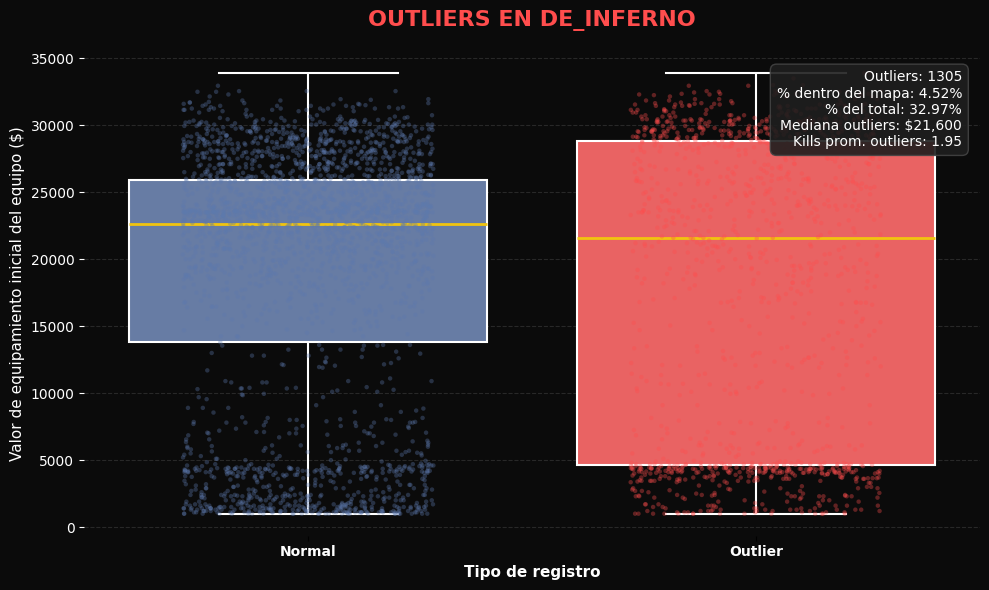

In [12]:
graficar_outliers_mapa('de_inferno')

**Análisis de `de_inferno`**

El mapa `de_inferno` concentra la mayor cantidad absoluta de outliers (**1.305**, equivalente al **32,97%** del total), sin embargo, su tasa interna es la más baja (4,52%), lo que indica que su alta cantidad se explica principalmente por el mayor volumen de datos, los outliers se distribuyen en rangos económicos normales, con una mediana cercana a **$21.600**, lo que sugiere que no corresponden a valores extremos, sino a combinaciones poco frecuentes de variables como equipamiento, desempeño y resultado.

Desde el punto de vista del modelado, estos registros deben ser conservados, ya que representan situaciones reales del juego y aportan variabilidad al modelo.

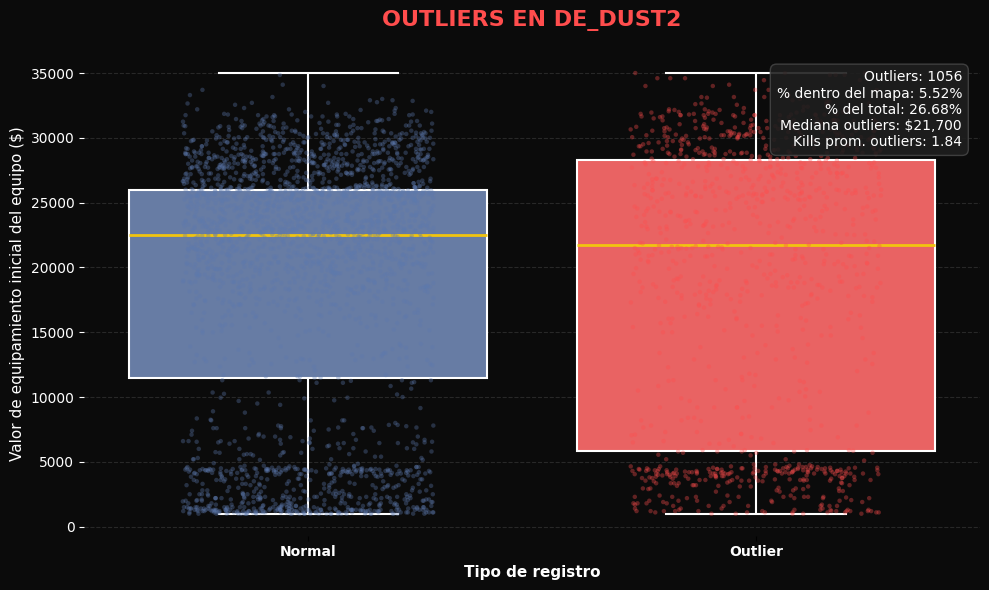

In [13]:
graficar_outliers_mapa('de_dust2')

**Análisis de `de_dust2`**

El mapa `de_dust2` presenta **1.056** outliers (**26,68%**), con la mayor proporción interna (**5,52%**), lo que lo convierte en el mapa con mayor intensidad de comportamiento atípico, los outliers aparecen tanto en rangos bajos como medios de equipamiento, indicando que el resultado de la ronda no siempre sigue la lógica económica esperada.

Esto sugiere que en este mapa existen dinámicas menos predecibles, por lo que el modelo podría tener mayor dificultad para capturar patrones consistentes, siendo recomendable evaluar su desempeño de forma segmentada.

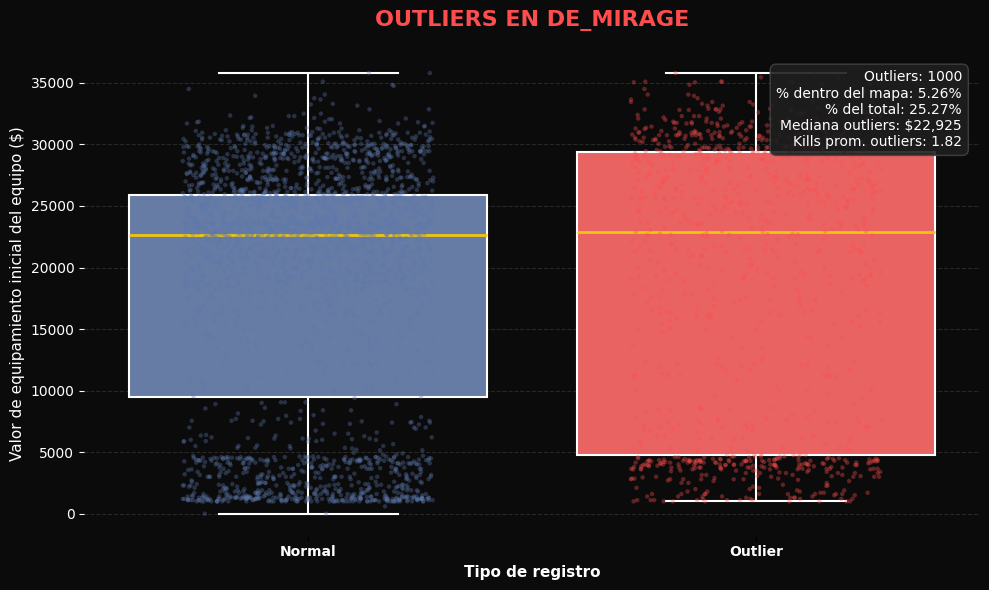

In [14]:
graficar_outliers_mapa('de_mirage')

**Análisis de `de_mirage`**

En `de_mirage` se identifican **1.000** outliers (**25,27%**), con una tasa interna de **5,26%**, la mediana de equipamiento de estos registros (**$22.925**) es relativamente alta, lo que indica que muchas anomalías ocurren en rondas con buena inversión económica.

Esto refuerza la idea de que el resultado no depende únicamente del dinero, por lo que variables de desempeño y estrategia tendrán un peso relevante en el modelo.

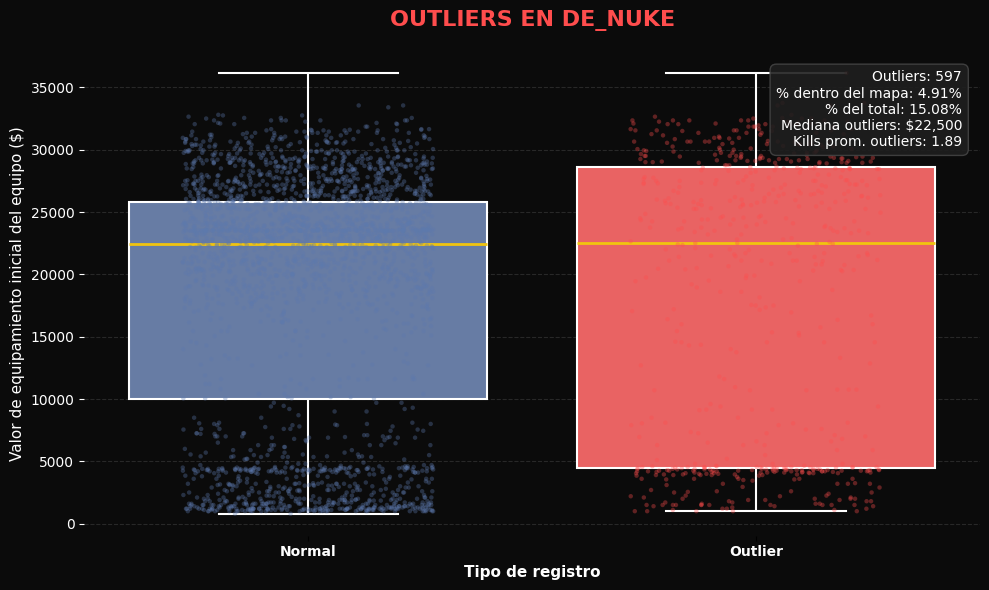

In [15]:
graficar_outliers_mapa('de_nuke')

**Análisis de `de_nuke`**

El mapa `de_nuke` presenta la menor cantidad de 597 outliers la menor cantidad absoluta, equivalente al **15,08%** del total de anomalías, con una tasa interna de **4,91%**, la mediana de equipamiento de los outliers bordea los **$22.500** no muestran desviaciones extremas.

Esto sugiere un comportamiento más estable, lo que podría facilitar el aprendizaje del modelo en este entorno.

**Analisis de outliers**

Desde la perspectiva del modelado, los outliers identificados no corresponden a errores de medición, sino a situaciones reales del juego caracterizadas por combinaciones poco frecuentes de variables, por esta razón, su eliminación no es recomendable, ya que representan información valiosa para el modelo.

Sin embargo, su distribución desigual entre mapas indica que la complejidad del problema varía según el entorno, esta heterogeneidad hace necesario evaluar el desempeño del modelo de manera segmentada por mapa para capturar adecuadamente estas variaciones, además, la presencia de estos valores refuerza la necesidad de aplicar técnicas de escalamiento robusto en la fase de preparación, garantizando que no influyan de manera desproporcionada en el aprendizaje del modelo, de esta forma, se preserva la información valiosa contenida en los outliers mientras se mitigan sus efectos potencialmente distorsionadores en el proceso de entrenamiento.

#### 2.4.2 Valores nulos (NaN)


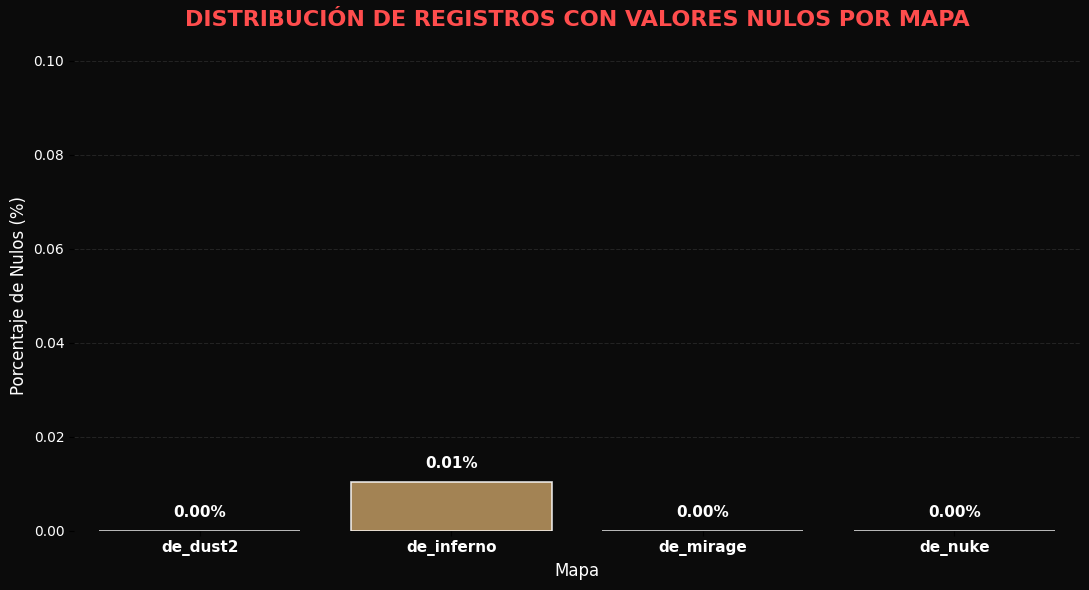

--- RESUMEN NUMÉRICO DE NULOS POR MAPA ---
   ▶ DE_DUST2     : 0.0000% (0 registros)
   ▶ DE_INFERNO   : 0.0104% (3 registros)
   ▶ DE_MIRAGE    : 0.0000% (0 registros)
   ▶ DE_NUKE      : 0.0000% (0 registros)


In [16]:
# Calcular el porcentaje y la cantidad de nulos por mapa
# Primero identificamos si la fila tiene al menos un nulo
df['has_nulls'] = df.isna().any(axis=1)

# Agrupamos por mapa para obtener estadísticas
null_stats = df.groupby('Map')['has_nulls'].agg(['mean', 'sum']).reset_index()
null_stats.columns = ['Map', 'NullPercentage', 'NullCount']
null_stats['NullPercentage'] *= 100

# Configuración de estilo del gráfico (Gamer/Dark)
plt.figure(figsize=(11, 6), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

# Configuración de colores por mapa
map_colors = {
    'de_inferno': '#cf9c52',
    'de_dust2': '#e1b305',
    'de_mirage': '#9a8167',
    'de_nuke': '#4169e1'
}

# Crear el gráfico de barras con los colores específicos
ax = sns.barplot(
    x='Map',
    y='NullPercentage',
    data=null_stats,
    hue='Map',
    palette=map_colors,
    legend=False,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85
)

# Añadir etiquetas de porcentaje sobre las barras con estilo
for p in ax.patches:
    height = p.get_height()
    # Solo mostrar etiqueta si el valor es mayor a 0 para no saturar si todo es 0
    label = f'{height:.2f}%'
    ax.annotate(label,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                color='white')

# Personalización de títulos y ejes
plt.title('DISTRIBUCIÓN DE REGISTROS CON VALORES NULOS POR MAPA', fontsize=16, fontweight='bold', color='#ff4d4d', pad=25)
plt.ylabel('Porcentaje de Nulos (%)', color='white', fontsize=12)
plt.xlabel('Mapa', color='white', fontsize=12)

# Estilo de ticks y límites
plt.xticks(color='white', fontsize=11, fontweight='bold')
plt.yticks(color='white')

# Ajuste de escala automático para ver valores pequeños o 0-1
plt.ylim(0, max(null_stats['NullPercentage'].max() * 2, 0.1))

# Rejilla sutil y limpieza
plt.grid(axis='y', linestyle='--', alpha=0.1, color='white')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Mostrar resumen con formato elegante en consola
print("\033[1;36m--- RESUMEN NUMÉRICO DE NULOS POR MAPA ---\033[0m")
for _, row in null_stats.iterrows():
    print(f"   ▶ {row['Map'].upper():<12} : {row['NullPercentage']:.4f}% ({int(row['NullCount'])} registros)")

# Limpiamos la columna temporal
df.drop(columns=['has_nulls'], inplace=True)

El dataset presenta únicamente 3 valores nulos, lo que representa una proporción insignificante, por lo tanto, no afectan el análisis y pueden ser eliminados sin impacto en los resultados.


#### 2.4.3 Duplicados

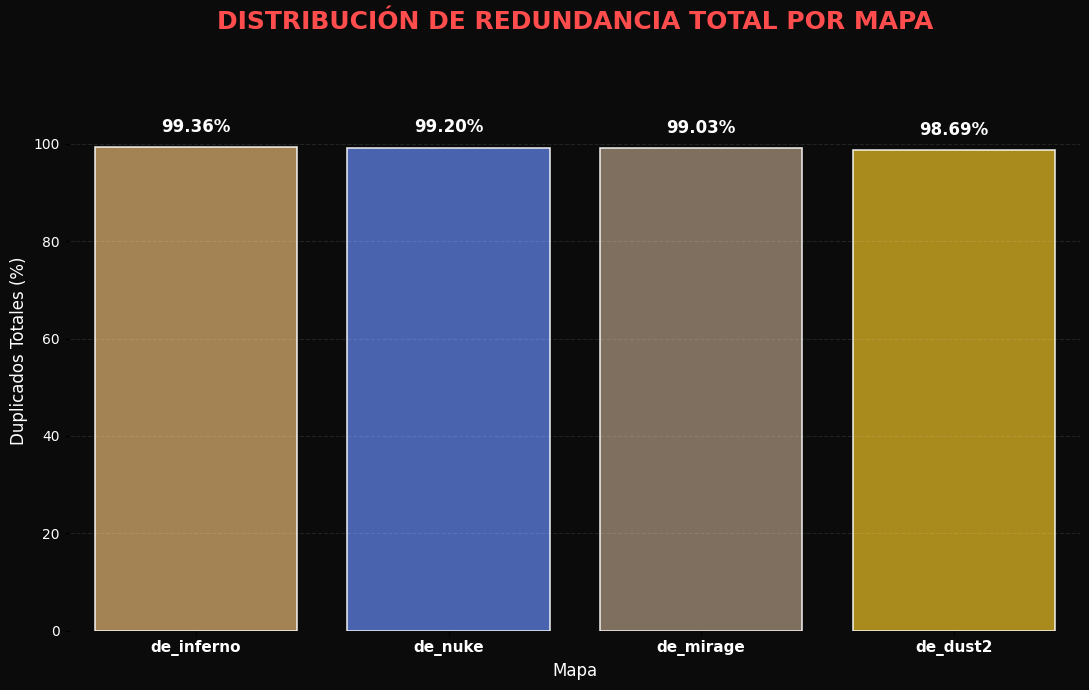

--- RESUMEN DE DUPLICADOS POR MAPA ---
   ▶ DE_INFERNO   : 99.36% (487,633 celdas duplicadas)
   ▶ DE_NUKE      : 99.20% (204,889 celdas duplicadas)
   ▶ DE_MIRAGE    : 99.03% (320,179 celdas duplicadas)
   ▶ DE_DUST2     : 98.69% (320,789 celdas duplicadas)


In [17]:
# 1. Preparación de datos: Calcular el porcentaje global de duplicados por mapa
map_results = []
numeric_vars = df.select_dtypes(include=[np.number]).columns

for mapa in df['Map'].unique():
    df_mapa = df[df['Map'] == mapa]
    total_registros_mapa = len(df_mapa) * len(numeric_vars)

    # Sumamos todos los duplicados de todas las variables en este mapa
    total_dups_mapa = sum(df_mapa[var].duplicated().sum() for var in numeric_vars)

    # Porcentaje global del mapa
    pct_global = (total_dups_mapa / total_registros_mapa) * 100 if total_registros_mapa > 0 else 0

    map_results.append({
        'Mapa': mapa,
        'Porcentaje_Total_Duplicados': pct_global,
        'Total_Duplicados': total_dups_mapa
    })

df_map_pct = pd.DataFrame(map_results)

# 2. Configuración visual mejorada (Estética Gamer/Dark)
plt.figure(figsize=(11, 7), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

map_colors = {
    'de_inferno': '#cf9c52',
    'de_dust2': '#e1b305',
    'de_mirage': '#9a8167',
    'de_nuke': '#4169e1'
}

# Crear el gráfico de barras
ax = sns.barplot(
    data=df_map_pct,
    x='Mapa',
    y='Porcentaje_Total_Duplicados',
    palette=map_colors,
    hue='Mapa',
    legend=False,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85
)

# Añadir etiquetas de valor sobre las barras con estilo
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='white',
                xytext=(0, 8), textcoords='offset points')

# Personalización de títulos y ejes
plt.title('DISTRIBUCIÓN DE REDUNDANCIA TOTAL POR MAPA', fontsize=18, fontweight='bold', color='#ff4d4d', pad=30)
plt.ylabel('Duplicados Totales (%)', color='white', fontsize=12)
plt.xlabel('Mapa', color='white', fontsize=12)

# Estilo de ticks y límites
plt.xticks(color='white', fontsize=11, fontweight='bold')
plt.yticks(color='white')
plt.ylim(0, 115)

# Rejilla sutil y limpieza
plt.grid(axis='y', linestyle='--', alpha=0.1, color='white')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Resumen numérico con formato elegante
print("\033[1;33m--- RESUMEN DE DUPLICADOS POR MAPA ---\033[0m")
for _, row in df_map_pct.iterrows():
    print(f"   ▶ {row['Mapa'].upper():<12} : {row['Porcentaje_Total_Duplicados']:.2f}% ({int(row['Total_Duplicados']):,} celdas duplicadas)")

El análisis de duplicidad por mapa revela porcentajes superiores al ***98***% en todos los casos, sin embargo, estos valores corresponden a celdas individuales con datos repetidos, no a registros completos duplicados, este patrón es completamente esperado dado que muchas variables del dataset tienen un rango limitado de valores posibles, en consecuencia, no se trata de un problema de calidad de datos y no requiere intervención adicional.


### 2.5 Gráficos


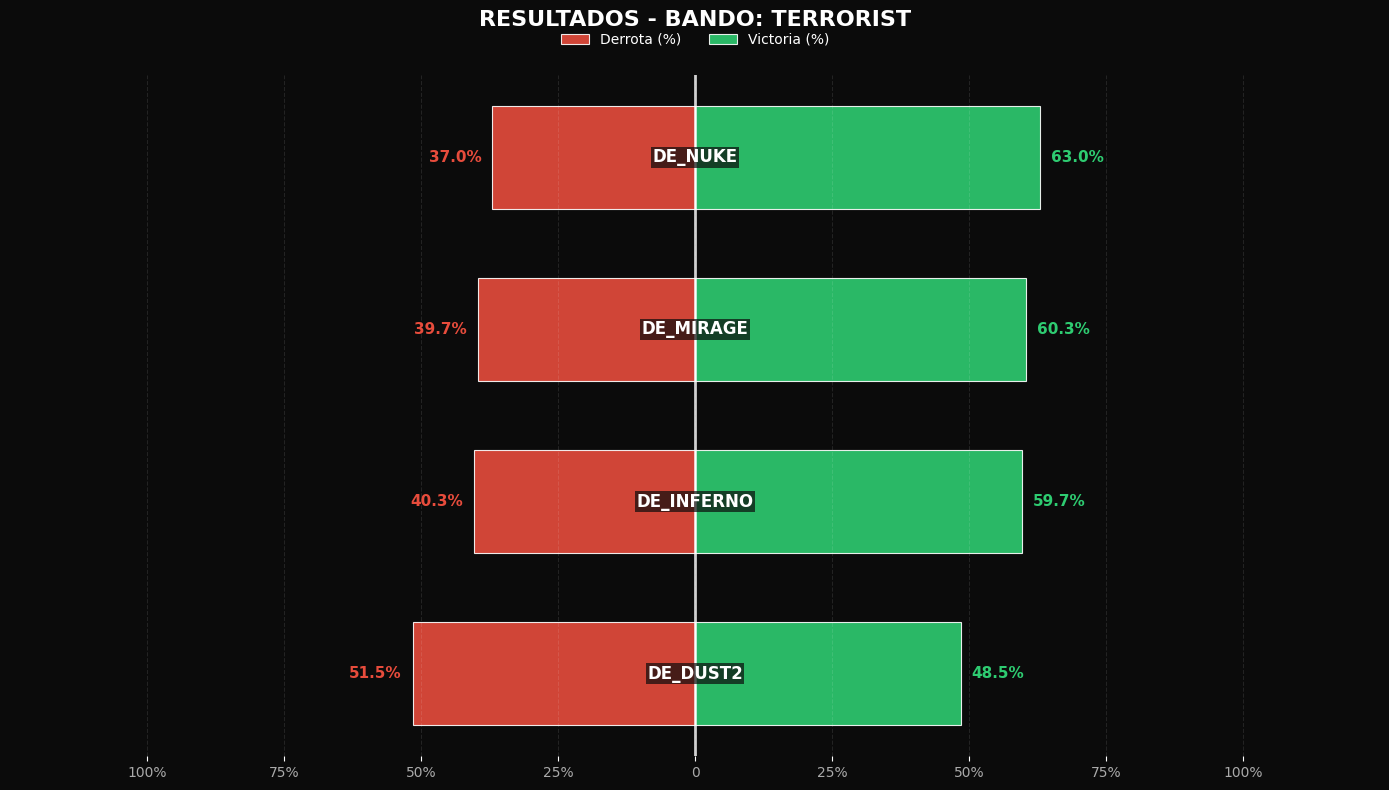

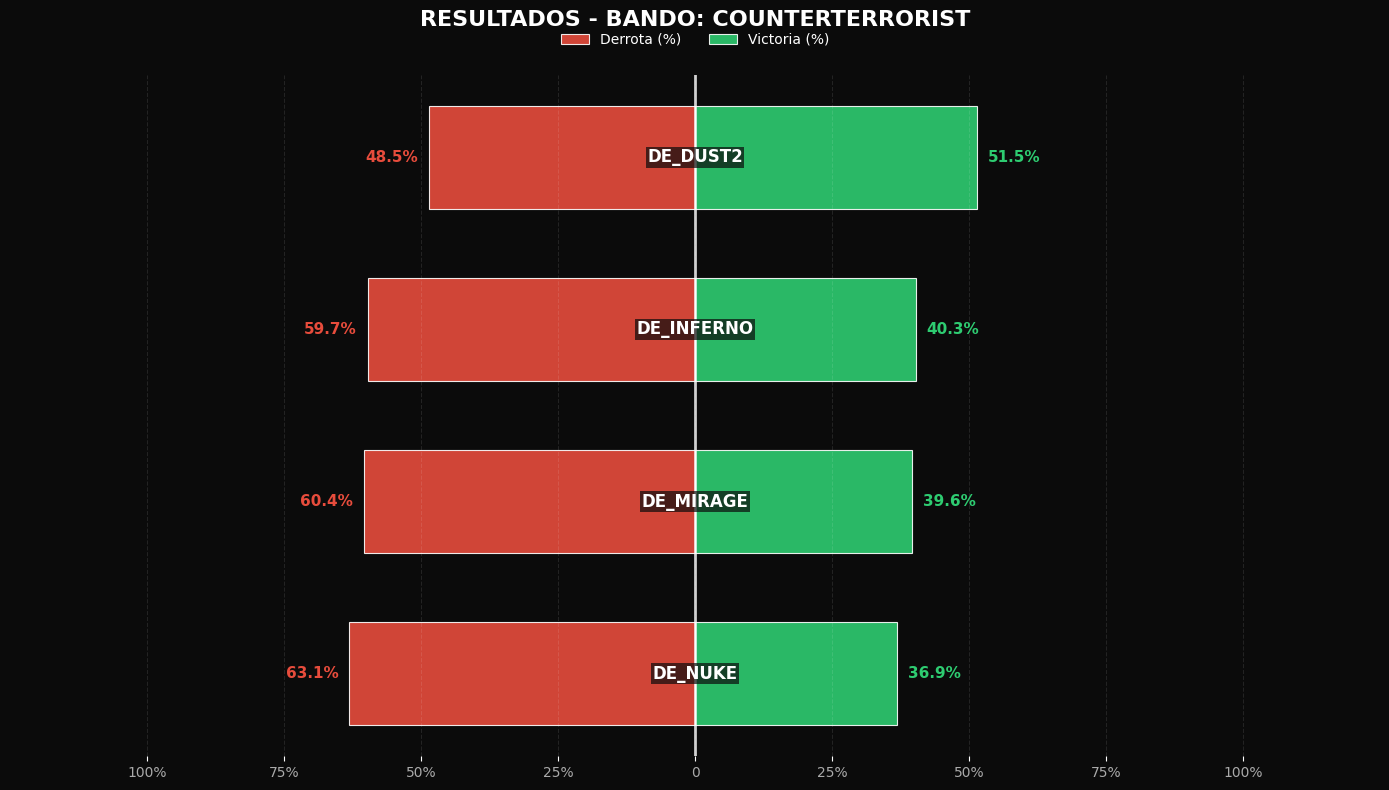

In [18]:
# 1. Preparación de datos: Calcular porcentajes por Mapa y Bando
df['RoundWinner_Bool'] = df['RoundWinner'].astype(str).str.lower().str.strip().map({
    'true': True,
    'false': False,
    'false4': False
})

# Agrupación por Mapa y Bando
stats_map_team = df.groupby(['Map', 'Team'])['RoundWinner_Bool'].value_counts(normalize=True).unstack() * 100
stats_map_team.columns = ['Loss %', 'Win %']
stats_map_team = stats_map_team.reset_index()

# 2. Configuración de la visualización (Gráficos separados)
plt.style.use('dark_background')
teams = ['Terrorist', 'CounterTerrorist']
color_win = '#2ecc71'
color_loss = '#e74c3c'

for team in teams:
    fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')

    # Filtrar datos por bando y ordenar para consistencia visual
    subset = stats_map_team[stats_map_team['Team'] == team].sort_values('Win %', ascending=True)

    # Barras espejo
    ax.barh(subset['Map'], -subset['Loss %'], color=color_loss, label='Derrota (%)', height=0.6, alpha=0.9, edgecolor='white', linewidth=0.8)
    ax.barh(subset['Map'], subset['Win %'], color=color_win, label='Victoria (%)', height=0.6, alpha=0.9, edgecolor='white', linewidth=0.8)

    # Etiquetas de porcentaje y nombre del mapa
    for idx, row in enumerate(subset.itertuples()):
        ax.text(-row._3 - 2, idx, f"{row._3:.1f}%", va='center', ha='right', color=color_loss, fontweight='bold', fontsize=11)
        ax.text(row._4 + 2, idx, f"{row._4:.1f}%", va='center', ha='left', color=color_win, fontweight='bold', fontsize=11)
        ax.text(0, idx, row.Map.upper(), va='center', ha='center', color='white',
                fontweight='black', fontsize=12, bbox=dict(facecolor='#0b0b0b', alpha=0.7, edgecolor='none', pad=1))

    ax.axvline(0, color='white', linewidth=2, alpha=0.8)
    ax.set_xlim(-125, 125)
    ax.set_xticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(['100%', '75%', '50%', '25%', '0', '25%', '50%', '75%', '100%'], color='#aaaaaa')
    ax.set_yticks([])
    ax.set_title(f'RESULTADOS - BANDO: {team.upper()}', color='white', size=16, fontweight='bold', pad=35)

    # Ajuste de posición de leyenda para evitar solapamiento
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False, labelcolor='white', fontsize=10)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.1, color='white')

    plt.tight_layout()
    plt.show()

**Análisis de distribución competitiva por mapa y bando**

El análisis de la distribución de victorias y derrotas por mapa y bando revela patrones estructurales que influyen directamente en el resultado de la ronda, la interpretación debe realizarse considerando la interacción entre ambas variables, ya que la ventaja competitiva no se distribuye de manera homogénea según el entorno.

- Mapa `DE_NUKE`: El bando **Terrorist** presenta una tasa de victoria superior a **CounterTerrorist**, sugiriendo una inclinación del mapa hacia el ataque, este comportamiento indica que, bajo ciertas condiciones, las estrategias ofensivas tienen mayor probabilidad de éxito, lo que convierte al bando en una variable explicativa relevante dentro del modelo.

- Mapa `DE_MIRAGE`: Se observa una ventaja consistente para **Terrorist**, posiblemente asociada a la estructura del mapa, que favorece duelos iniciales y control temprano del espacio, este patrón refuerza la importancia de considerar la interacción entre mapa y bando, en lugar de analizarlos de forma independiente.

- Mapa `DE_INFERNO`: Nuevamente se identifica una ventaja para **Terrorist**, sin embargo, este resultado debe interpretarse con cautela, dado que `de_inferno` concentra una alta proporción de los datos y de outliers, lo que podría amplificar patrones específicos y afectar la representatividad del análisis.

- Mapa `DE_DUST2`: Presenta un comportamiento más equilibrado, con una ligera ventaja para **CounterTerrorist**, esto sugiere que este mapa ofrece condiciones más simétricas, lo que podría facilitar el aprendizaje del modelo al reducir sesgos estructurales.

En conjunto, el análisis evidencia que tanto el mapa como el bando influyen significativamente en la probabilidad de victoria, incluso bajo condiciones económicas similares, esto implica que ambas variables deben ser incorporadas en el modelo, idealmente considerando su interacción mediante variables combinadas o encoding adecuado que capture estas dinámicas, además, la existencia de mapas con comportamientos más equilibrados y otros más sesgados sugiere la necesidad de evaluar el desempeño del modelo de forma segmentada, esta evaluación permitirá verificar su capacidad de generalización en distintos escenarios y detectar posibles limitaciones en mapas con mayor desequilibrio competitivo.

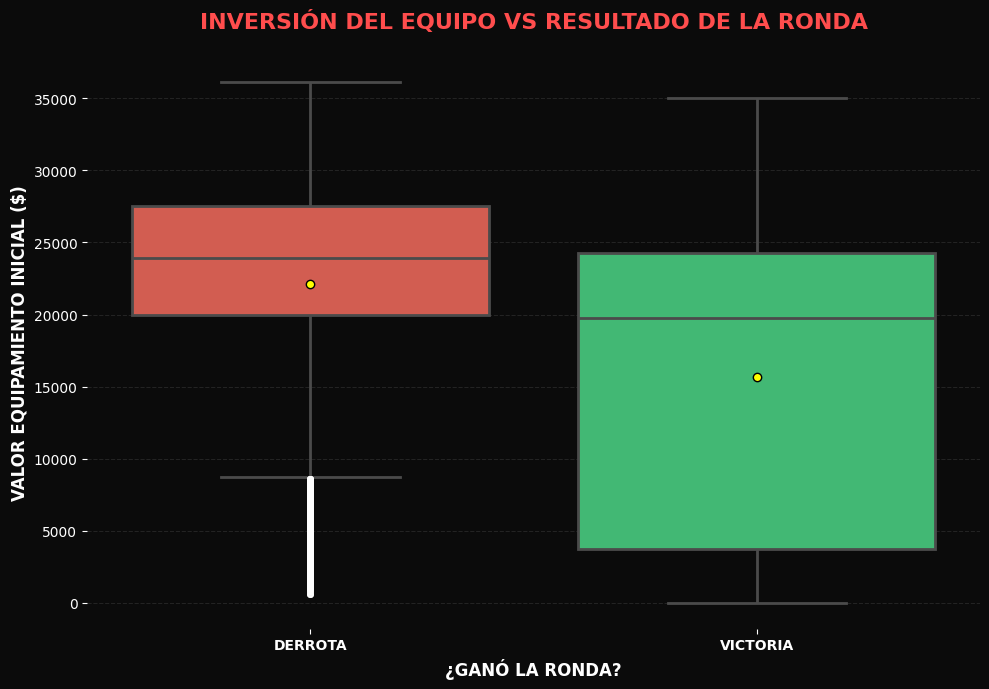

In [19]:
# Asegurar limpieza y formato de RoundWinner
df['RoundWinner'] = df['RoundWinner'].astype(str).replace({'False4': 'False', 'True': 'True', 'False': 'False'})

# Definir orden y colores
order = ['False', 'True']
colors_palette = {'False': '#e74c3c', 'True': '#2ecc71'}

# Estilo dark
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 7), facecolor='#0b0b0b')
ax.set_facecolor('#0b0b0b')

# Generar Boxplot
sns.boxplot(
    x='RoundWinner',
    y='TeamStartingEquipmentValue',
    hue='RoundWinner',
    data=df,
    order=order,
    palette=colors_palette,
    linewidth=2,
    showfliers=True,
    fliersize=4,
    legend=False,
    flierprops={
        'markerfacecolor': 'white',
        'markeredgecolor': 'white',
        'alpha': 0.5
    },
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "yellow",
        "markeredgecolor": "black",
        "markersize": 6
    }
)

# Personalización de etiquetas y títulos
plt.title('INVERSIÓN DEL EQUIPO VS RESULTADO DE LA RONDA', fontsize=16, fontweight='bold', color='#ff4d4d', pad=20)
plt.xlabel('¿GANÓ LA RONDA?', fontsize=12, color='white', fontweight='bold')
plt.ylabel('VALOR EQUIPAMIENTO INICIAL ($)', fontsize=12, color='white', fontweight='bold')
plt.xticks([0, 1], ['DERROTA', 'VICTORIA'], color='white', fontweight='bold')
plt.yticks(color='white')

# Grid y bordes
ax.grid(axis='y', linestyle='--', alpha=0.1, color='white')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Análisis del gráfico inversión vs. resultado**

Al examinar la relación entre el valor del equipamiento inicial y el resultado de las rondas, emergen patrones relevantes tanto desde el punto de vista estratégico como del modelado predictivo.

* **Distribución de medias:** La media del equipamiento en rondas ganadas es inferior a la de rondas perdidas, evidenciando que una mayor inversión no garantiza el éxito, este hallazgo sugiere que la eficiencia en el uso de recursos es más determinante que el gasto absoluto, por lo que variables económicas deben analizarse en conjunto con métricas de desempeño y contexto.

* **Rondas de compra completa (Full buy):** Se observa una alta concentración de derrotas en niveles elevados de inversión ($25.000+), lo que indica que incluso con equipamiento óptimo, el resultado depende de factores adicionales como posicionamiento, coordinación y ejecución, desde la perspectiva del modelo, esto refuerza que el equipamiento por sí solo es insuficiente para explicar la variable objetivo.

* **Eficacia de las rondas Eco/semi-Eco:** La baja mediana en rondas ganadas confirma que es posible obtener victorias con inversión limitada, esto introduce variabilidad en la relación entre economía y resultado, lo que puede dificultar la capacidad del modelo para capturar patrones lineales, sugiriendo la necesidad de considerar interacciones entre variables.

* **No linealidad en la relación inversión-resultado** El comportamiento observado indica la existencia de un punto de saturación, donde aumentos en la inversión no se traducen en mayores probabilidades de victoria, este patrón sugiere una relación no lineal, lo que implica que modelos lineales simples podrían no capturar completamente la dinámica del problema.

* **Gestión del riesgo:** La presencia de victorias con baja inversión demuestra que existen escenarios de alta incertidumbre donde el resultado no sigue la tendencia general, estos casos deben ser preservados, ya que aportan información relevante sobre situaciones reales del juego y contribuyen a la capacidad del modelo para generalizar.

En conclusión, el análisis evidencia que la relación entre inversión y resultado es compleja y no lineal, estando influenciada por múltiples factores adicionales, esto implica que las variables económicas deben ser utilizadas en combinación con otras métricas, y que el modelo deberá ser capaz de capturar interacciones y comportamientos no lineales para lograr una predicción precisa.


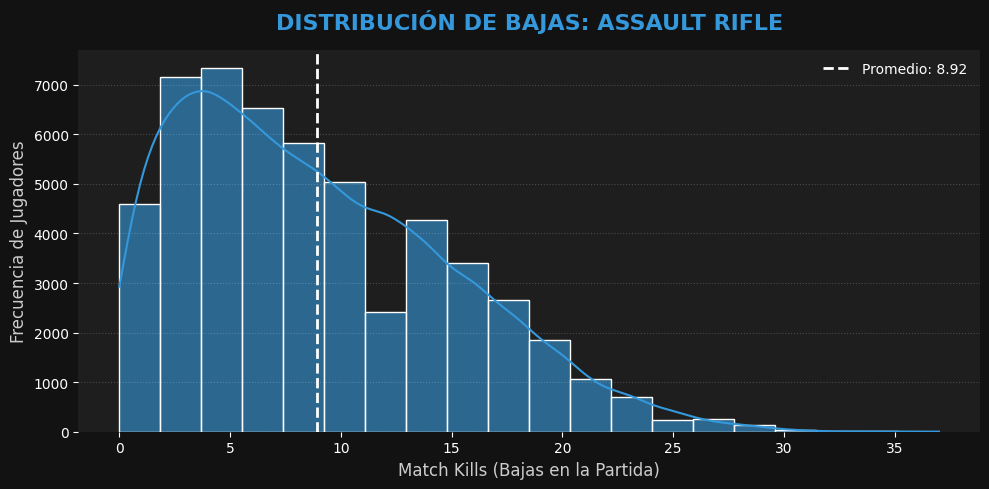

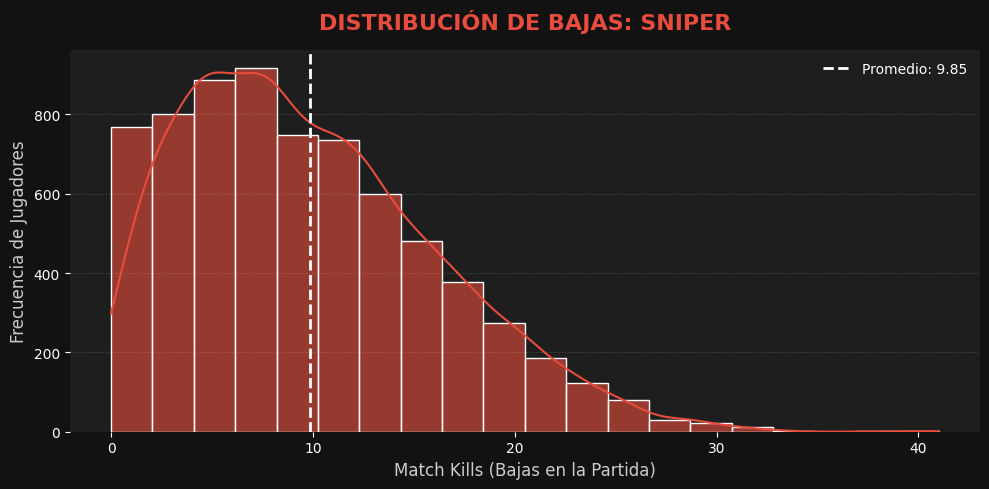

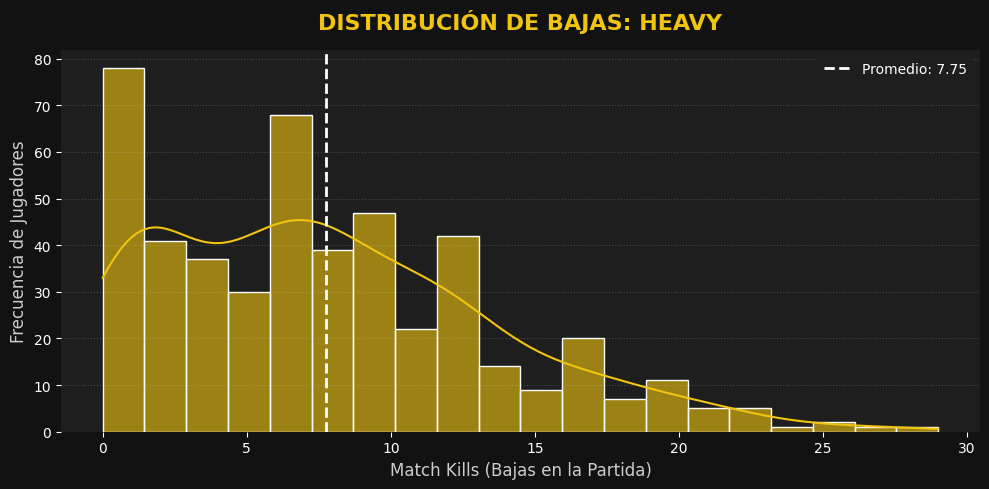

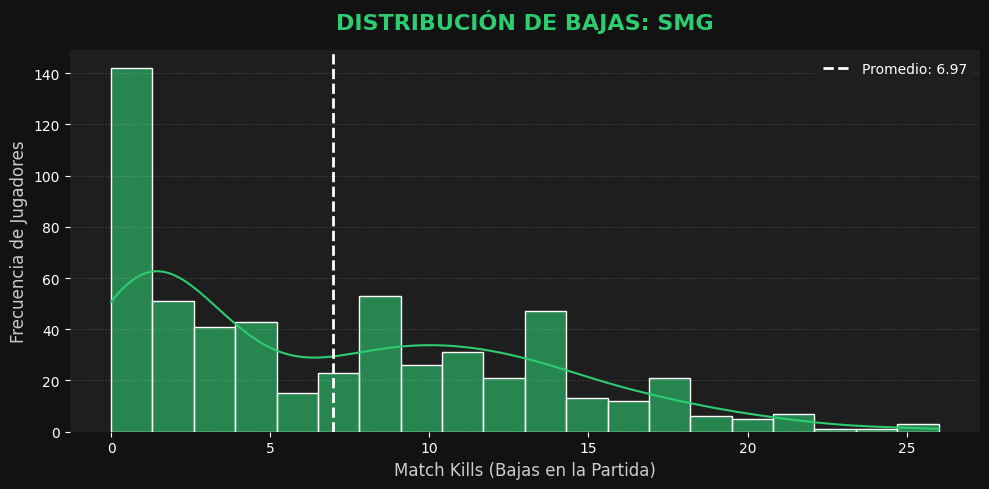

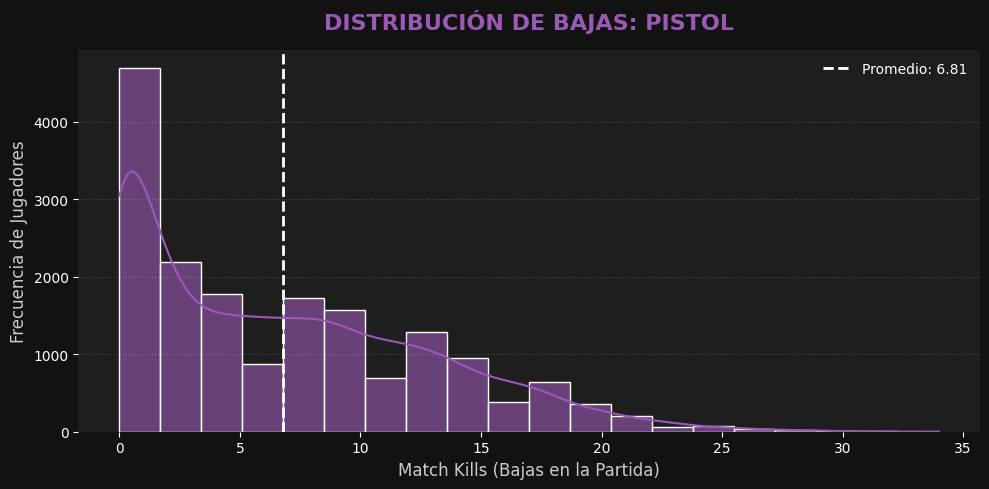

In [20]:
# Definir las categorías de armas y colores personalizados
weapon_cols = ['PrimaryAssaultRifle', 'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol']
weapon_labels = ['Assault Rifle', 'Sniper', 'Heavy', 'SMG', 'Pistol']
colors = ['#3498db', '#e74c3c', '#f1c40f', '#2ecc71', '#9b59b6']

# Configuración de estilo estético
plt.style.use('dark_background')

for i, col in enumerate(weapon_cols):
    # Crear una figura independiente para cada arma
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='#121212')
    ax.set_facecolor('#1e1e1e')

    # Filtrar datos: Jugadores que usaron predominantemente esta arma
    data_subset = df[df[col] > 0.5]['MatchKills']
    mean_val = data_subset.mean()

    # Crear el histograma con diseño mejorado
    sns.histplot(data_subset, bins=20, kde=True, ax=ax, color=colors[i], alpha=0.6, edgecolor='white', linewidth=1)

    # Línea de promedio
    ax.axvline(mean_val, color='white', linestyle='--', linewidth=2, label=f'Promedio: {mean_val:.2f}')

    # Personalización del gráfico
    ax.set_title(f'DISTRIBUCIÓN DE BAJAS: {weapon_labels[i].upper()}', fontsize=16, fontweight='bold', color=colors[i], pad=15)
    ax.set_xlabel('Match Kills (Bajas en la Partida)', fontsize=12, color='#cccccc')
    ax.set_ylabel('Frecuencia de Jugadores', fontsize=12, color='#cccccc')
    ax.legend(facecolor='#1e1e1e', edgecolor='none')

    # Eliminar bordes innecesarios
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.2)

    plt.tight_layout()
    plt.show()

**Análisis gráfico de distribución de bajas por Arma**

El análisis de la distribución de bajas según el tipo de arma permite identificar patrones relevantes en el desempeño y su posible impacto en el modelado predictivo.

* **Rifles de asalto:** Presentan la mayor frecuencia de uso y una distribución relativamente estable de bajas, lo que indica un desempeño consistente en distintas rondas, esto sugiere que son una variable representativa del estado estándar del juego, especialmente en rondas de inversión completa, desde la perspectiva del modelo, su alta frecuencia puede aportar estabilidad, aunque su baja variabilidad podría limitar su capacidad discriminativa individual.

* **Snipers:** Muestran una mayor dispersión en la cantidad de bajas, reflejando una alta variabilidad en el rendimiento, esto indica que su impacto depende de condiciones específicas, como el contexto de la ronda o el desempeño individual, para el modelado, esta variabilidad puede aportar poder explicativo, pero también introducir ruido si no se combina adecuadamente con otras variables relevantes.

* **Pistolas y SMGs:** Sus distribuciones se concentran en valores bajos, coherente con su uso en rondas eco o semi-eco, estas variables, más que reflejar capacidad ofensiva, actúan como indicadores del estado económico del equipo, por lo tanto, su valor predictivo está más asociado al contexto de la ronda que al desempeño directo.

* **Heavy (armas pesadas):** Presentan una baja frecuencia de uso y distribuciones limitadas, lo que indica que aparecen en situaciones específicas, debido a su baja representatividad, es probable que tengan un impacto reducido en el modelo y podrían ser evaluadas para simplificación o agrupación.

 En resumen, el tipo de arma principal refleja tanto el estado económico como el potencial ofensivo del equipo, pero su capacidad predictiva no es uniforme, mientras algunas categorías aportan estabilidad (rifles), otras introducen variabilidad (snipers) o contexto (pistolas y SMG), por esta razón, será necesario evaluar su relevancia dentro del modelo, considerando posibles transformaciones como agrupación de categorías o combinación con variables económicas para capturar mejor su impacto en el resultado.

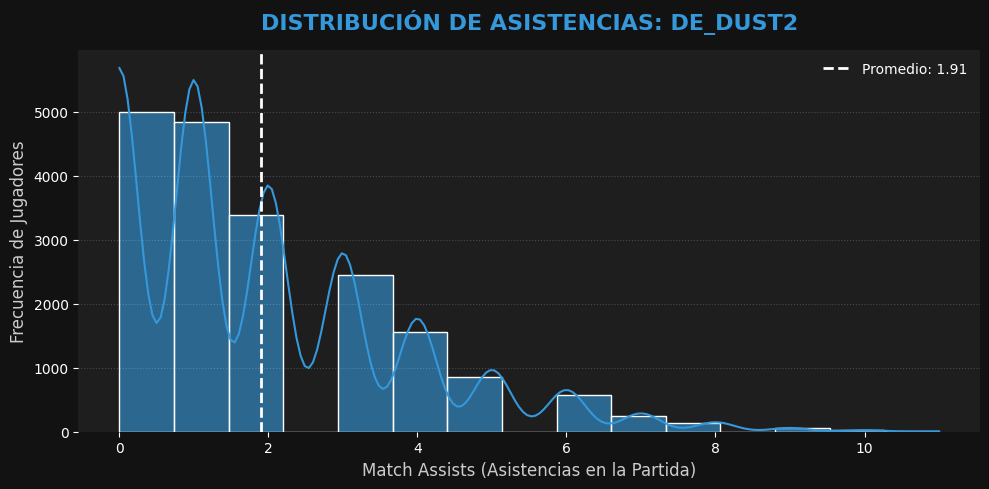

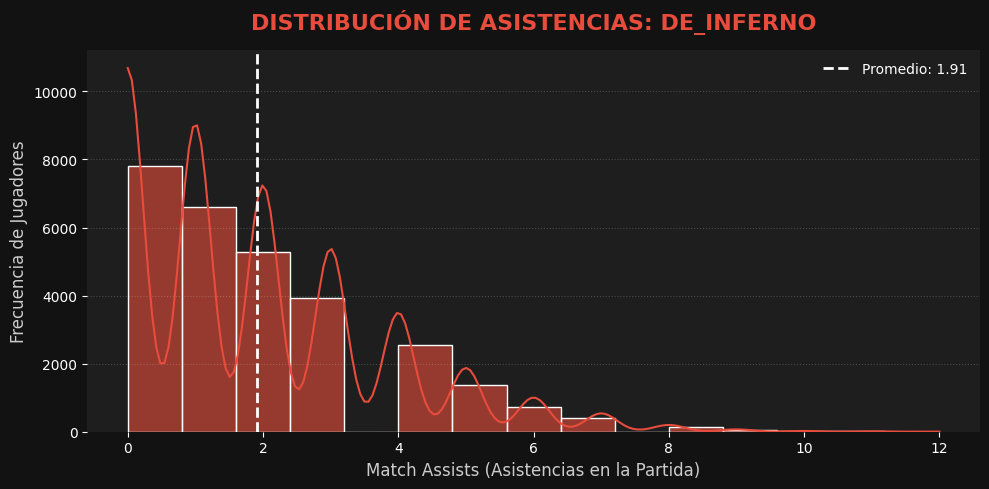

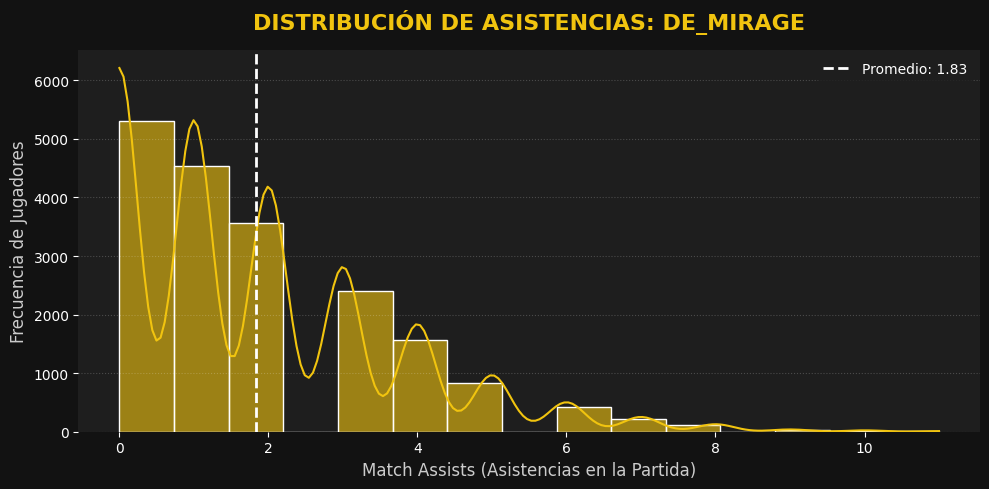

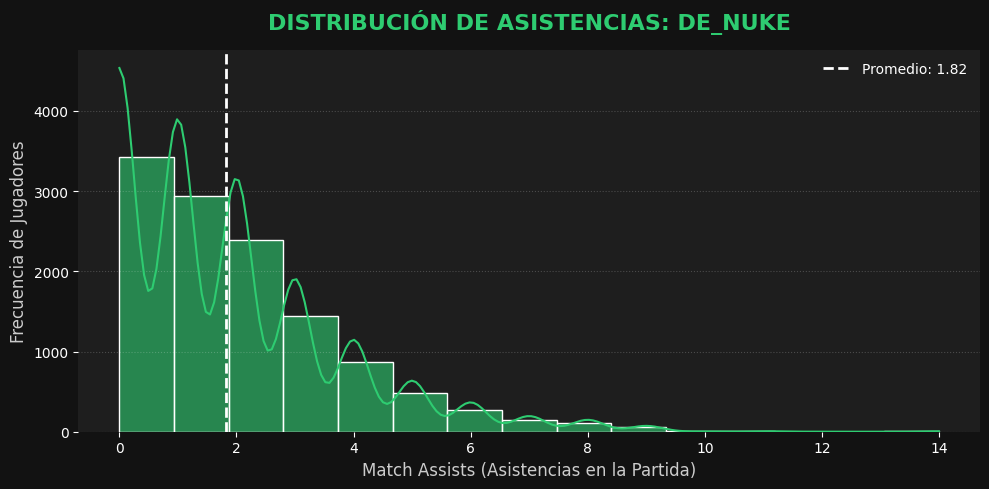

In [21]:
# Mapas y sus colores temáticos
maps = sorted(df['Map'].unique())
map_colors_list = ['#3498db', '#e74c3c', '#f1c40f', '#2ecc71']

# Configuración de estilo estético
plt.style.use('dark_background')

for i, map_name in enumerate(maps):
    # Crear una figura independiente para cada mapa con el estilo solicitado
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='#121212')
    ax.set_facecolor('#1e1e1e')

    # Filtrar datos por mapa
    data_subset = df[df['Map'] == map_name]['MatchAssists']
    mean_val = data_subset.mean()

    # Crear el histograma con diseño mejorado
    sns.histplot(data_subset, bins=15, kde=True, ax=ax, color=map_colors_list[i % len(map_colors_list)], alpha=0.6, edgecolor='white', linewidth=1)

    # Línea de promedio
    ax.axvline(mean_val, color='white', linestyle='--', linewidth=2, label=f'Promedio: {mean_val:.2f}')

    # Personalización del gráfico
    ax.set_title(f'DISTRIBUCIÓN DE ASISTENCIAS: {map_name.upper()}', fontsize=16, fontweight='bold', color=map_colors_list[i % len(map_colors_list)], pad=15)
    ax.set_xlabel('Match Assists (Asistencias en la Partida)', fontsize=12, color='#cccccc')
    ax.set_ylabel('Frecuencia de Jugadores', fontsize=12, color='#cccccc')
    ax.legend(facecolor='#1e1e1e', edgecolor='none')

    # Eliminar bordes innecesarios
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.2)

    plt.tight_layout()
    plt.show()

**Análisis gráfico de Distribución de Asistencias por Mapa**

El análisis de la distribución de asistencias acumuladas por partida `MatchAssists` permite evaluar el rol del soporte en el desempeño del jugador y su posible impacto en el modelado.

* **El grueso se agrupa abajo**: En todos los mapas, la mayor parte de los jugadores se concentra en un rango de 0 a 5 asistencias, lo que indica que las asistencias son eventos menos frecuentes en comparación con las eliminaciones directas, esto sugiere que, de forma individual, esta variable podría tener menor poder predictivo en comparación con métricas como kills.

* **El promedio es estable**: El promedio de asistencias se mantiene cercano a 2 en todos los mapas, evidenciando un comportamiento consistente independiente del entorno, esta baja variabilidad indica que la variable tiene limitada capacidad para diferenciar escenarios, lo que podría reducir su relevancia como predictor principal.

* **Los outliers**: Se observan casos con más de 10 asistencias por partida, asociados a jugadores con alta participación en soporte o a partidas más extensas, estos valores, aunque poco frecuentes, reflejan situaciones reales y deben ser conservados, ya que pueden aportar información sobre dinámicas de juego específicas.

* **Variaciones según mapa:** Se identifican diferencias leves en la dispersión de asistencias entre mapas, `De_inferno` presenta distribuciones más concentradas, mientras que `de_dust2` muestra mayor dispersión, posiblemente asociada a interacciones a mayor distancia o uso de utilidad, sin embargo, estas diferencias no son lo suficientemente marcadas como para generar una segmentación clara por mapa.

En conclusión, `MatchAssists` actúa como un indicador complementario del desempeño, reflejando el nivel de soporte dentro del equipo, no obstante, su baja variabilidad y concentración en valores bajos sugieren que su capacidad predictiva individual es limitada, por ello, su mayor valor se obtiene al combinarla con otras métricas de desempeño, como kills o daño, permitiendo capturar de mejor forma la contribución total del jugador en el resultado de la ronda.

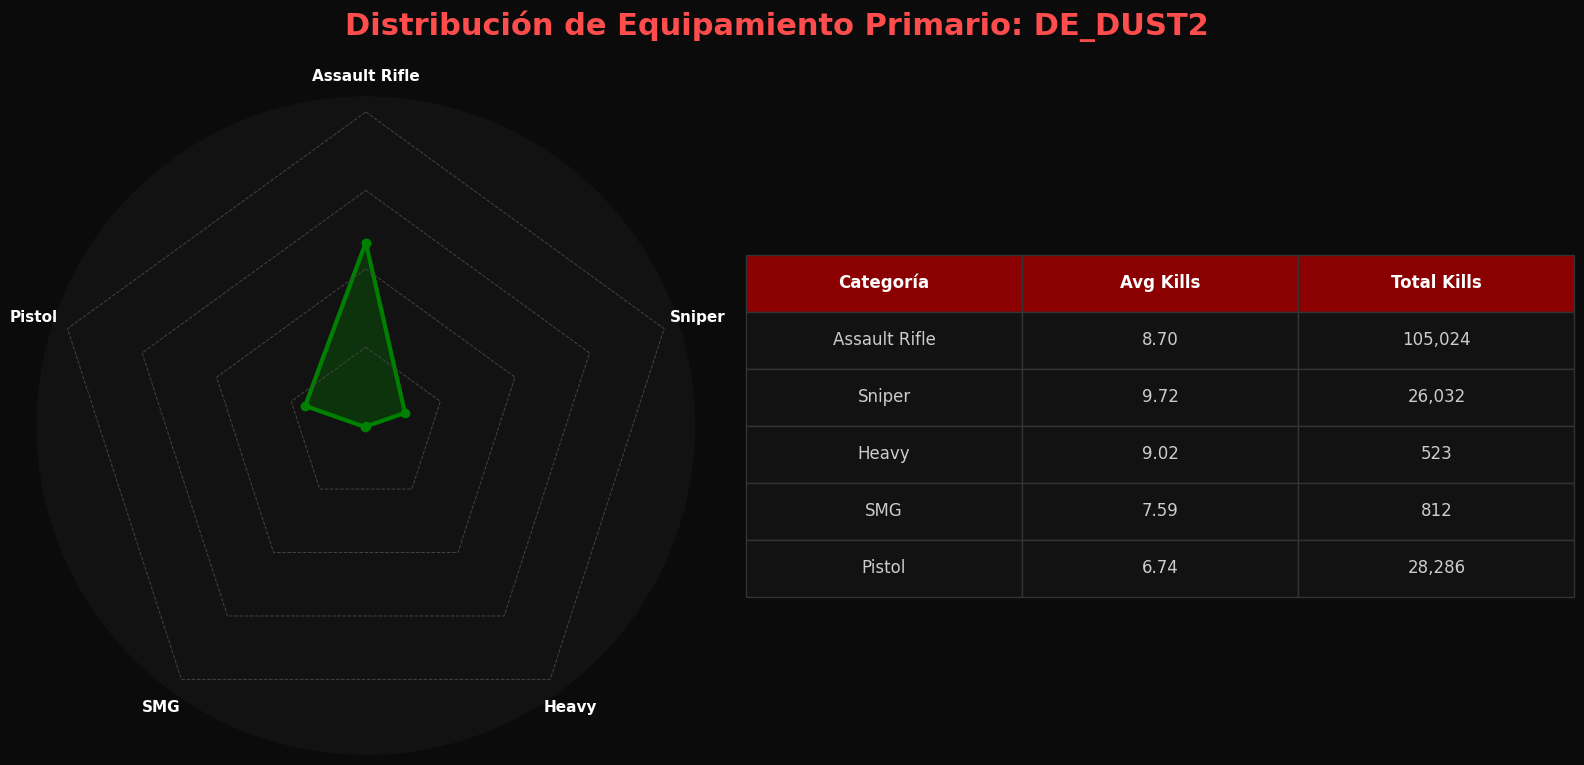

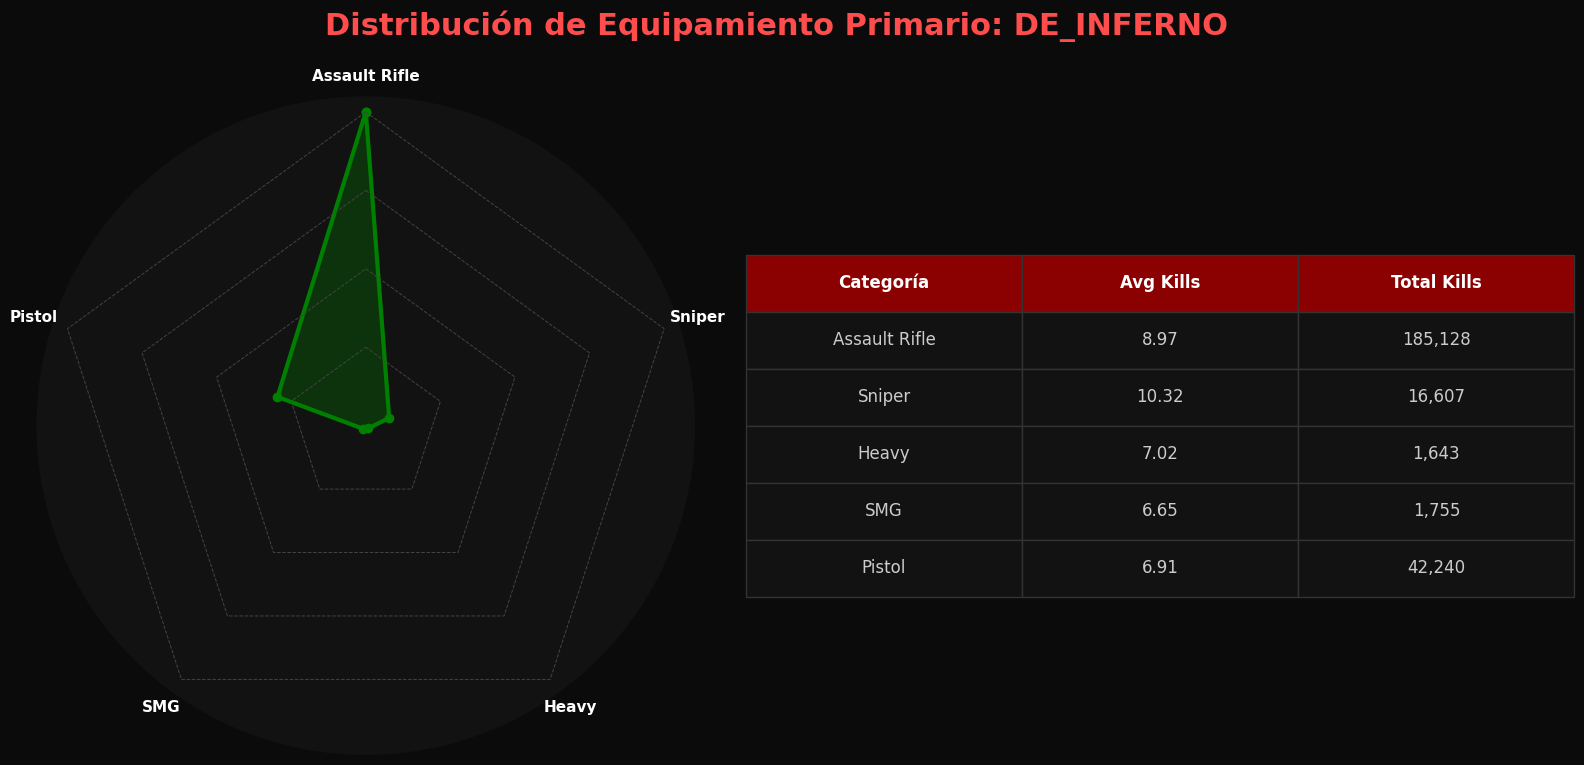

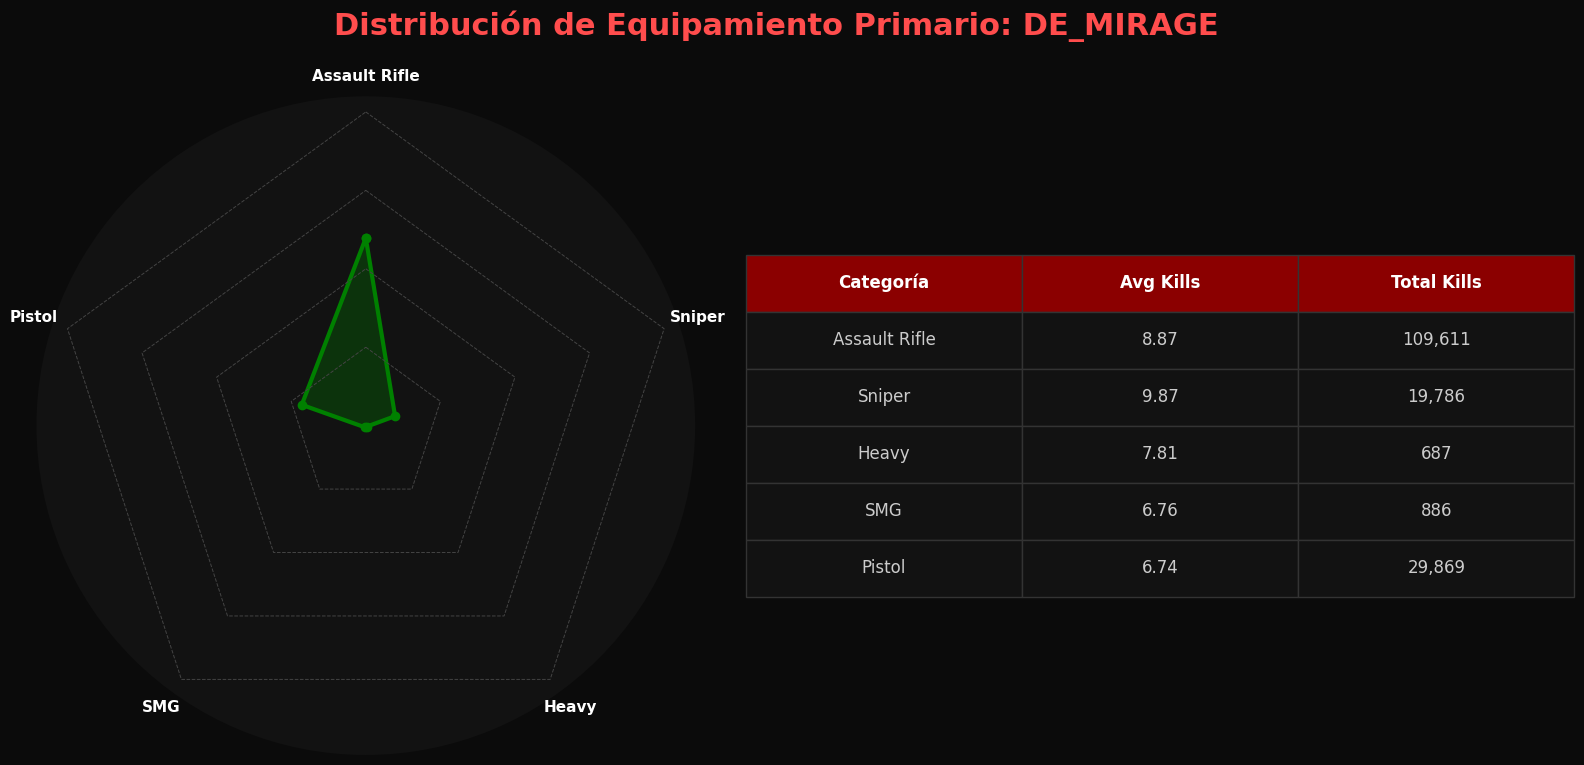

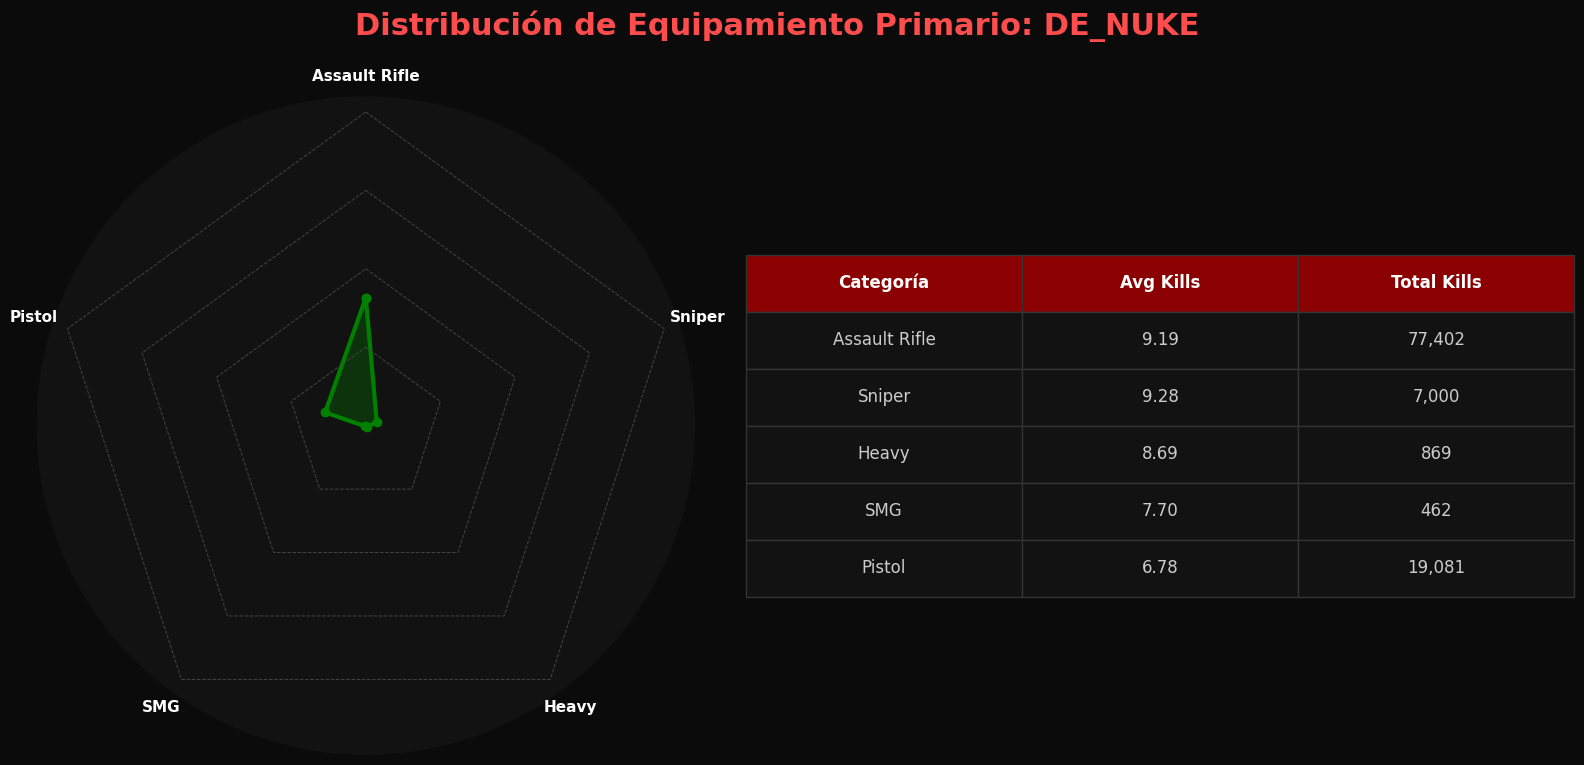

In [22]:
# Configuración de estilo oscuro
plt.style.use('dark_background')

# 1. Configuración de datos
weapon_cols = ['PrimaryAssaultRifle', 'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol']
weapon_labels = ['Assault Rifle', 'Sniper', 'Heavy', 'SMG', 'Pistol']

# MODIFICACIÓN: Ahora calculamos la SUMA (total acumulado) por mapa para el radar
map_weapon_usage_sum = df.groupby('Map')[weapon_cols].sum()

# 2. Estadísticas de desempeño (Kills) - Se mantienen igual para la tabla
map_weapon_stats = {}
for map_name in df['Map'].unique():
    stats_list = []
    for col in weapon_cols:
        mask = (df['Map'] == map_name) & (df[col] > 0.5)
        subset = df[mask]
        avg_k = subset['MatchKills'].mean() if not subset.empty else 0
        sum_k = subset['MatchKills'].sum() if not subset.empty else 0
        stats_list.append({'avg': round(avg_k, 2), 'sum': int(sum_k)})
    map_weapon_stats[map_name] = stats_list

# 3. Generar gráficos con forma de telaraña (poligonal)
maps = sorted(df['Map'].unique())
num_vars = len(weapon_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

for map_name in maps:
    fig = plt.figure(figsize=(16, 8), facecolor='#0b0b0b')
    ax_radar = fig.add_subplot(121, polar=True, facecolor='#121212')
    ax_table = fig.add_subplot(122, facecolor='#0b0b0b')

    # Datos de SUMA del arma para el radar
    values = map_weapon_usage_sum.loc[map_name].values.flatten().tolist()
    values += values[:1]

    ax_radar.fill(angles, values, color='green', alpha=0.3)
    ax_radar.plot(angles, values, color='green', linewidth=3, marker='o')

    ax_radar.set_theta_offset(np.pi / 2)
    ax_radar.set_theta_direction(-1)
    ax_radar.set_rlabel_position(0)

    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(weapon_labels, size=11, fontweight='bold', color='white')

    # Ajuste dinámico del grid basado en el máximo valor de la suma
    max_val = map_weapon_usage_sum.max().max()
    grid_values = np.linspace(0, max_val, 5)
    for g in grid_values:
        ax_radar.plot(angles, [g]*len(angles), color='#444444', linestyle='--', linewidth=0.7)

    ax_radar.grid(False)
    ax_radar.set_yticklabels([])
    ax_radar.spines['polar'].set_visible(False)

    # --- Tabla de Desempeño (Kills) ---
    ax_table.axis('off')
    weapon_perf = map_weapon_stats[map_name]
    table_data = [[label, f"{s['avg']:.2f}", f"{s['sum']:,}"] for label, s in zip(weapon_labels, weapon_perf)]

    the_table = ax_table.table(cellText=table_data, colLabels=['Categoría', 'Avg Kills', 'Total Kills'], loc='center', cellLoc='center')
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(12)
    the_table.scale(1.2, 3.2)

    for (row, col), cell in the_table.get_celld().items():
        cell.set_edgecolor('#333333')
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#8b0000')
        else:
            cell.set_facecolor('#121212')
            cell.set_text_props(color='#cccccc')

    plt.suptitle(f'Distribución de Equipamiento Primario: {map_name.upper()}', size=22, color='#ff4d4d', fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

**Análisis del gráfico Uso de Armamento y Efectividad Táctica**

Basado en las visualizaciones de radar y las métricas de desempeño, podemos extraer las siguientes conclusiones estratégicas:

* **Eficiencia y dominancia de los rifles de asalto:** Los rifles de asalto dominan tanto en frecuencia de uso como en efectividad, promediando unas ***9*** bajas por partida, esta consistencia los posiciona como la opción más eficiente, ofreciendo un rendimiento estable en diversos escenarios, en comparación de armas más situacionales, su versatilidad los convierte en la mejor alternativa en términos de costo-beneficio y fiabilidad a largo plazo.

* **Eficiencia condicionada de los Snipers:** Los francotiradores se utilizan con menor frecuencia, pero cuando se emplean, alcanzan niveles de letalidad comparables o incluso superiores a otras armas en ciertos contextos, esto refleja una **alta eficiencia relativa**, aunque fuertemente condicionada por la habilidad del jugador y el diseño del mapa, en escenarios con líneas de visión amplias, su rendimiento se maximiza, lo que evidencia que su impacto depende en gran medida del contexto táctico en lugar de ser consistente en todos los escenarios.

* **Función estratégica de las pistolas en la economía del juego:** Las pistolas se utilizan con frecuencia, pero registran un promedio menor de bajas (6.7 por partida), lo que refleja su función estratégica dentro de la economía del juego, su uso se concentra principalmente en rondas de bajo presupuesto (ronda eco), donde el objetivo no es maximizar eliminaciones, sino **mantener competitividad con recursos limitados**, su efectividad debe evaluarse en el contexto económico más que por su capacidad ofensiva directa.

* **Influencia del entorno en la selección de armamento:** El análisis demuestra que la estructura de los mapas influye directamente en la efectividad de las armas, los espacios abiertos favorecen el uso de *snipers* y *rifles* de largo alcance, mientras que los entornos cerrados potencian armas de corto alcance, esto confirma que la selección de armamento responde a **una adaptación táctica al entorno**, más que a una preferencia fija.

- **Proyección para Modelos Predictivos:** Los resultados sugieren que variables como el tipo de arma, el mapa y el contexto económico no actúan de forma aislada, sino que interactúan entre sí, esta integración conjunta es clave para explicar el desempeño del jugador y puede mejorar significativamente la capacidad predictiva de futuros modelos.

En resumen, se demuestra que el desempeño en Counter-Strike no depende de un único factor, sino de la interacción estratégica entre equipamiento, diseño del mapa y gestión económica, los rifles de asalto ofrecen la mejor relación costo-beneficio por su versatilidad, pero su efectividad se potencia o limita según el contexto táctico del mapa y los recursos disponibles, para desarrollar modelos predictivos precisos y herramientas de apoyo a la toma de decisiones, es esencial considerar estas variables de forma integrada, reconociendo que cada decisión de equipamiento es una adaptación táctica al entorno específico de juego, no una preferencia fija.


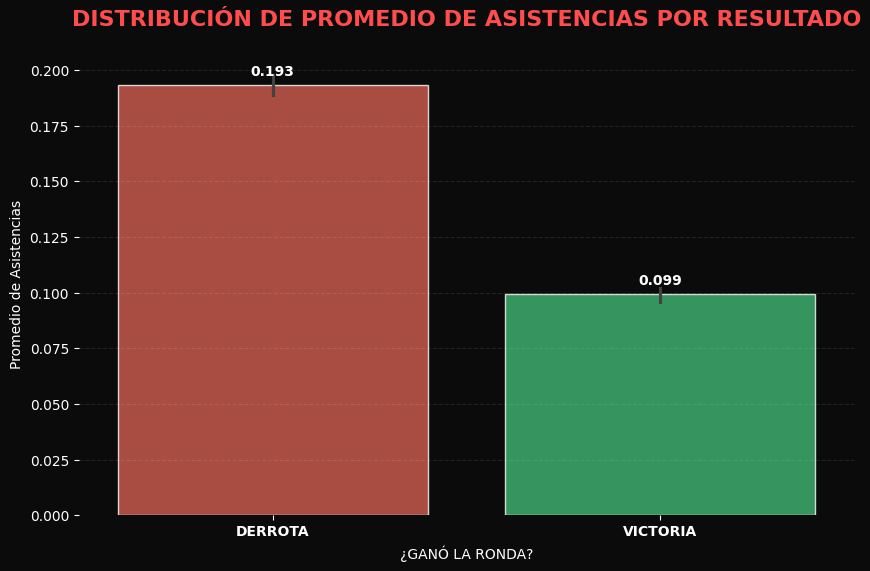

In [23]:
plt.figure(figsize=(10, 6), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

# Corregimos el FutureWarning asignando hue=x y legend=False
sns.barplot(
    data=df,
    x='RoundWinner',
    y='RoundAssists',
    hue='RoundWinner',
    order=['False', 'True'],
    palette={'False': '#e74c3c', 'True': '#2ecc71'},
    legend=False,
    edgecolor='white',
    alpha=0.8
)

# Añadimos etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                color='white', fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

plt.xticks([0, 1], ['DERROTA', 'VICTORIA'], color='white', fontweight='bold')
plt.yticks(color='white')
plt.title('DISTRIBUCIÓN DE PROMEDIO DE ASISTENCIAS POR RESULTADO', fontsize=16, fontweight='bold', color='#ff4d4d', pad=20)
plt.xlabel('¿GANÓ LA RONDA?', color='white')
plt.ylabel('Promedio de Asistencias', color='white')

# Estética final
for spine in ax.spines.values():
    spine.set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.show()

**Análisis del gráfico distribución del promedio de asistencias por el resultado de la ronda**

El análisis de la relación entre el promedio de asistencias por ronda `RoundAssists` y el resultado revela un patrón relevante que aporta información sobre la dinámica de combate.

* **Mayor promedio en rondas perdidas:** Se observa que las rondas perdidas presentan un promedio de asistencias superior (0.193) en comparación con las rondas ganadas (0.099), este comportamiento sugiere que, en escenarios de derrota, los jugadores tienden a infligir daño parcial a múltiples oponentes sin concretar las eliminaciones.

* **Eficiencia en la Victoria:** El bajo promedio de asistencias en victorias indica que las eliminaciones suelen ser más directas, reduciendo la necesidad de intervención de múltiples jugadores sobre un mismo objetivo, esto refleja una mayor eficiencia en la ejecución de los enfrentamientos.

* **Interpretación del fenómeno:** Este patrón no implica necesariamente que las asistencias causen la derrota, sino que actúan como un indicador del tipo de enfrentamientos que se están produciendo, un mayor número de asistencias puede estar asociado a situaciones donde el equipo no logra capitalizar el daño infligido.

En conclusión, `RoundAssists` puede considerarse un indicador complementario del desempeño, aportando información sobre la eficiencia en los enfrentamientos, sin embargo, su valor predictivo debe evaluarse en conjunto con otras variables como `RoundKills`, ya que por sí sola no explica completamente el resultado de la ronda, este comportamiento sugiere la existencia de relaciones entre variables que podrían ser relevantes para el modelado, especialmente al considerar interacciones o combinaciones de características.

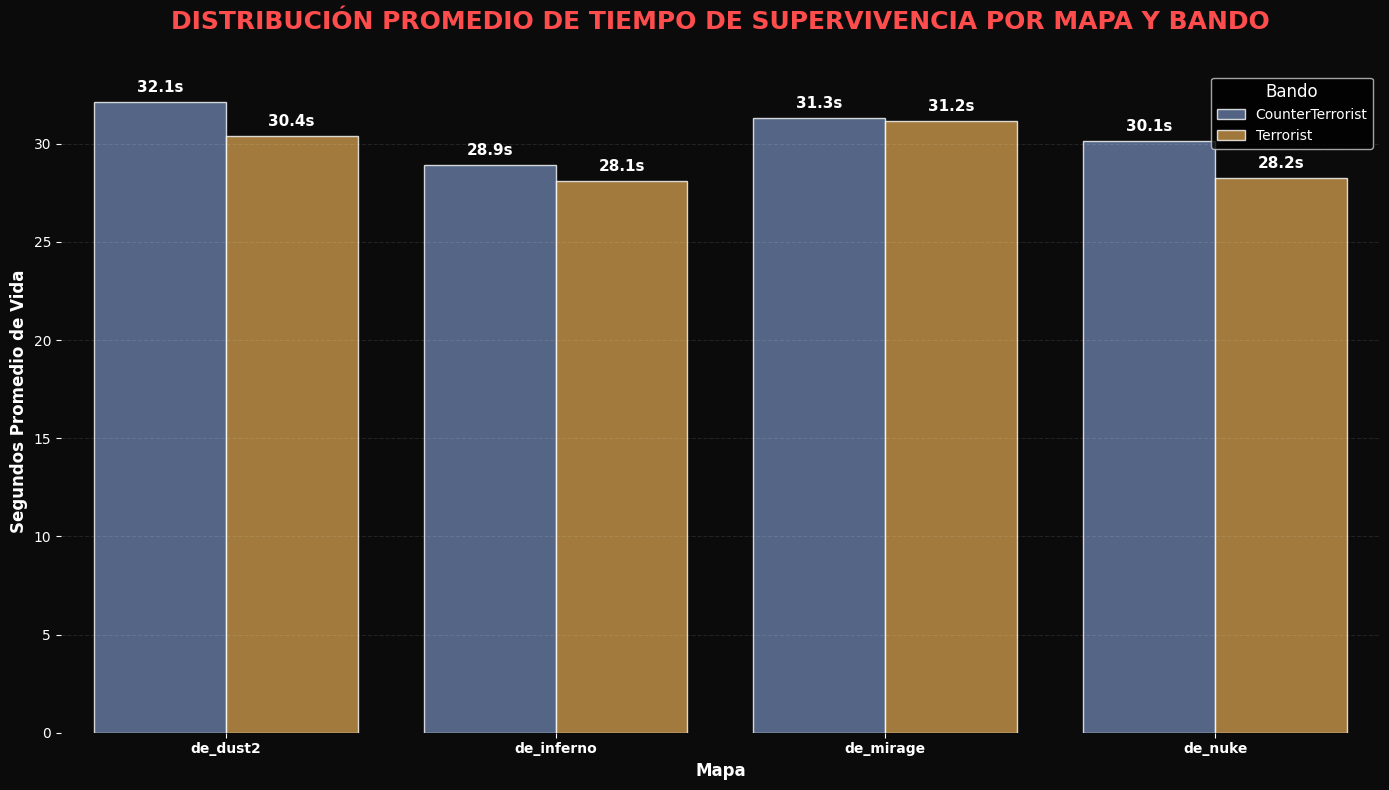

In [24]:
def clean_time(x):
    try:
        if pd.isna(x) or x == '': return 0
        val = str(x).strip()
        # Manejar formato con mùltiples puntos (extraer parte significativa)
        if val.count('.') > 1: val = val.split('.')[0]
        # Formato MM:SS
        if ':' in val:
            parts = val.split(':')
            return int(parts[0]) * 60 + int(parts[1])
        num_val = float(val)
        # Escalar valores de nanosegundos o muy altos
        if num_val > 1000000: return (num_val / 1e9) % 115
        return num_val if num_val < 200 else 200
    except:
        return 0

df['TimeAlive_Sec'] = df['TimeAlive'].apply(clean_time)
# Agrupamos por Mapa y Bando (Team)
map_team_survival = df.groupby(['Map', 'Team'])['TimeAlive_Sec'].mean().reset_index()

plt.style.use('dark_background')
plt.figure(figsize=(14, 8), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

# Colores temáticos para los bandos
team_colors = {'Terrorist': '#de9b35', 'CounterTerrorist': '#5d79ae'}

sns.barplot(data=map_team_survival, x='Map', y='TimeAlive_Sec', hue='Team', palette=team_colors, edgecolor='white', alpha=0.8)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}s', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', color='white', fontweight='bold', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.title('DISTRIBUCIÓN PROMEDIO DE TIEMPO DE SUPERVIVENCIA POR MAPA Y BANDO', fontsize=18, fontweight='bold', color='#ff4d4d', pad=30)
plt.xlabel('Mapa', fontsize=12, color='white', fontweight='bold')
plt.ylabel('Segundos Promedio de Vida', fontsize=12, color='white', fontweight='bold')
plt.xticks(color='white', fontweight='bold')
plt.yticks(color='white')
plt.legend(title='Bando', title_fontsize='12', loc='upper right')

for spine in ax.spines.values(): spine.set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

**Análisis del gráfico distribución de supervivencia por bando de cada mapa**

El análisis del tiempo de supervivencia `TimeAlive` por bando y mapa permite identificar patrones relevantes asociados a la dinámica del juego y su posible impacto en el modelado.

* **Diferencias por bando:** En mapas como `de_dust2` y `de_nuke`, el bando **CounterTerrorist** presenta mayores tiempos de supervivencia que **Terrorist**, este comportamiento es consistente con el rol defensivo, donde los **CT** mantienen posiciones más estables, mientras que los **Terroristas** deben exponerse al avanzar, esto sugiere que la variable `Team` influye directamente en la distribución de `TimeAlive`, por lo que ambas deben analizarse de forma conjunta en el modelo.

* **Variación según el mapa:** En `de_inferno`, los tiempos de supervivencia son menores y más homogéneos entre bandos, lo que indica enfrentamientos más tempranos, en contraste, `de_mirage` presenta distribuciones más equilibradas, sugiriendo un entorno más simétrico, estas diferencias evidencian que el mapa condiciona la dinámica de supervivencia, por lo que su inclusión en el modelo resulta relevante.

* **Relación con la duración de la ronda:** Los valores promedio de `TimeAlive` se sitúan significativamente por debajo de la duración máxima de una ronda, lo que indica que la mayoría de los eventos críticos ocurre en etapas tempranas, esto sugiere que la variable captura información temporal relevante sobre el desarrollo de la ronda.

En conclusión, `TimeAlive` refleja patrones asociados al rol del equipo, el mapa y el momento en que ocurren los enfrentamientos, por ello, se considera una variable con potencial valor predictivo, especialmente cuando se combina con variables como `Team`, `Map` y **métricas** de desempeño, su inclusión en el modelo permitiría capturar dinámicas temporales que influyen en el resultado de la ronda.

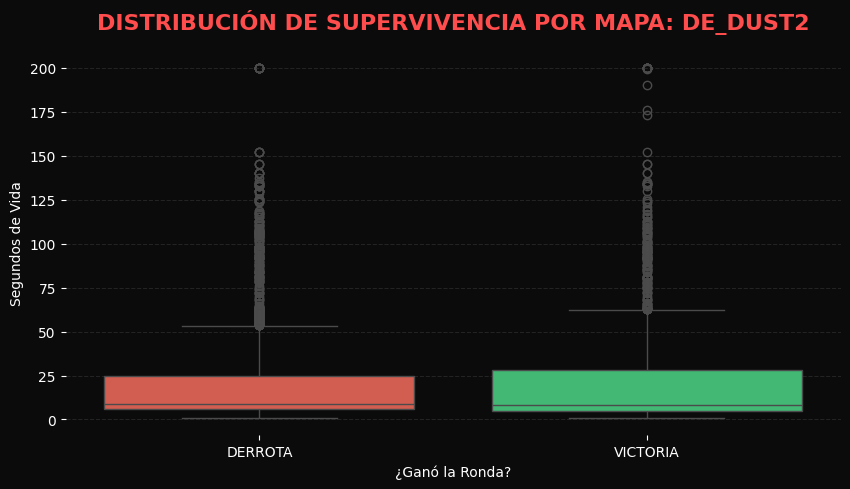

--- RESUMEN DE SUPERVIVENCIA POR MAPA de_dust2 ---


,count,mean,std,min,25%,50%,75%,max
RoundWinner,,,,,,,,
False,9560.0,31.96,56.58,1.0,6.0,9.0,25.0,200.0
True,9560.0,30.55,54.60,1.0,5.0,8.0,28.0,200.0


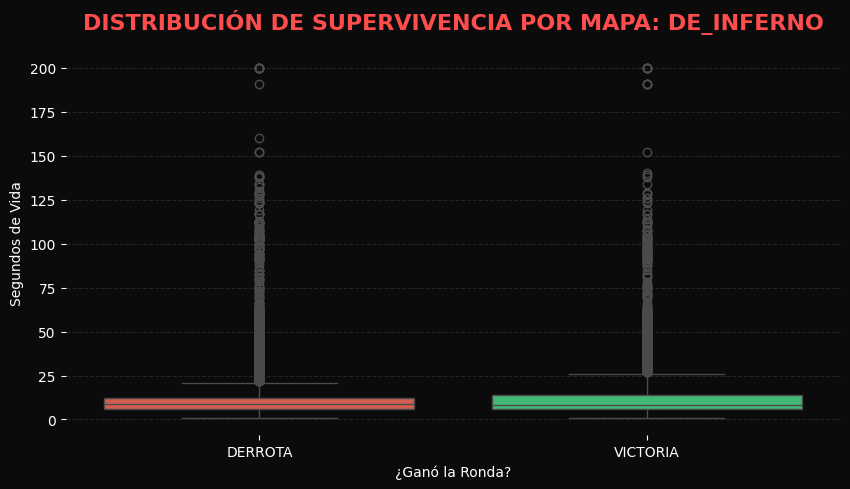

--- RESUMEN DE SUPERVIVENCIA POR MAPA de_inferno ---


,count,mean,std,min,25%,50%,75%,max
RoundWinner,,,,,,,,
False,14440.0,28.18,52.81,1.0,6.0,9.0,12.0,200.0
True,14429.0,28.86,53.33,1.0,6.0,8.0,14.0,200.0


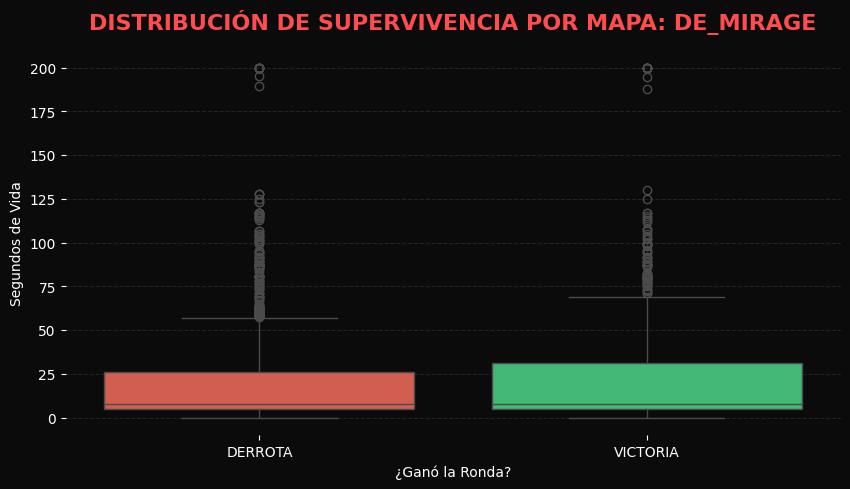

--- RESUMEN DE SUPERVIVENCIA POR MAPA de_mirage ---


,count,mean,std,min,25%,50%,75%,max
RoundWinner,,,,,,,,
False,9515.0,30.56,54.84,0.0,5.0,8.0,26.00,200.0
True,9504.0,31.91,55.76,0.0,5.0,8.0,31.25,200.0


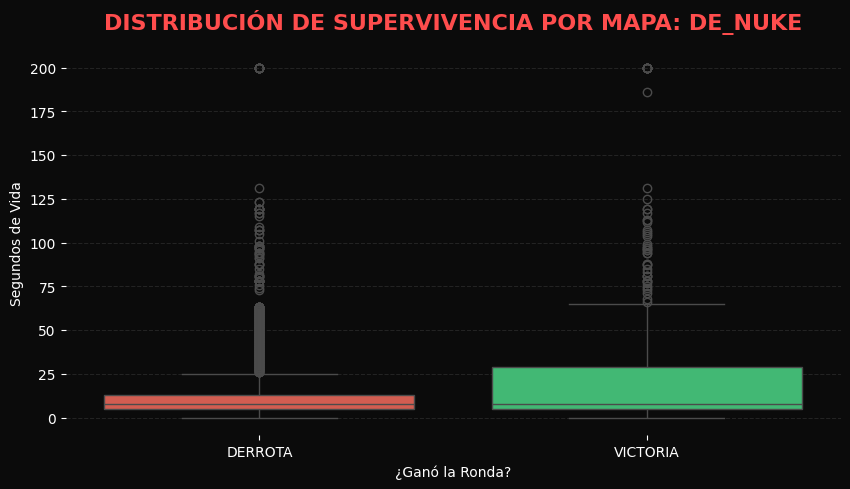

--- RESUMEN DE SUPERVIVENCIA POR MAPA de_nuke ---


,count,mean,std,min,25%,50%,75%,max
RoundWinner,,,,,,,,
False,6074.0,28.94,53.11,0.0,5.0,8.0,13.0,200.0
True,6075.0,29.41,53.15,0.0,5.0,8.0,29.0,200.0


In [25]:
# Análisis de supervivencia detallado por cada mapa en el dataset
maps_list = sorted(df['Map'].unique())

for mapa in maps_list:
    df_mapa = df[df['Map'] == mapa]

    # Crear figura para el mapa actual
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 5), facecolor='#0b0b0b')
    ax = plt.gca()
    ax.set_facecolor('#0b0b0b')

    sns.boxplot(
        data=df_mapa,
        x='RoundWinner',
        y='TimeAlive_Sec',
        hue='RoundWinner',
        palette={'False': '#e74c3c', 'True': '#2ecc71'},
        order=['False', 'True'],
        legend=False
    )

    plt.title(f'DISTRIBUCIÓN DE SUPERVIVENCIA POR MAPA: {mapa.upper()}', fontsize=16, fontweight='bold', color='#ff4d4d', pad=15)
    plt.xlabel('¿Ganó la Ronda?', color='white')
    plt.ylabel('Segundos de Vida', color='white')
    plt.xticks([0, 1], ['DERROTA', 'VICTORIA'], color='white')
    plt.yticks(color='white')

    for spine in ax.spines.values(): spine.set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.1)

    plt.show()

    print(f"\033[1;33m--- RESUMEN DE SUPERVIVENCIA POR MAPA {mapa} ---\033[0m")
    # Aplicamos redondeo a 2 decimales para mejorar la legibilidad
    display(df_mapa.groupby('RoundWinner')['TimeAlive_Sec'].describe().round(2))
    print("\n" + "="*80 + "\n")

**Análisis del gráfico distribución de supervivencia**

El análisis de la distribución del tiempo de supervivencia `TimeAlive` permite identificar patrones relevantes en relación con el resultado de la ronda.

* **Diferencias en percentiles superiores:** En mapas como `de_dust2` y `de_mirage`, los jugadores en rondas ganadas tienden a presentar valores más altos en el percentil 75 (alrededor de 29 segundos), mientras que en rondas perdidas estos valores se sitúan por debajo (aproximadamente 26 segundos), esta diferencia sugiere que una mayor permanencia en la ronda se asocia con una mayor probabilidad de victoria, especialmente en etapas posteriores del enfrentamiento.

* **Similitud en la mediana:** La mediana del tiempo de supervivencia se mantiene baja y similar entre rondas ganadas y perdidas (alrededor de 8–9 segundos), lo que indica que los enfrentamientos iniciales afectan de manera transversal a ambos resultados, esto sugiere que la diferencia entre ganar o perder no está en evitar el contacto inicial, sino en el desempeño posterior.

* **Alta variabilidad:** La desviación estándar elevada (54 segundos) refleja una alta dispersión en los datos, indicando la coexistencia de eliminaciones tempranas y supervivencias prolongadas, este comportamiento evidencia que la variable presenta una distribución amplia, lo que puede aportar información relevante al modelo, pero también requerir escalamiento adecuado.

* **Influencia del mapa:** Se observan diferencias leves en la distribución según el mapa, donde escenarios más abiertos como `de_dust2` tienden a mostrar tiempos de supervivencia ligeramente mayores, mientras que mapas más cerrados como `de_inferno` presentan distribuciones más comprimidas, esto refuerza la idea de que el contexto del mapa influye en la dinámica temporal de la ronda.

En resumen, el tiempo de supervivencia muestra una relación positiva con el resultado de la ronda, especialmente en los percentiles superiores, lo que sugiere que su valor predictivo se concentra en etapas avanzadas del enfrentamiento, sin embargo, su alta variabilidad e similitud en etapas iniciales indican que debe analizarse en conjunto con otras variables, por ello, `TimeAlive` se posiciona como una variable relevante que podría capturar dinámicas temporales del juego, especialmente al combinarse con variables como `Team`, `Map` o **métricas** de desempeño.


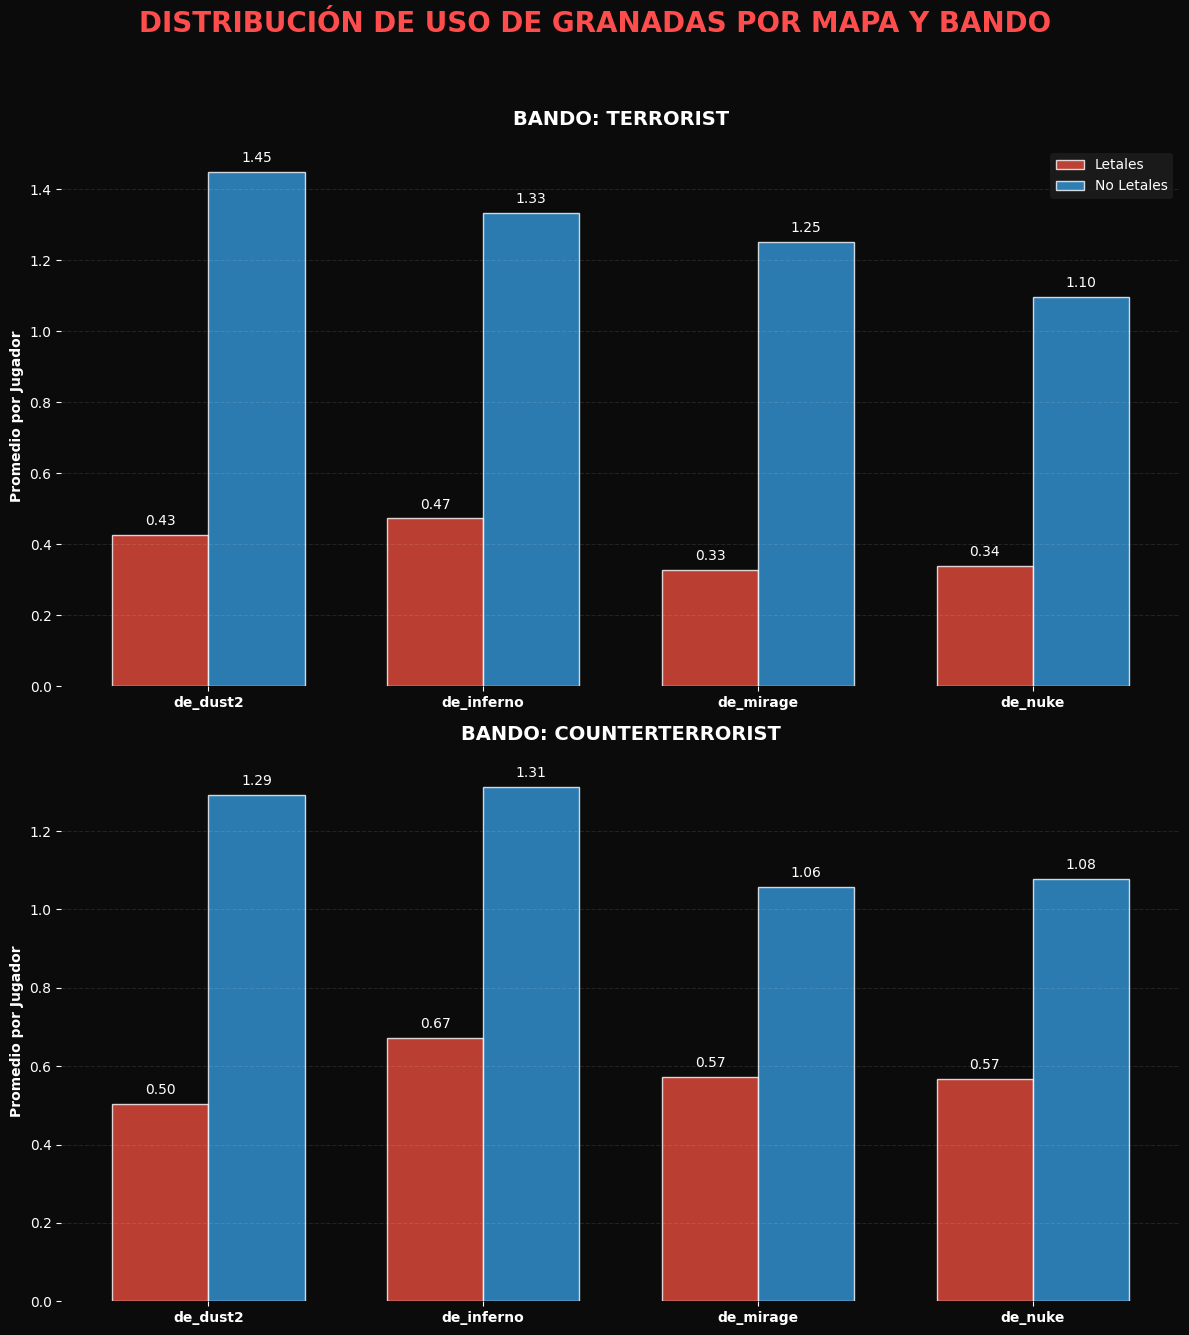

In [26]:
# Análisis de uso de granadas por mapa y bando (Vertical y Separados)
grenade_stats = df.groupby(['Map', 'Team'])[['RLethalGrenadesThrown', 'RNonLethalGrenadesThrown']].mean().reset_index()

teams = ['Terrorist', 'CounterTerrorist']
# 2 filas, 1 columna con mayor altura para dar espacio
fig, axes = plt.subplots(2, 1, figsize=(12, 14), facecolor='#0b0b0b')

for i, team in enumerate(teams):
    team_data = grenade_stats[grenade_stats['Team'] == team]
    ax = axes[i]
    ax.set_facecolor('#0b0b0b')

    x = np.arange(len(team_data['Map']))
    width = 0.35

    ax.bar(x - width/2, team_data['RLethalGrenadesThrown'], width, label='Letales', color='#e74c3c', alpha=0.8, edgecolor='white')
    ax.bar(x + width/2, team_data['RNonLethalGrenadesThrown'], width, label='No Letales', color='#3498db', alpha=0.8, edgecolor='white')

    # Personalización
    ax.set_title(f'BANDO: {team.upper()}', fontsize=14, fontweight='bold', color='white', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(team_data['Map'], color='white', fontweight='bold')
    ax.tick_params(axis='y', colors='white')
    ax.set_ylabel('Promedio por Jugador', color='white', fontweight='bold')

    # Etiquetas
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', color='white', fontsize=10, xytext=(0, 5), textcoords='offset points')

    # Estética de ejes
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.1)

plt.suptitle('DISTRIBUCIÓN DE USO DE GRANADAS POR MAPA Y BANDO', fontsize=20, fontweight='bold', color='#ff4d4d', y=0.98)
axes[0].legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white', loc='upper right')

# hspace añade separación vertical entre los subplots
plt.subplots_adjust(hspace=0.4)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Análisis del gráfico distribución de uso de granadas y utilidad por bando**

El análisis de las variables `RLethalGrenadesThrown` y `RNonLethalGrenadesThrown` por bando permite identificar patrones asociados al rol táctico y su posible impacto en el resultado de la ronda.

* **Diferencias por bando**: Se observa que el bando `CounterTerrorist` tiende a utilizar más granadas letales en comparación con `Terrorist`, especialmente en mapas como `de_inferno`, este comportamiento es consistente con el rol defensivo, donde el uso de daño directo permite controlar zonas clave, por otro lado, los `Terroristas` muestran un uso relativamente mayor de utilidad no letal, orientada a facilitar la entrada a los sitios.

* **Predominio de utilidad no letal**: En ambos bandos, el uso de granadas no letales (smokes y flashes) es superior al de granadas letales, esto sugiere que el control del espacio y la visibilidad juega un rol más relevante que el daño directo en la dinámica del juego.

* **Variación según el mapa**: En mapas abiertos como `de_dust2`, se observa un uso más equilibrado de utilidad entre bandos, lo que indica que ambos requieren herramientas similares para disputar el control del mapa, en contraste, mapas más cerrados como `de_inferno` presentan diferencias más marcadas en el uso de granadas.

* **Relación con otras variables**: El uso de granadas se vincula con variables como `TimeAlive` y el resultado de la ronda, ya que una mayor utilización de utilidad puede influir en el ritmo del juego y en la generación de ventajas tácticas.

En conclusión, las variables relacionadas con el uso de granadas aportan información relevante sobre el estilo de juego y el rol del equipo en cada ronda, no obstante, su capacidad predictiva individual puede ser limitada, por lo que su mayor valor se obtiene al combinarlas con variables de contexto como `Team`, `Map` y **métricas** de desempeño, su inclusión en el modelo permitiría capturar aspectos tácticos que no están reflejados directamente en variables económicas o de bajas.

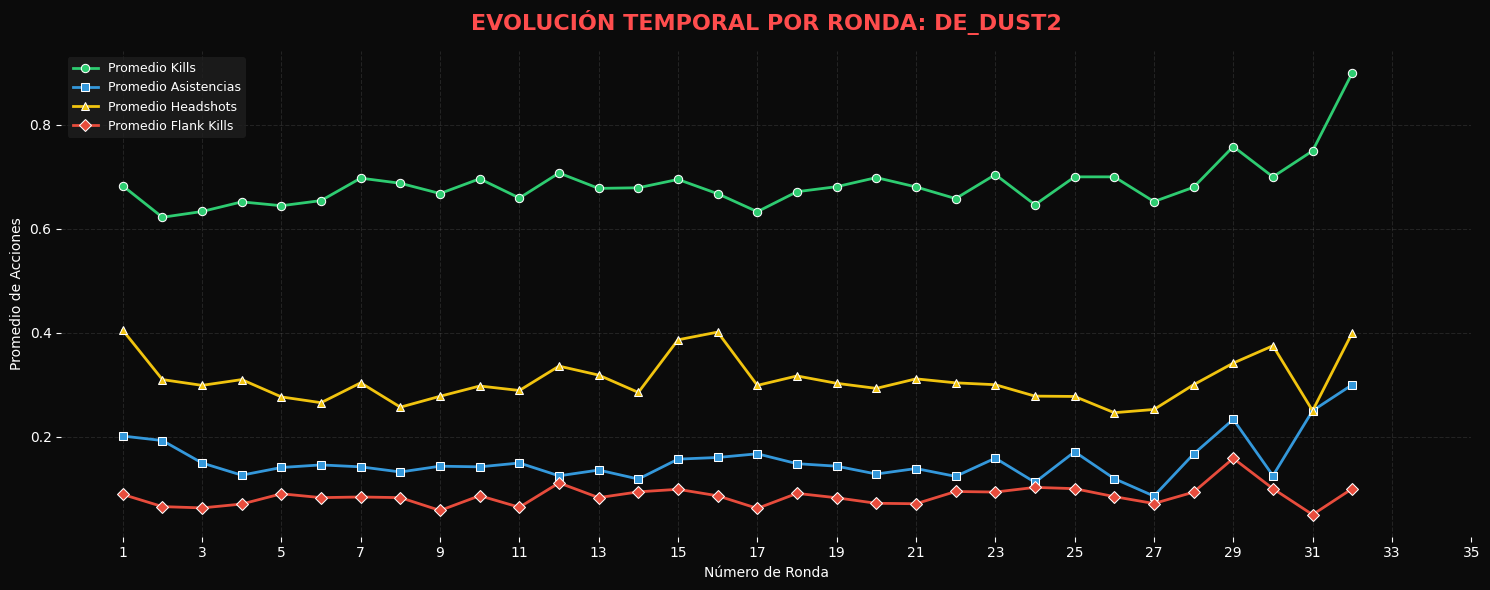

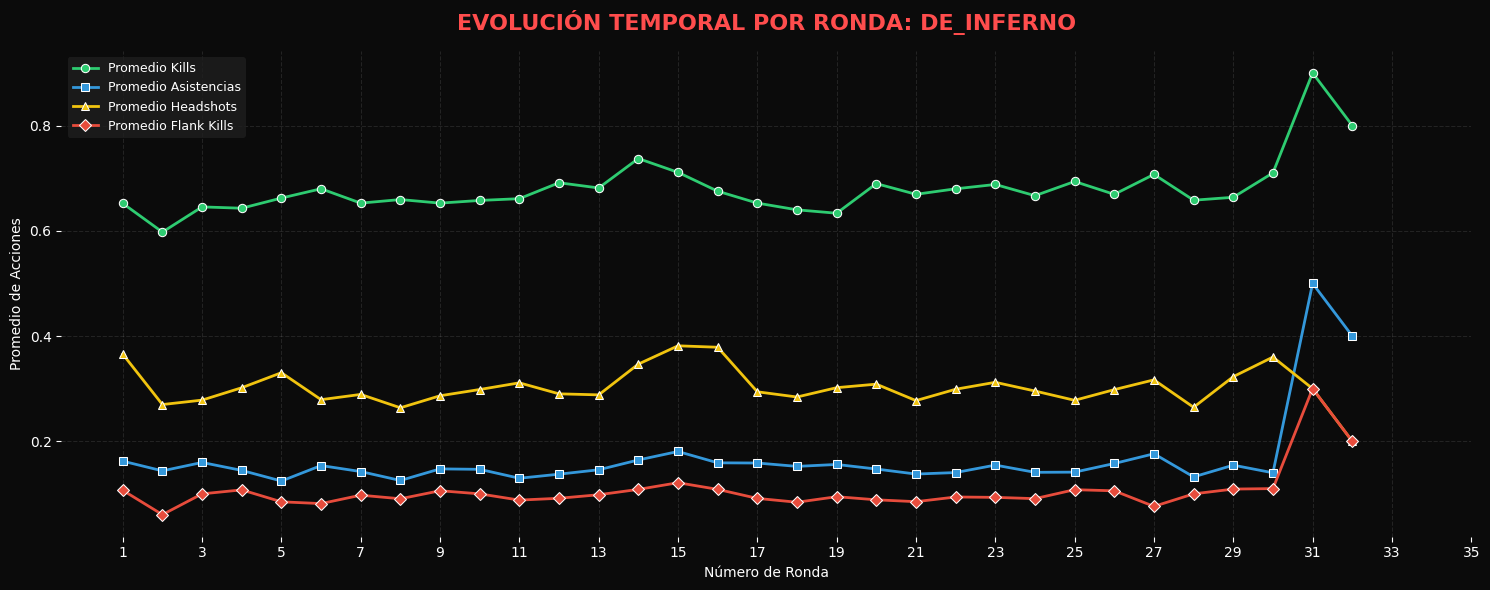

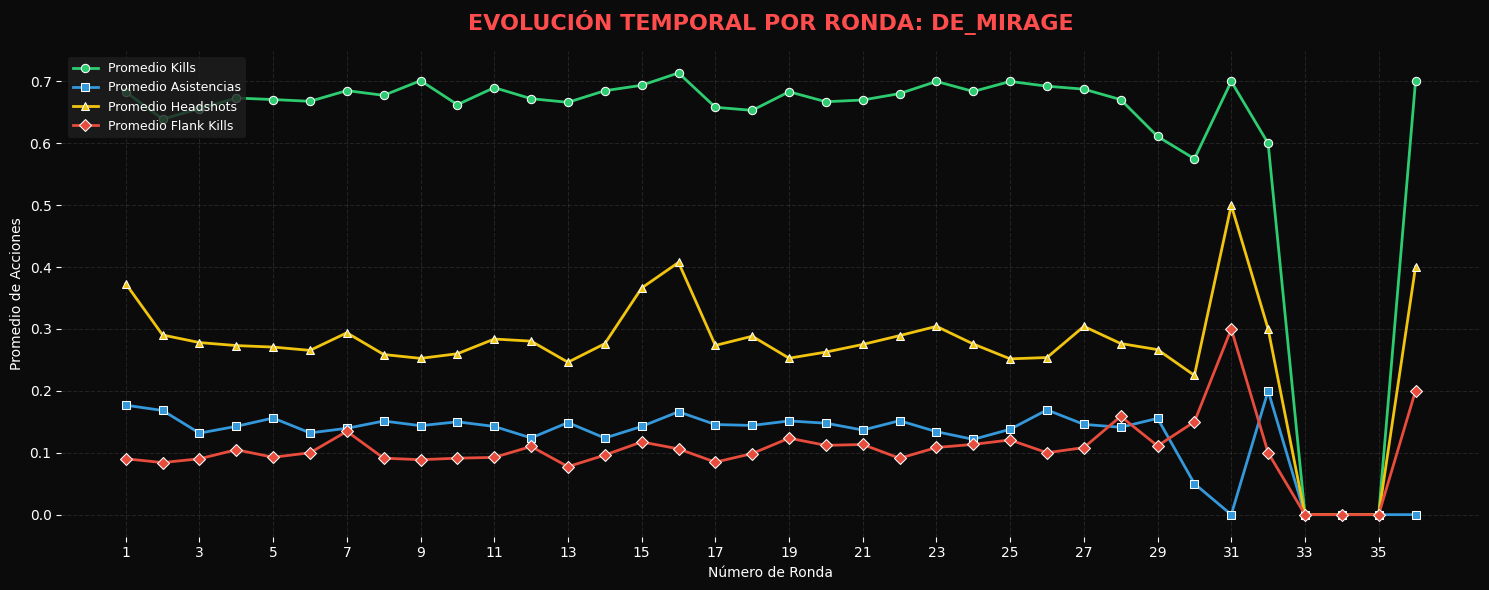

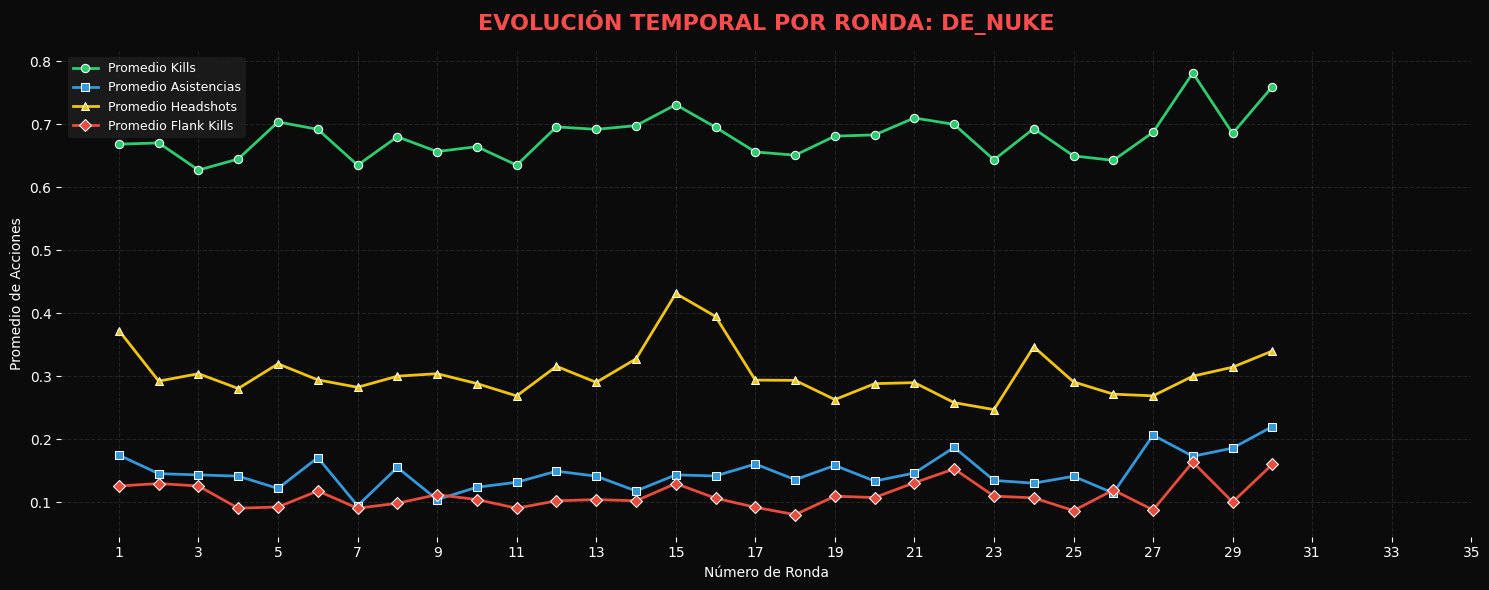

In [27]:
# Agrupar por Map y RoundId para obtener el promedio de desempeño detallado
metrics = ['RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills']
map_round_stats = df.groupby(['Map', 'RoundId'], observed=False)[metrics].mean().reset_index()

# Configuración de estilo dark
plt.style.use('dark_background')
maps = sorted(df['Map'].unique())

# Generar un gráfico independiente por cada mapa
for map_name in maps:
    fig, ax = plt.subplots(figsize=(15, 6), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')
    data_map = map_round_stats[map_round_stats['Map'] == map_name]

    # Dibujar las líneas temporales por mapa
    sns.lineplot(data=data_map, x='RoundId', y='RoundKills', marker='o', color='#2ecc71', label='Promedio Kills', linewidth=2, ax=ax)
    sns.lineplot(data=data_map, x='RoundId', y='RoundAssists', marker='s', color='#3498db', label='Promedio Asistencias', linewidth=2, ax=ax)
    sns.lineplot(data=data_map, x='RoundId', y='RoundHeadshots', marker='^', color='#f1c40f', label='Promedio Headshots', linewidth=2, ax=ax)
    sns.lineplot(data=data_map, x='RoundId', y='RoundFlankKills', marker='D', color='#e74c3c', label='Promedio Flank Kills', linewidth=2, ax=ax)

    # Personalización
    ax.set_title(f'EVOLUCIÓN TEMPORAL POR RONDA: {map_name.upper()}', fontsize=16, fontweight='bold', color='#ff4d4d', pad=15)
    ax.set_xlabel('Número de Ronda', fontsize=10, color='white')
    ax.set_ylabel('Promedio de Acciones', fontsize=10, color='white')

    # Ajustar el eje X para que sea legible
    unique_rounds = data_map['RoundId'].unique()
    if len(unique_rounds) > 15:
        ax.set_xticks(unique_rounds[::2])
    else:
        ax.set_xticks(unique_rounds)

    ax.tick_params(colors='white')
    ax.legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white', fontsize=9, loc='upper left')
    ax.grid(axis='both', linestyle='--', alpha=0.1)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

**Análisis del gráfico temporal por ronda de cada mapa**

El análisis de la evolución de métricas a lo largo de las rondas permite identificar diferencias estructurales entre mapas, las cuales tienen implicancias directas en el modelado.

* **de_dust2**: Presenta una alta relación entre **kills** y **headshots**, lo que indica que el desempeño está fuertemente influenciado por la precisión individual, además, se observa una fuerte dependencia de la economía, donde caídas en `TeamStartingEquipmentValue` impactan directamente en la capacidad ofensiva, esto sugiere que variables económicas y de precisión tienen alto valor predictivo en este mapa.

* **de_inferno**: Muestra mayor volatilidad en métricas como **asistencias** y uso de **utilidad**, reflejando un estilo de juego *más dependiente de granadas y control de zonas*, esto indica que variables relacionadas con utilidad y soporte tienen mayor relevancia relativa en comparación con métricas puramente individuales.

* **de_mirage**: Se caracteriza por una mayor estabilidad en las métricas a lo largo de las rondas, lo que sugiere un entorno más predecible, esta menor variabilidad podría facilitar el aprendizaje del modelo, generando predicciones más consistentes.

* **de_nuke**: Presenta cambios abruptos en las métricas, indicando rondas que se resuelven rápidamente, esto sugiere una mayor complejidad en la dinámica del juego, donde variables ***relacionadas con posicionamiento y tiempo pueden tener un impacto significativo***.

En conclusión, los resultados evidencian que el comportamiento de las variables no es uniforme entre mapas, lo que implica que un modelo único podría no capturar adecuadamente todas las dinámicas del juego, por ello, se considerar el **mapa** como una variable clave dentro del modelo o incluso evaluar enfoques segmentados que permitan capturar mejor las particularidades de cada entorno.

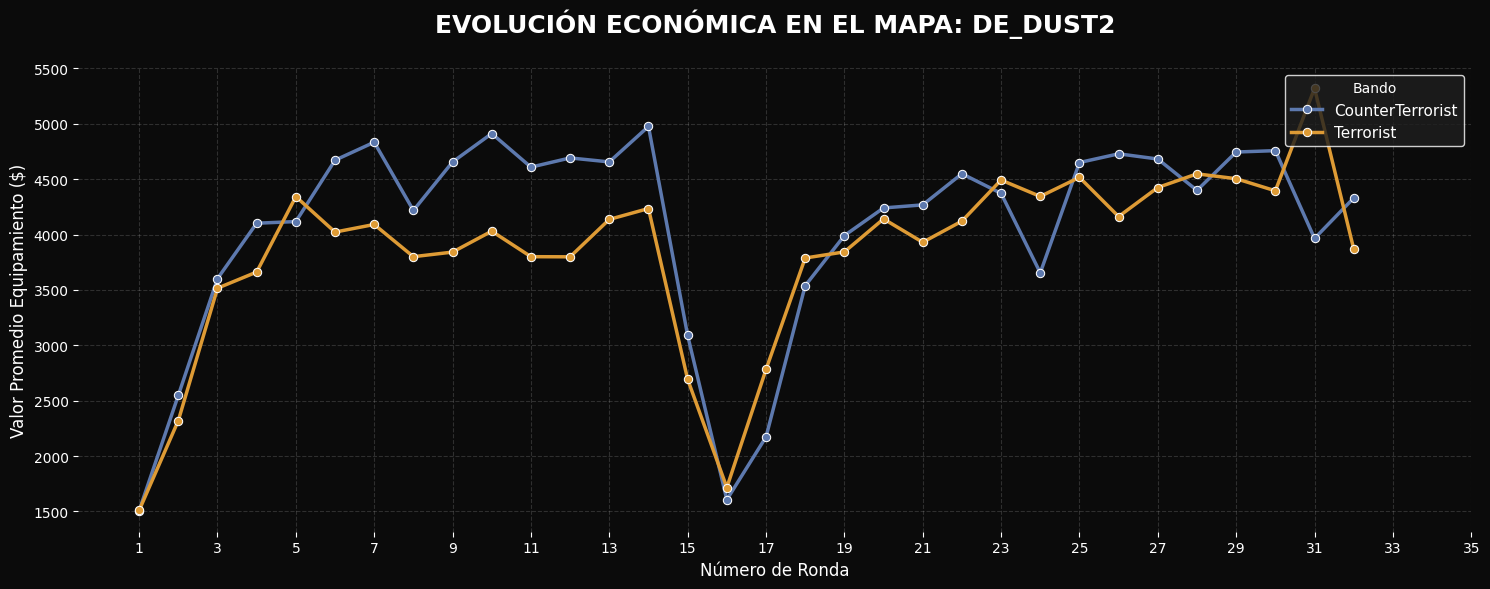

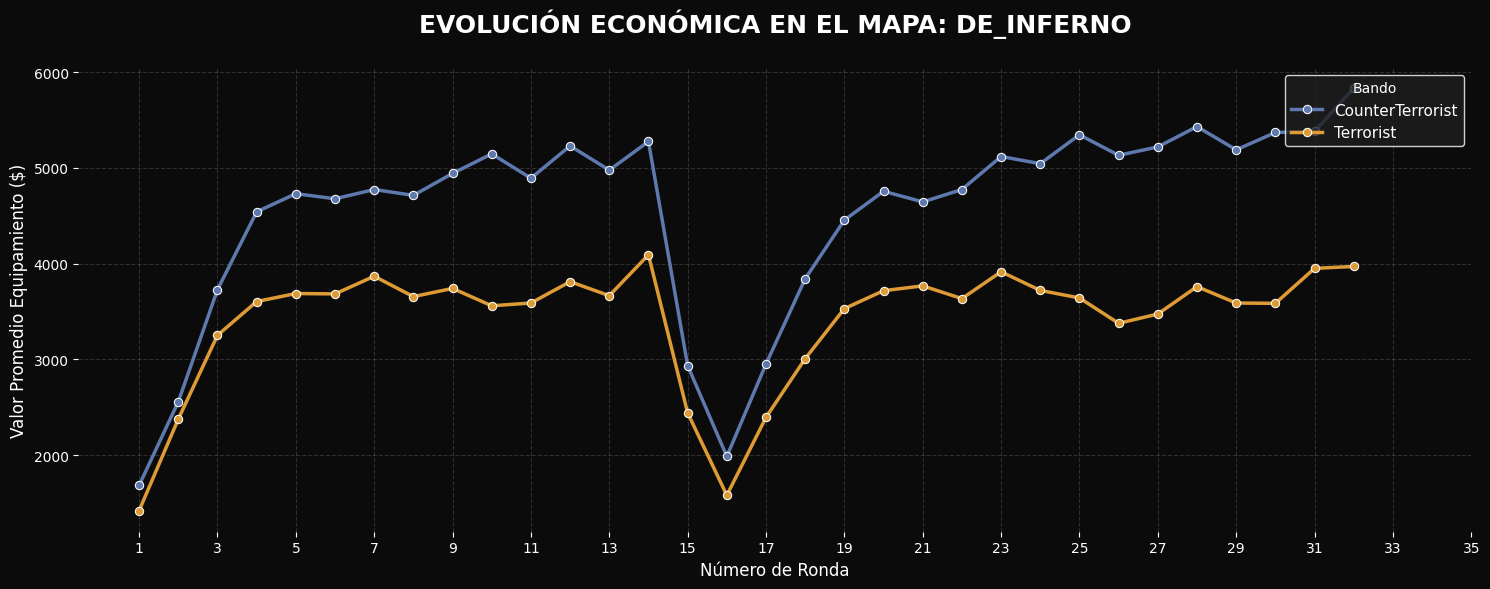

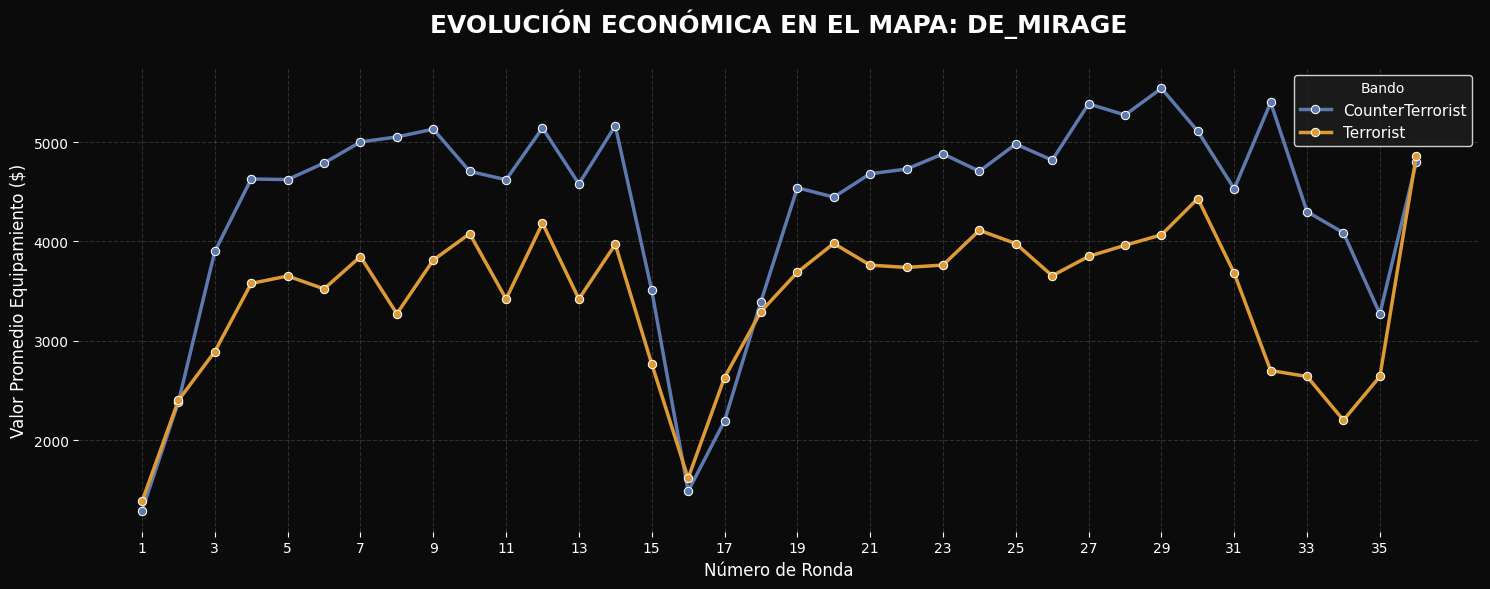

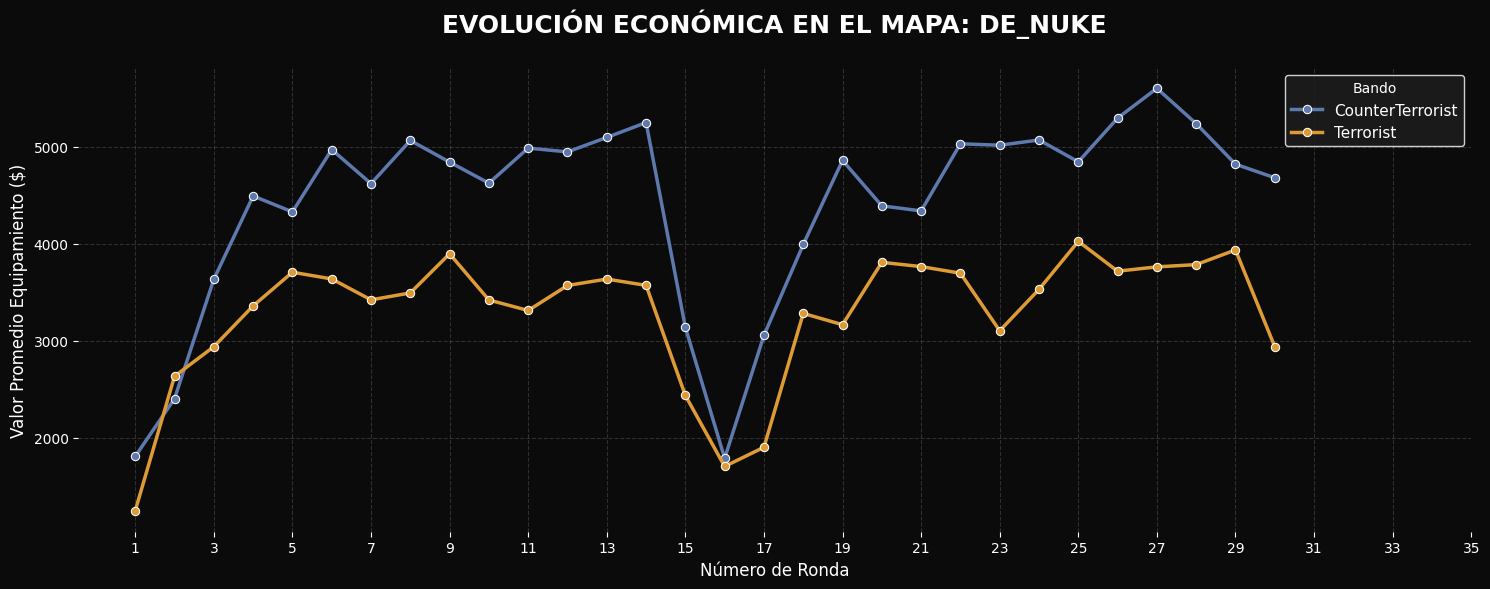

In [28]:
# Agrupamos por Mapa, Bando y Ronda para ver la tendencia económica detallada
eco_team_trend = df.groupby(['Map', 'RoundId', 'Team'], observed=False)['RoundStartingEquipmentValue'].mean().reset_index()

# Colores específicos para los bandos
team_colors = {'Terrorist': '#de9b35', 'CounterTerrorist': '#5d79ae'}

plt.style.use('dark_background')

# Iteramos por cada mapa para crear gráficos independientes
for map_name in sorted(df['Map'].unique()):
    fig, ax = plt.subplots(figsize=(15, 6), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')

    subset_map = eco_team_trend[eco_team_trend['Map'] == map_name]

    # Graficamos una línea por cada bando (Team)
    sns.lineplot(data=subset_map, x='RoundId', y='RoundStartingEquipmentValue',
                 hue='Team', palette=team_colors, marker='o', linewidth=2.5, ax=ax)

    ax.set_title(f'EVOLUCIÓN ECONÓMICA EN EL MAPA: {map_name.upper()}', fontsize=18, fontweight='bold', color='#ffffff', pad=25)
    ax.set_xlabel('Número de Ronda', fontsize=12, color='white')
    ax.set_ylabel('Valor Promedio Equipamiento ($)', fontsize=12, color='white')

    # Ajuste de ticks para legibilidad
    unique_rounds = subset_map['RoundId'].unique()
    ax.set_xticks(unique_rounds[::2])
    plt.xticks(color='white')
    plt.yticks(color='white')

    ax.legend(title='Bando', facecolor='#1e1e1e', edgecolor='white', labelcolor='white', fontsize=11, loc='upper right')
    ax.grid(axis='both', linestyle='--', alpha=0.15)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

**Análisis comparativo del gráfico evolución economía por bando y cada mapa**

El análisis de la evolución del valor de equipamiento por bando permite identificar dinámicas económicas clave que influyen directamente en el resultado de las rondas.

* **Efecto acumulativo de la economía**: Se observa un comportamiento tipo bola de nieve, donde el bando que logra mantener una economía alta durante varias rondas consecutivas incrementa su ventaja, mientras el equipo rival entra en ciclos de baja inversión, este patrón indica que la economía tiene una fuerte dependencia temporal, lo que sugiere que el estado económico previo influye en el resultado actual.

* **Diferencias estructurales entre bandos**: En mapas como `de_dust2`, el bando `CounterTerrorist` requiere mantener un nivel de inversión mayor para ser competitivo, debido al mayor costo de su equipamiento, esto implica que el mismo valor absoluto de equipamiento puede tener impactos distintos según el bando, por lo que esta variable debe interpretarse en contexto.

* **Recuperación económica tras cambios de ronda**: En mapas como `de_mirage`, ambos bandos muestran una recuperación económica similar tras eventos clave (como el cambio de lado), lo que refleja un comportamiento más equilibrado, en otros mapas, uno de los bandos logra recuperar ventaja más rápidamente, generando diferencias sostenidas en el tiempo.

* **Zonas de inversión media**: Se identifican rangos donde ambos equipos convergen en valores intermedios de equipamiento, lo que corresponde a decisiones de inversión forzada, estas situaciones representan escenarios de alta incertidumbre, donde el resultado de la ronda puede romper la dinámica económica previa.

Para el modelo predictivo, los resultados indican que el valor absoluto de equipamiento no es suficiente para explicar el resultado de la ronda, en cambio, el diferencial económico entre equipos `Delta_EquipmentValue` se posiciona como una variable más representativa, ya que captura la ventaja relativa en cada enfrentamiento, por ello, se podria llegar a considerar su incorporación en el modelo, junto con el contexto de bando y mapa, para mejorar la capacidad predictiva.

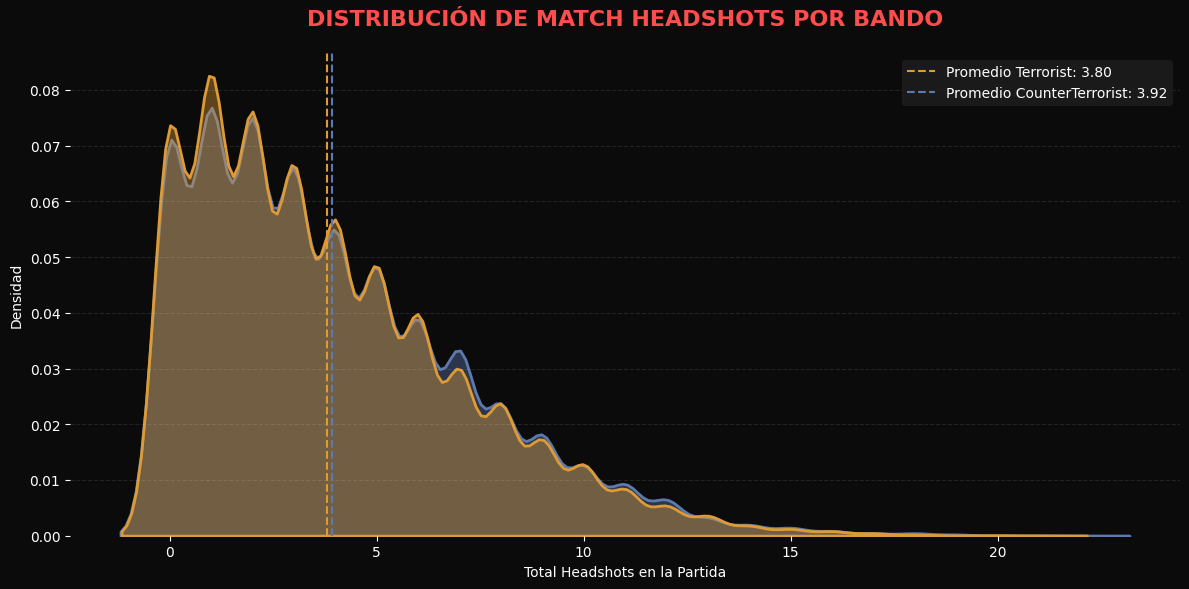

In [29]:
plt.figure(figsize=(12, 6), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

# Colores temáticos para los bandos
team_colors = {'Terrorist': '#de9b35', 'CounterTerrorist': '#5d79ae'}

# Crear el gráfico de densidad (KDE) comparativo
sns.kdeplot(data=df, x='MatchHeadshots', hue='Team', palette=team_colors, fill=True, alpha=0.4, linewidth=2)

# Añadir líneas de promedio para cada bando
for team, color in team_colors.items():
    avg_val = df[df['Team'] == team]['MatchHeadshots'].mean()
    plt.axvline(avg_val, color=color, linestyle='--', label=f'Promedio {team}: {avg_val:.2f}')

plt.title('DISTRIBUCIÓN DE MATCH HEADSHOTS POR BANDO', fontsize=16, fontweight='bold', color='#ff4d4d', pad=20)
plt.xlabel('Total Headshots en la Partida', color='white')
plt.ylabel('Densidad', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white')

for spine in ax.spines.values():
    spine.set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

**Análisis del gráfico distribución de Match Headshots por bando**

El análisis de la distribución de headshots acumulados por partida `MatchHeadshots` permite evaluar posibles diferencias en la precisión entre bandos.

* **Simetría entre equipos**: Las distribuciones de ambos bandos presentan formas muy similares, con promedios cercanos (3.80 para **Terrorist** y 3.92 para **CounterTerrorist**), esto indica que no existen diferencias significativas en la cantidad de *headshots* según el bando, sugiriendo un comportamiento homogéneo en términos de precisión.

* **Concentración en valores bajos**: La mayoría de los jugadores se concentra en un rango de 0 a 5 *headshots* por partida, mientras que los valores más altos son poco frecuentes, esto indica que los headshots, aunque relevantes, no son eventos dominantes en la distribución general del desempeño.

* **Variabilidad limitada por bando**: Dado que no se observan diferencias claras entre equipos, la variable `MatchHeadshots` no parece estar influenciada directamente por el rol (ataque o defensa), sino por factores individuales o situacionales.

Conclusión,  los resultados sugieren que `MatchHeadshots` no presenta diferencias relevantes entre bandos, por lo que su valor predictivo no estaría asociado al equipo en sí, sino a su relación con otras métricas de desempeño, por esta razón, su mayor utilidad en el modelo podría encontrarse al combinarse con variables como `MatchKills`, permitiendo capturar de mejor forma la eficiencia en los enfrentamientos.

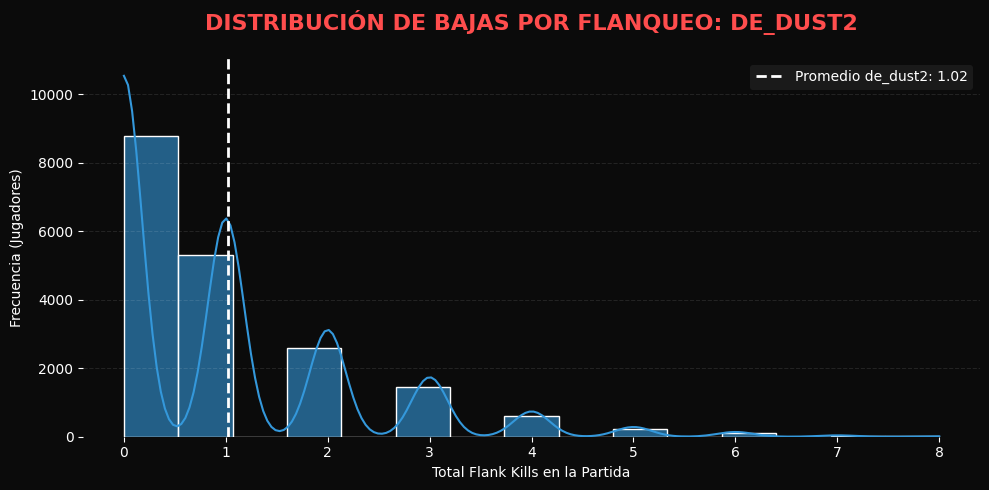

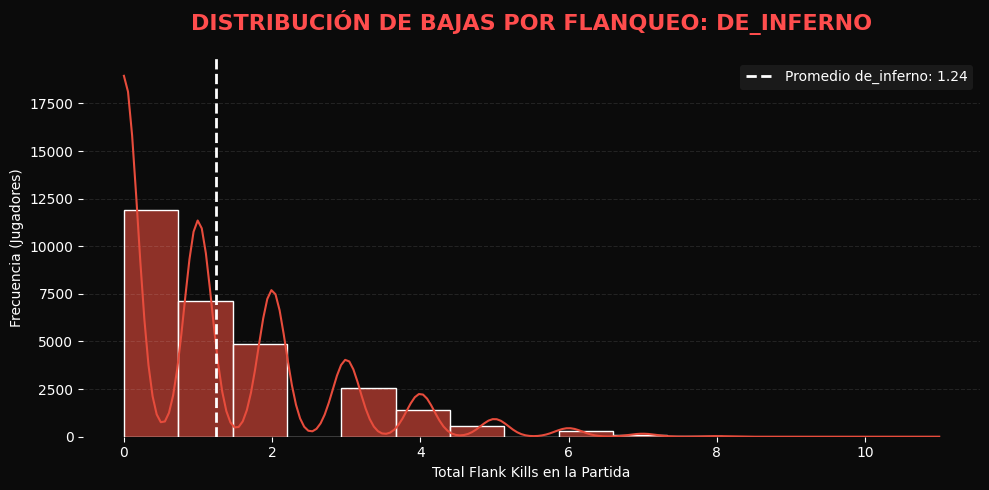

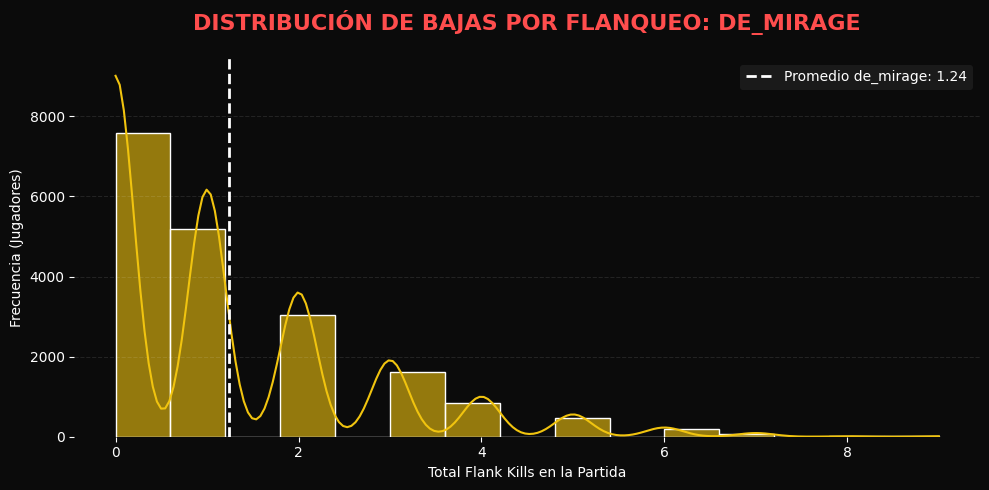

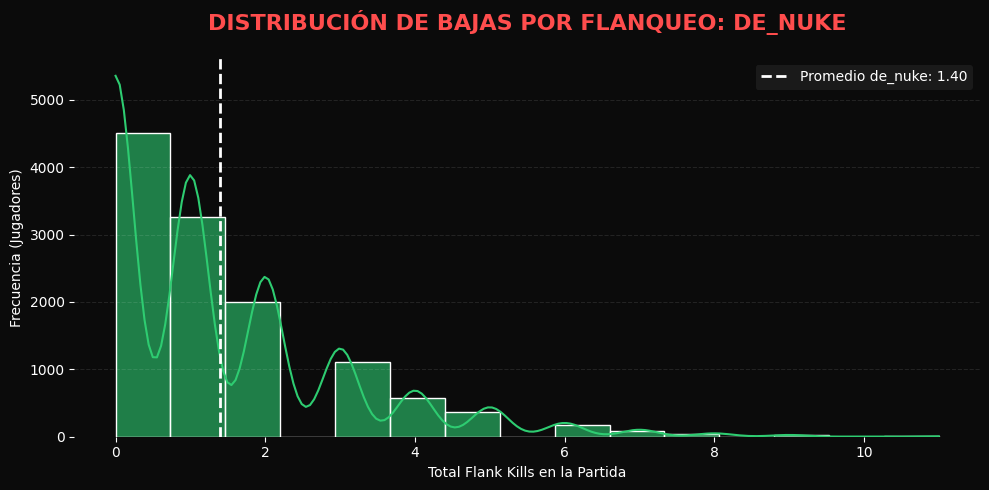

In [30]:
# Análisis de bajas por flanqueo detallado por cada mapa
maps_list = sorted(df['Map'].unique())
map_colors_list = ['#3498db', '#e74c3c', '#f1c40f', '#2ecc71']

for i, mapa in enumerate(maps_list):
    plt.figure(figsize=(10, 5), facecolor='#0b0b0b')
    ax = plt.gca()
    ax.set_facecolor('#0b0b0b')

    # Filtrar datos por mapa
    df_mapa = df[df['Map'] == mapa]

    # Crear el histograma
    sns.histplot(df_mapa['MatchFlankKills'], bins=15, kde=True,
                 color=map_colors_list[i % len(map_colors_list)],
                 alpha=0.6, edgecolor='white')

    # Añadir línea de promedio
    avg_flank = df_mapa['MatchFlankKills'].mean()
    plt.axvline(avg_flank, color='white', linestyle='--', linewidth=2,
                label=f'Promedio {mapa}: {avg_flank:.2f}')

    plt.title(f'DISTRIBUCIÓN DE BAJAS POR FLANQUEO: {mapa.upper()}', fontsize=16, fontweight='bold', color='#ff4d4d', pad=20)
    plt.xlabel('Total Flank Kills en la Partida', color='white')
    plt.ylabel('Frecuencia (Jugadores)', color='white')
    plt.xticks(color='white')
    plt.yticks(color='white')
    plt.legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white')

    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.1)

    plt.tight_layout()
    plt.show()

**Análisis del gráfico distribución de bajas por flanqueo (Match Flank Kills) por Mapa**

El análisis de la distribución de bajas por flanqueo permite evaluar la frecuencia y relevancia de este tipo de jugadas dentro del desempeño general.

* **Un promedio bajo**: En todos los mapas, el promedio de `MatchFlankKills` se mantiene bajo (1.21), lo que indica que este tipo de acciones son poco frecuentes en comparación con otras métricas de desempeño, esto sugiere que su impacto global en el dataset es limitado.

* **Concentración en valores bajos**: La mayoría de los jugadores se ubica en el rango de 0 a 2 bajas por flanqueo, lo que confirma que estas situaciones ocurren en contextos específicos y no representan el comportamiento estándar del juego.

* **Presencia de valores extremos**: Se observa una cola derecha en la distribución, con casos que superan las 5 bajas por flanqueo, estos registros reflejan situaciones particulares y deben ser conservados, aunque su baja frecuencia limita su influencia en el modelo.

* **Variación según el mapa**: Mapas como `de_inferno` y `de_nuke` presentan una mayor dispersión en comparación con otros escenarios, lo que sugiere que ciertas configuraciones de mapa pueden favorecer este tipo de jugadas, sin embargo, estas diferencias no son lo suficientemente consistentes como para generar patrones dominantes.

En conclusión, `MatchFlankKills` representa un comportamiento específico y poco frecuente, por lo que su capacidad predictiva individual es limitada, no obstante, podría aportar valor como variable complementaria, especialmente al combinarse con otras métricas de desempeño o contexto, por ello, su inclusión en el modelo debe evaluarse en función de su contribución real al desempeño predictivo.

### 2.6 Relación entre variables

#### 2.6.1 Correlaciones entre variables numéricas


In [31]:
df['RoundWinner_num'] = df['RoundWinner'].map({
    'True': 1,
    'False': 0
})

df[['RoundKills', 'RoundWinner_num']].corr(method='pearson')

,RoundKills,RoundWinner_num
RoundKills,1.000000,-0.269225
RoundWinner_num,-0.269225,1.000000


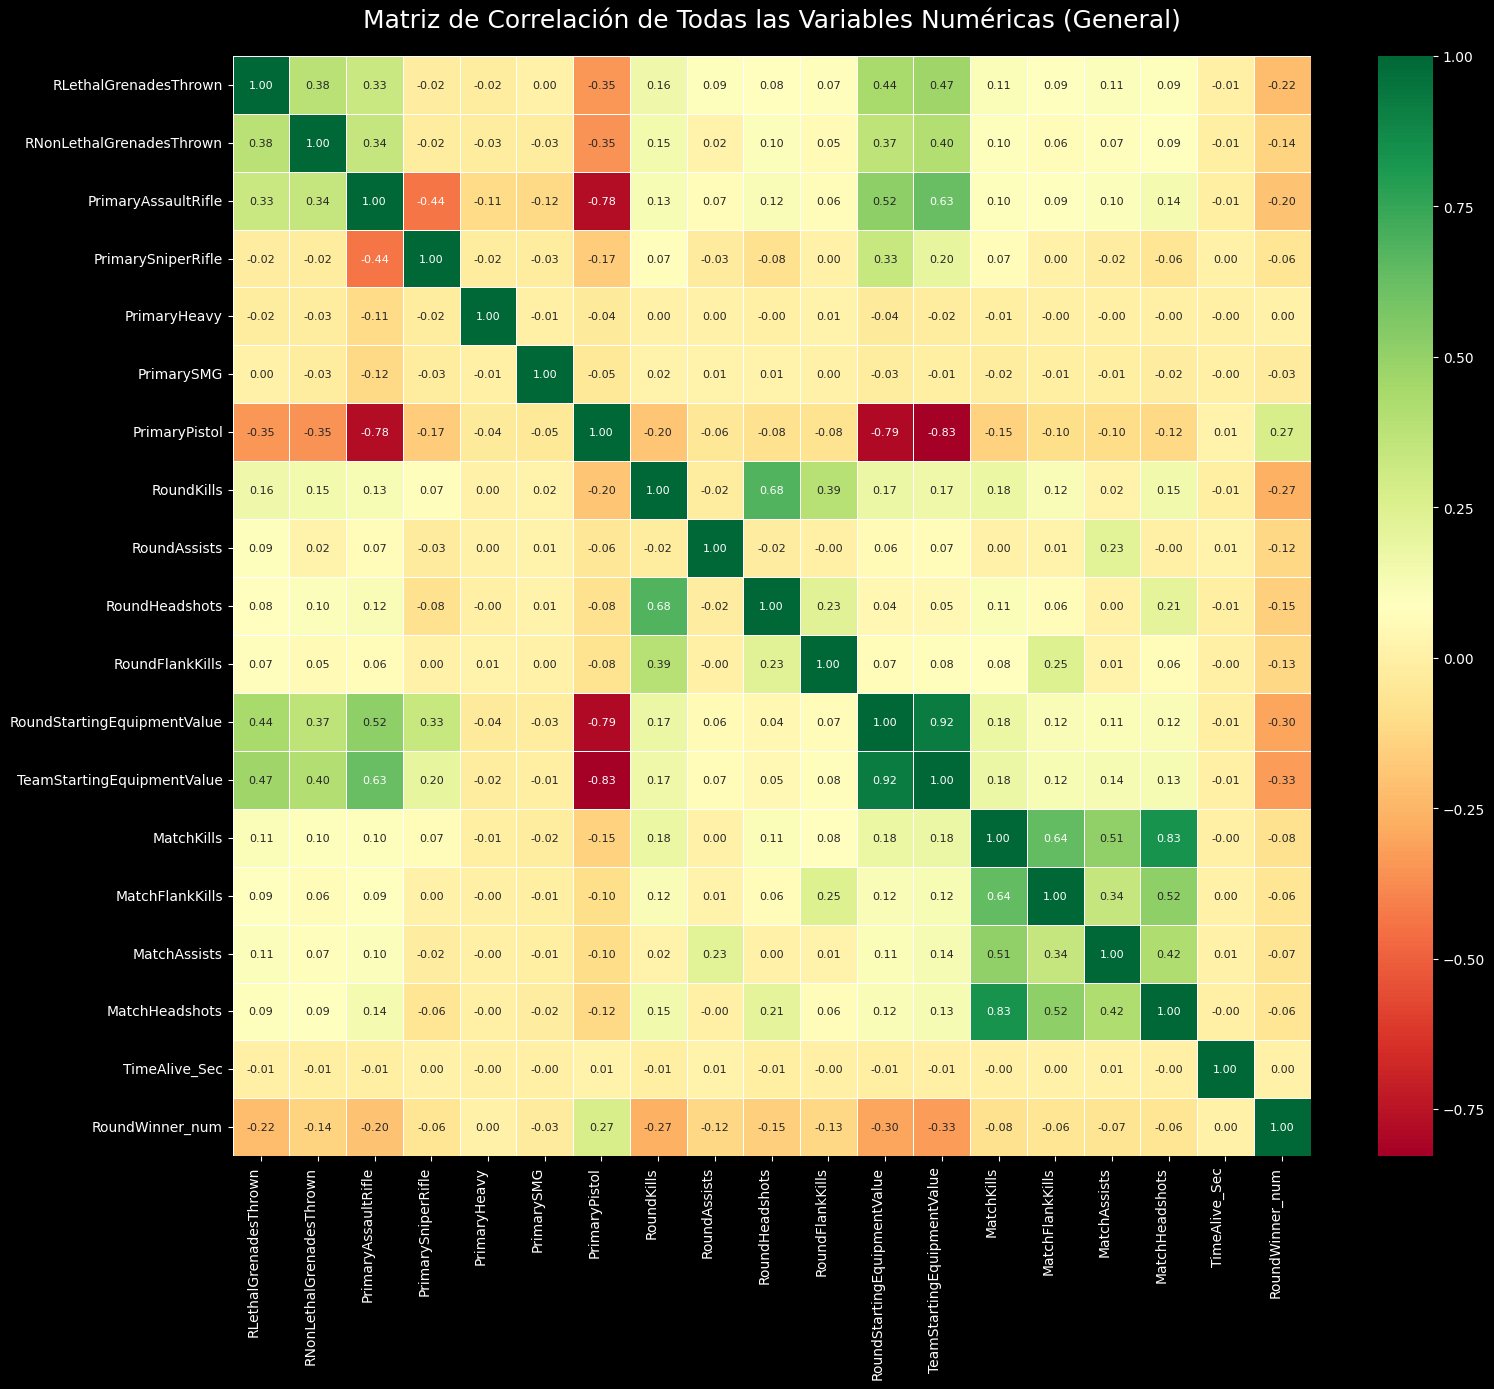

In [32]:
numerical_df = df.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación para todas las variables numéricas
corr_matrix_all = numerical_df.corr()

# Visualización mediante un mapa de calor
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix_all, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5, annot_kws={"size": 8})
plt.title('Matriz de Correlación de Todas las Variables Numéricas (General)', size=18, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Análisis de la Matriz de Correlación (General)**

El análisis de la matriz de correlación permite identificar relaciones lineales entre variables y evaluar su utilidad dentro del modelo predictivo.

* **Redundancia en variables económicas**: Se observa una correlación alta (0.91) entre el valor de equipamiento individual y grupal, lo que indica una fuerte dependencia entre ambas, esto sugiere que ambas variables contienen información similar, por lo que es posible utilizar solo una de ellas (preferentemente la grupal) para reducir redundancia sin pérdida significativa de información.

* **Relaciones entre tipos de armamento:** Existe una correlación negativa entre el uso de rifles de asalto y pistolas (-0.75), lo que refleja patrones de compra excluyentes asociados a distintos estados económicos, asimismo, se observa una correlación negativa moderada entre rifles de asalto y francotiradores, lo que sugiere una distribución de roles dentro del equipo.

* **Uso de utilidad:** Las variables de granadas letales y no letales presentan una correlación positiva moderada (0.38), lo que indica que suelen utilizarse de forma conjunta, además, se observa una relación positiva con el tiempo de supervivencia, lo que sugiere que el uso de utilidad podría estar asociado a una mayor duración en la ronda.

* **Métricas de desempeño individual:** Los headshots presentan correlación positiva con variables de desempeño como kills, lo que es esperable dado que forman parte del mismo evento, en cambio, variables como `MatchFlankKills` muestran menor correlación con otras métricas, lo que sugiere que capturan comportamientos más específicos.

* **Relación con la variable objetivo:** Se observa que variables de desempeño acumulado (como kills) presentan mayor correlación con el resultado en etapas avanzadas, lo que indica que su capacidad explicativa puede variar a lo largo del desarrollo de la partida.

En resumen, la matriz de correlación permite identificar variables redundantes, relaciones estructurales entre características y posibles dependencias entre variables explicativas, estos resultados son fundamentales para la selección de variables, ya que permiten reducir dimensionalidad, evitar multicolinealidad y priorizar aquellas variables con mayor aporte al modelo. En este contexto, se recomienda:

 * Reducir variables altamente correlacionadas
 * Priorizar variables de contexto (economía, mapa, equipo)
 * Evaluar variables de baja correlación como posibles complementos

Se presenta otra matriz de correlación por mapa, ya que, en CS los jugadores pueden elegir dónde jugar, y eso cambia todo, la forma de jugar, las estrategias económicas y por supuesto las correlaciones entre variables, **lo que funciona en `Inferno` no necesariamente funciona en `Dust2`**.


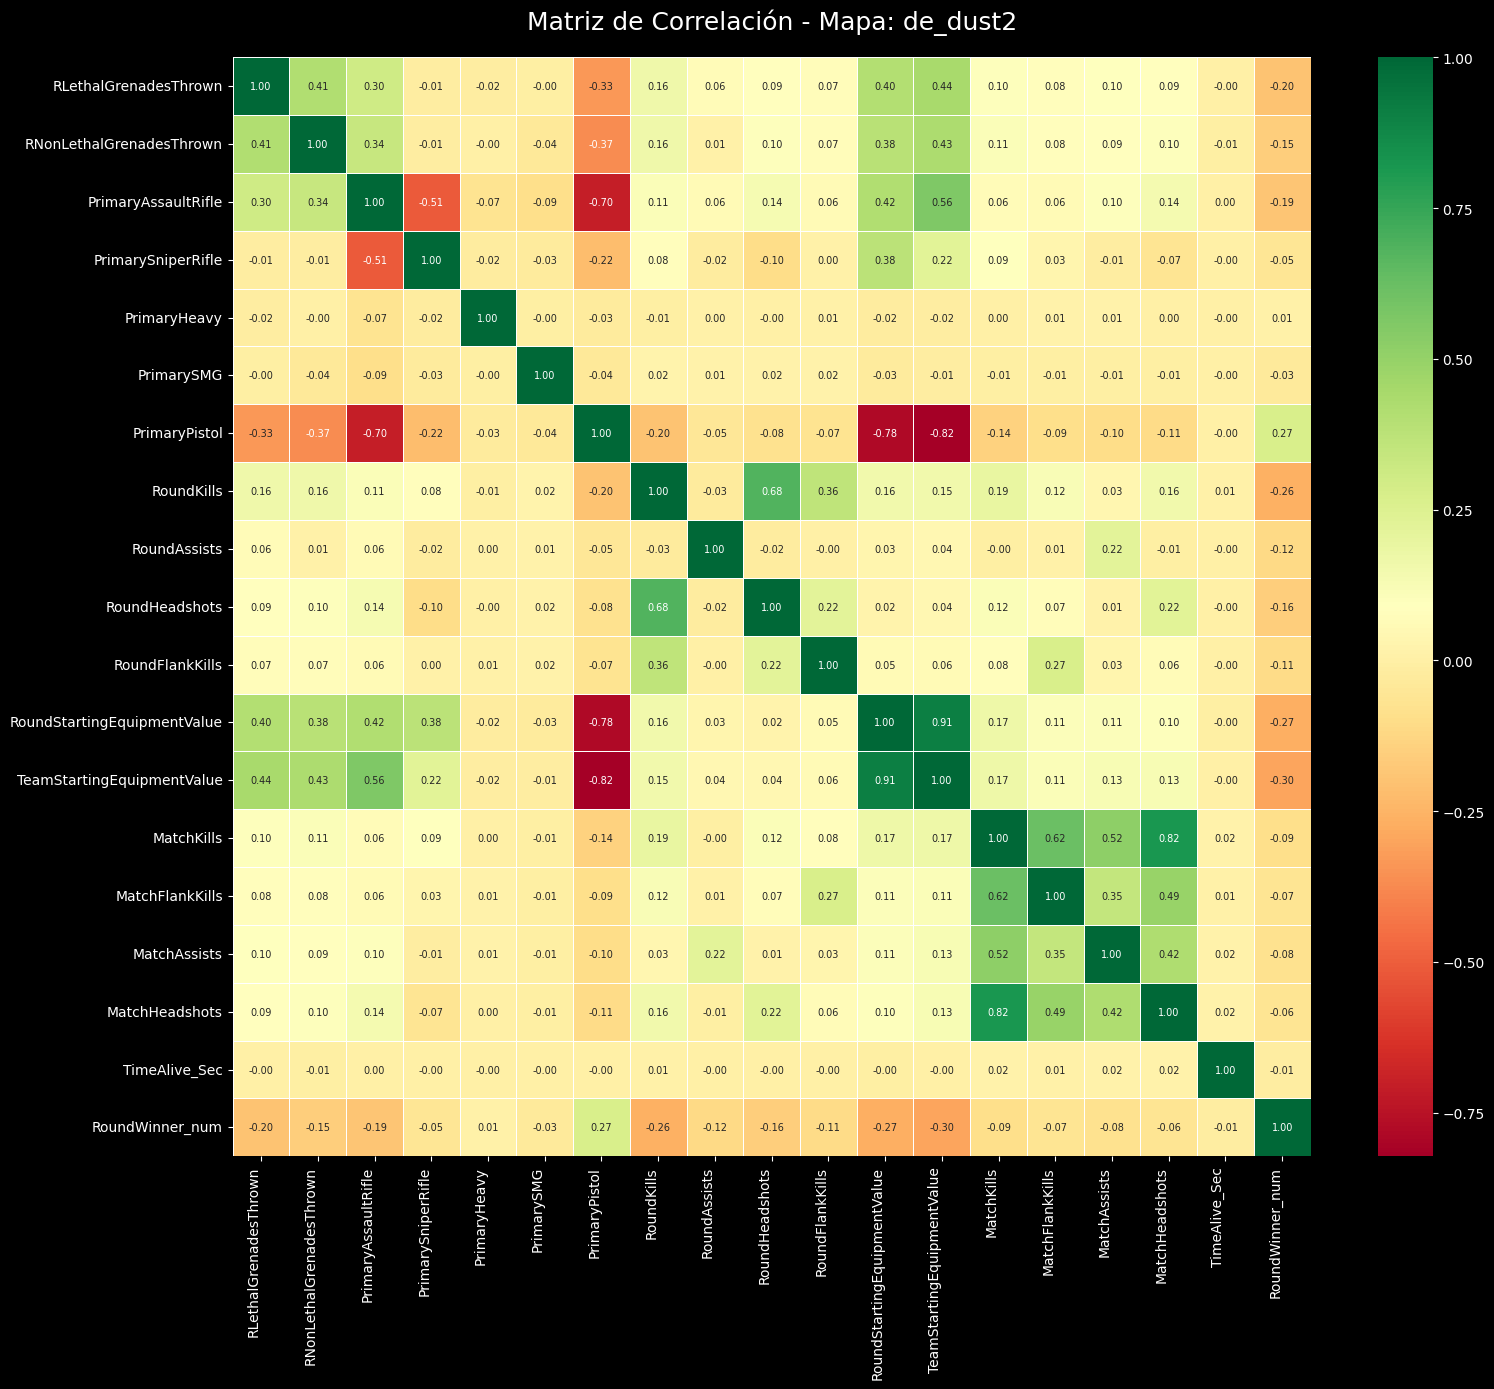

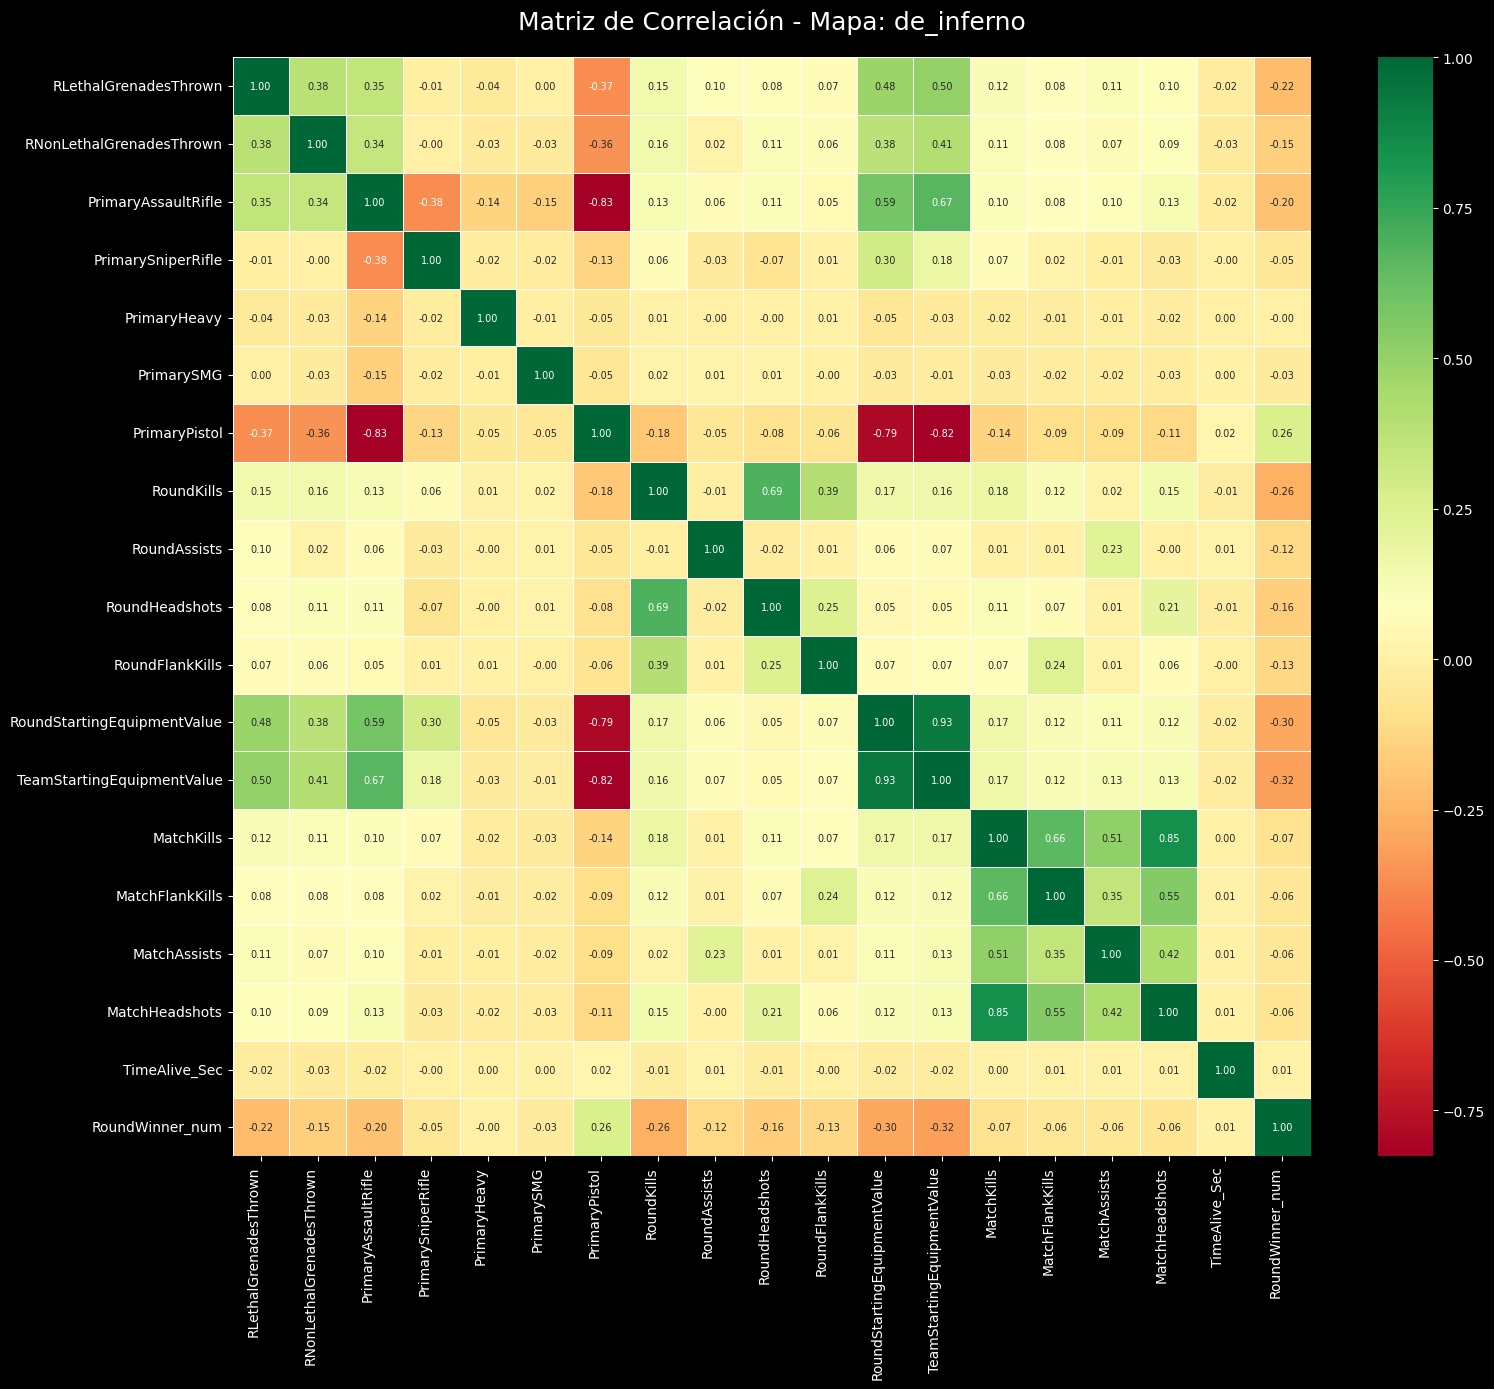

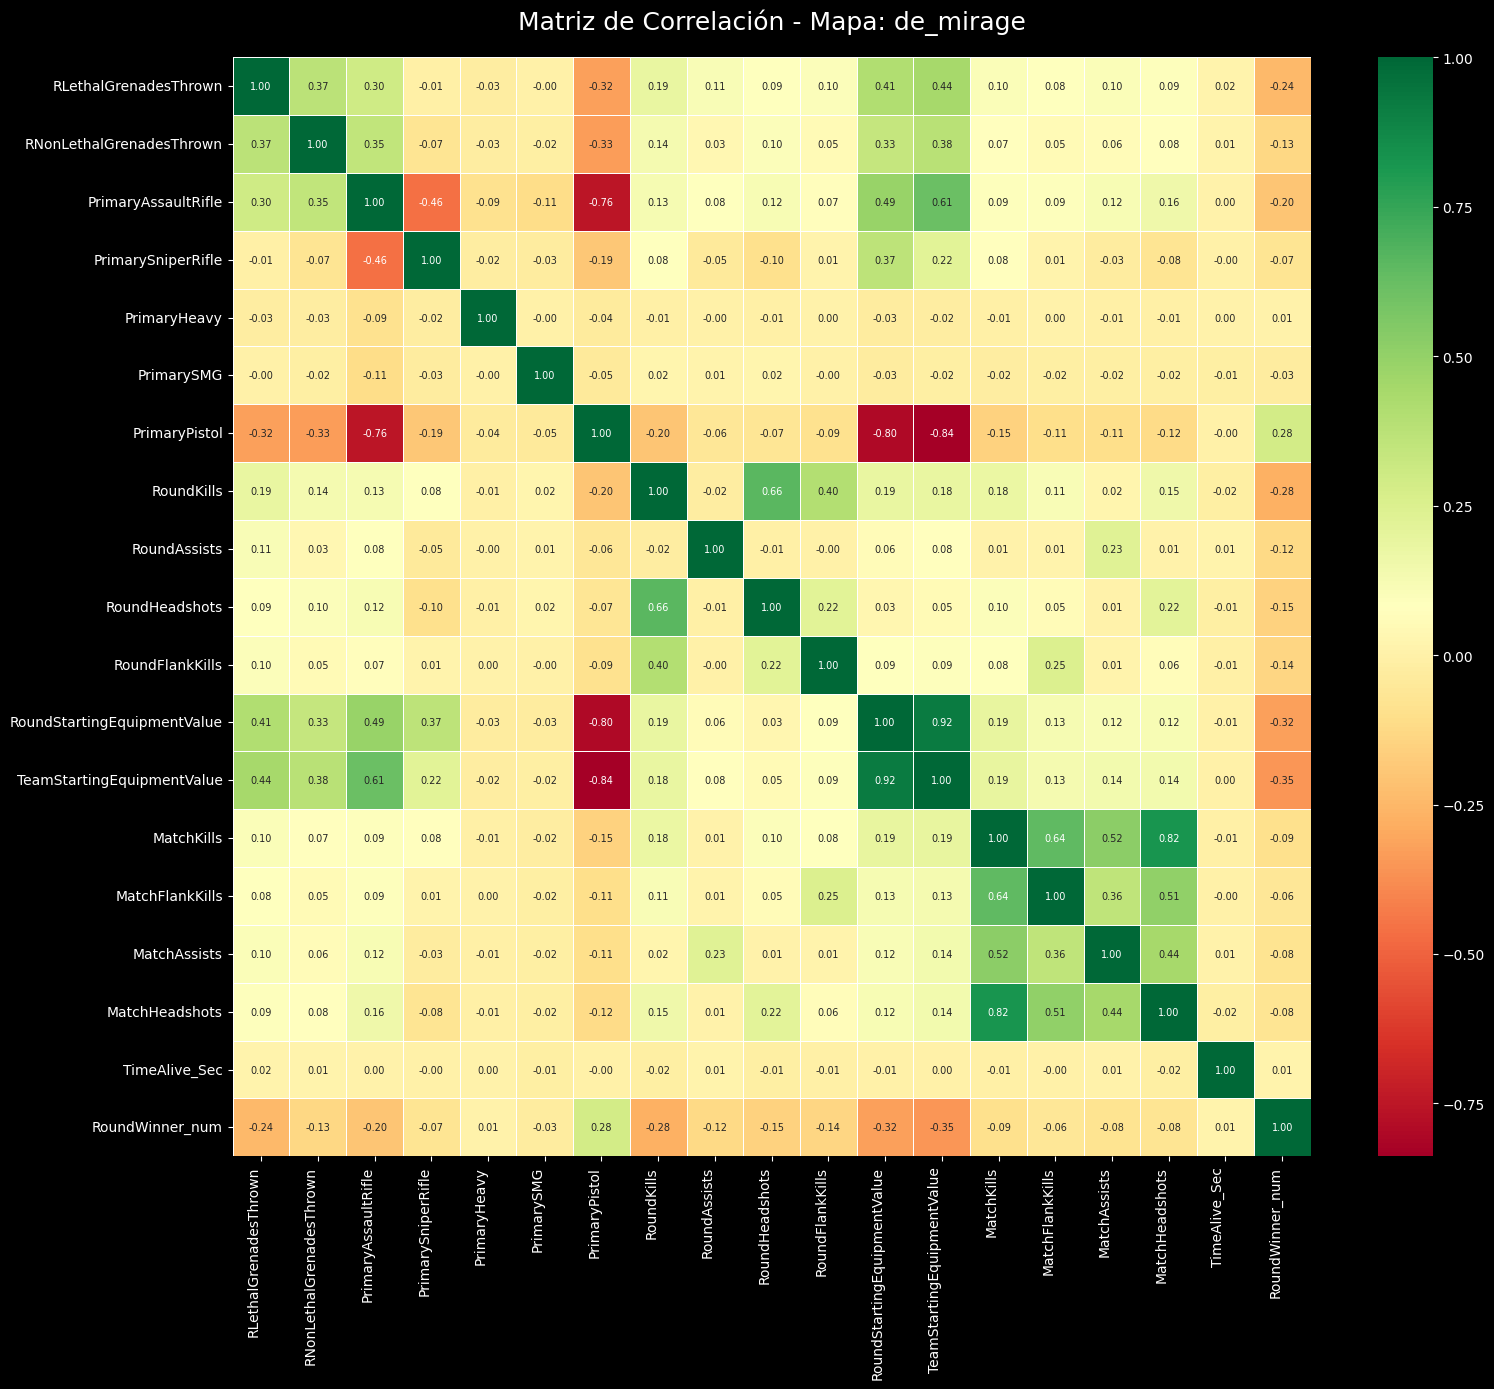

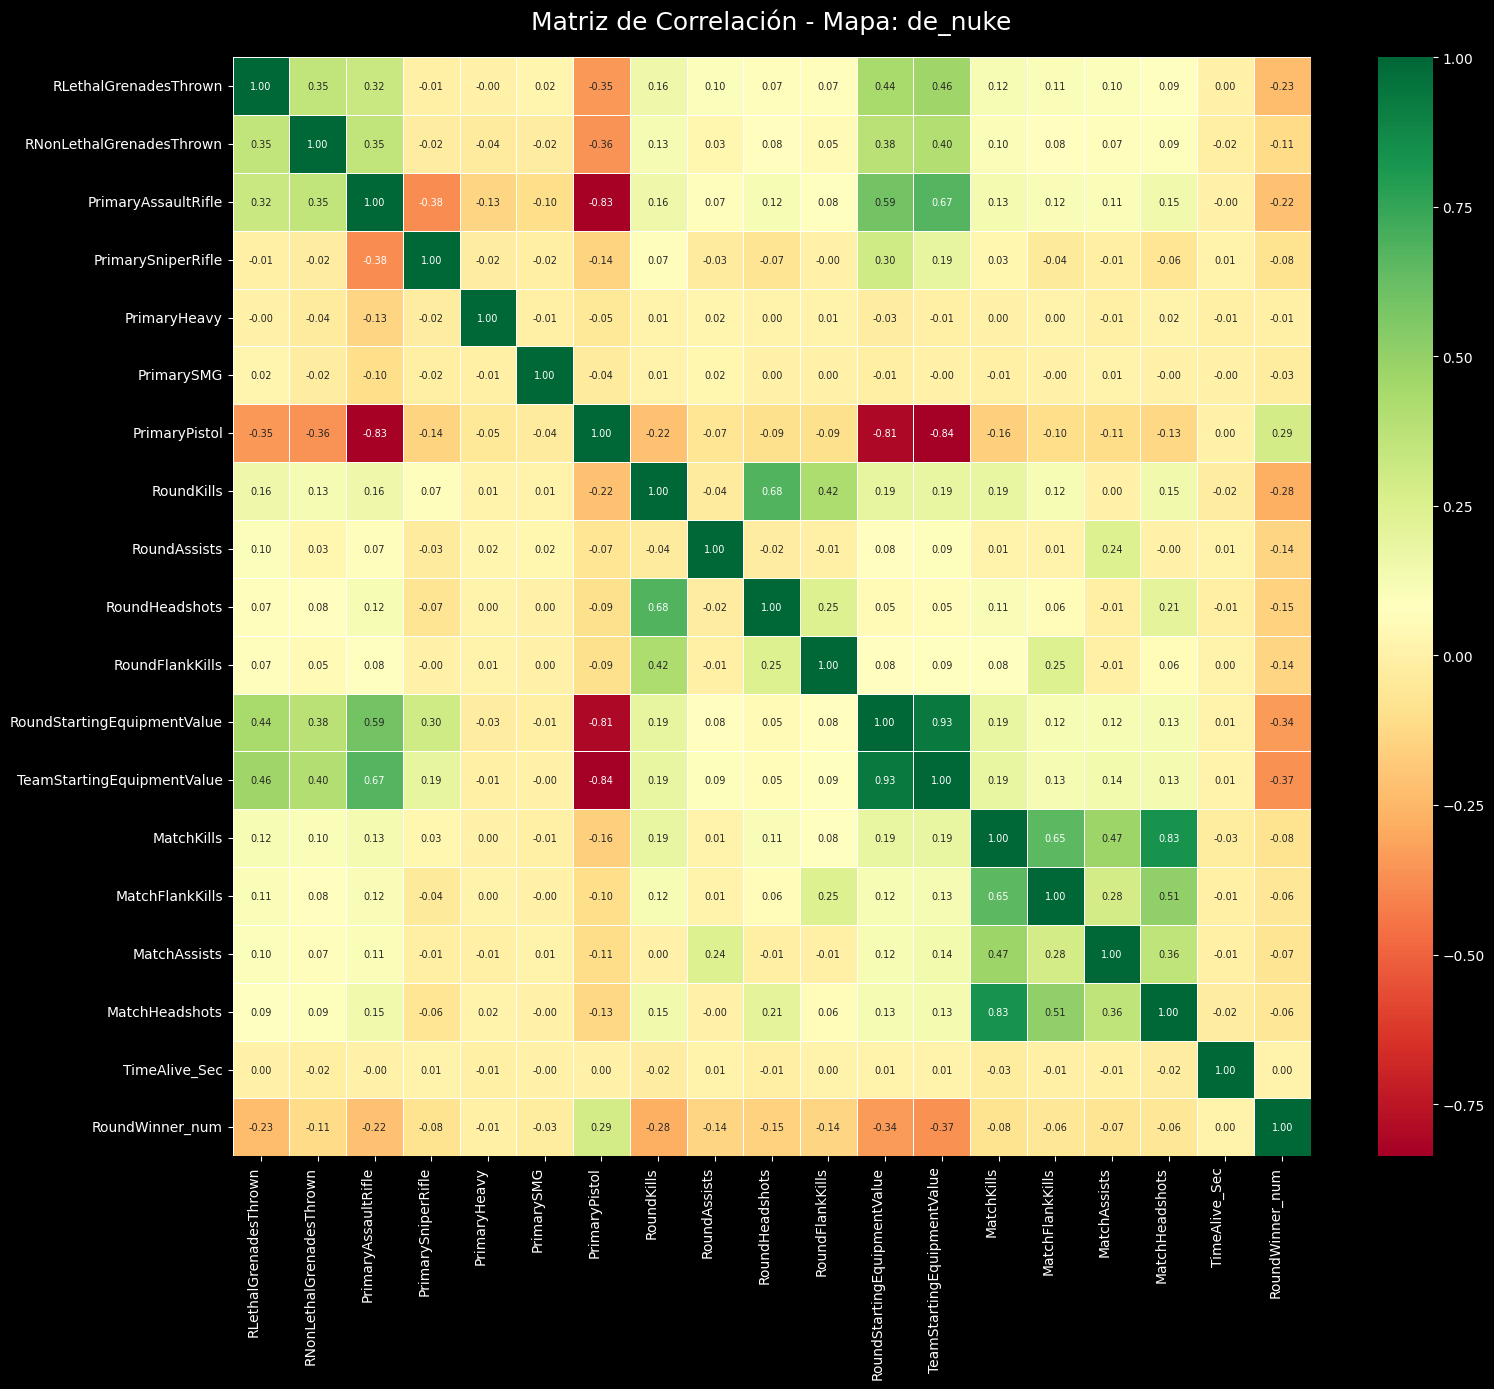

In [33]:
for mapa, df_mapa in df.groupby("Map"):

    numerical_df = df_mapa.select_dtypes(include=[np.number])

    if numerical_df.shape[1] < 2:
        continue

    corr_matrix = numerical_df.corr()

    plt.figure(figsize=(16, 14))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='RdYlGn',
        fmt='.2f',
        linewidths=0.5,
        annot_kws={"size": 7}
    )

    plt.title(f'Matriz de Correlación - Mapa: {mapa}', size=18, pad=20)
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

**Análisis de la Matriz de Correlación por mapa**

El análisis de las matrices de correlación por mapa permite identificar patrones consistentes en la relación entre variables, así como diferencias en la intensidad de estas relaciones según el contexto.

* **Variables identificadoras:** Las variables `MatchId`, `InternalTeamId` y `Unnamed`, no presentan correlaciones relevantes con otras variables del dataset, dado su carácter técnico, se recomienda excluirlas del modelado, ya que no aportan capacidad explicativa.

* **Estructura económica:** Se observa una correlación alta (≥0.90) entre `RoundStartingEquipmentValue` y `TeamStartingEquipmentValue` en todos los mapas, esta relación indica redundancia entre ambas variables, por lo que su uso conjunto podría generar problemas de multicolinealidad, en este contexto, se recomienda seleccionar solo una de ellas para representar la dimensión económica.

* **Patrones de armamento:** La correlación negativa entre `PrimaryPistol` y `PrimaryAssaultRifle` confirma la existencia de patrones de compra excluyentes, asociados a distintos estados económicos del equipo, esto refuerza la idea de que el tipo de arma puede actuar como un proxy del estado económico.

* Métricas de desempeño: Las variables de desempeño individual, como `RoundKills`, `MatchKills`, `RoundHeadshots` y `MatchHeadshots`, presentan correlaciones positivas entre sí, lo que indica que capturan dimensiones relacionadas del rendimiento del jugador, sin embargo, esta relación también sugiere posible redundancia parcial, por lo que su inclusión en el modelo debe evaluarse cuidadosamente.

* **Uso de utilidad táctica:** El uso de granadas (letales y no letales) muestra correlaciones moderadas con variables económicas, lo que indica que su utilización está condicionada por la disponibilidad de recursos, asimismo, estas variables pueden reflejar aspectos tácticos del juego, aunque su impacto directo debe analizarse en conjunto con otras características.

En conclusión, las matrices de correlación evidencian una estructura coherente entre economía, armamento y desempeño, donde la economía condiciona la selección de recursos y estas decisiones impactan en el rendimiento dentro de la ronda, desde la perspectiva del modelado, estos resultados permiten definir criterios claros de selección de variables:

* Eliminación de variables sin valor explicativo
* Reducción de variables altamente correlacionadas
* Priorización de variables representativas de cada dimensión (economía, desempeño y contexto)

Esto contribuye a construir un modelo más eficiente, reduciendo redundancia y mejorando su capacidad de generalización.

#### 2.6.2 Visualizaciones adicionales


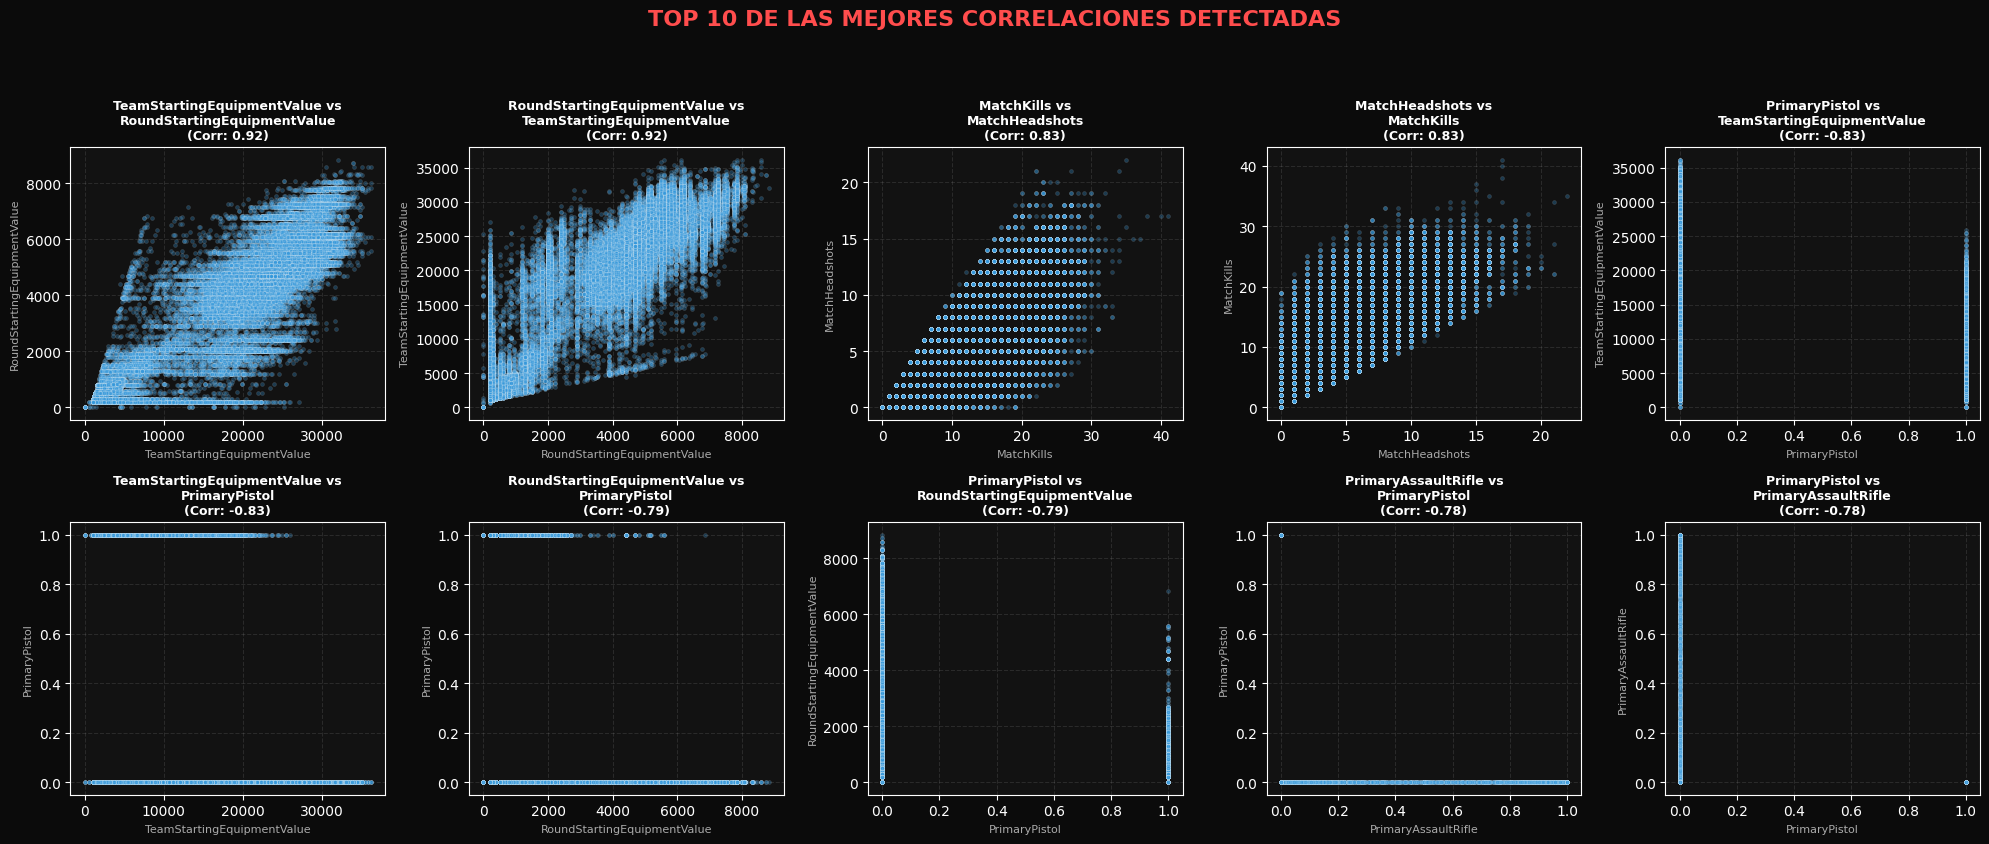

In [34]:
# 1. Calcular matriz de correlación general
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# 2. Obtener los pares con mayor correlación absoluta
# Desapilamos y ordenamos por valor absoluto para encontrar las 'mejores'
corr_pairs = corr_matrix.unstack()
df_corr = corr_pairs.to_frame('Correlation').reset_index()
df_corr.columns = ['Variable1', 'Variable2', 'Correlation']

# Filtrar correlaciones perfectas (1.0) y duplicados (A-B vs B-A)
df_corr = df_corr[df_corr['Variable1'] != df_corr['Variable2']]
df_corr['abs_correlation'] = df_corr['Correlation'].abs()

# Seleccionar el TOP 10 de las mejores correlaciones (las más fuertes)
df_better_corr = df_corr.sort_values(by='abs_correlation', ascending=False).head(10)

# 3. Graficar en matriz de 5 columnas
plt.style.use('dark_background')
n = len(df_better_corr)
cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), facecolor='#0b0b0b')
axes = axes.flatten()

for i, row in enumerate(df_better_corr.itertuples(index=False)):
    x_var = row.Variable1
    y_var = row.Variable2

    sns.scatterplot(data=df, x=x_var, y=y_var, alpha=0.3, ax=axes[i], color='#3498db', s=8)
    axes[i].set_facecolor('#121212')
    axes[i].set_title(f'{x_var} vs\n{y_var}\n(Corr: {row.Correlation:.2f})', fontsize=9, fontweight='bold', color='white')
    axes[i].set_xlabel(x_var, fontsize=8, color='#aaaaaa')
    axes[i].set_ylabel(y_var, fontsize=8, color='#aaaaaa')
    axes[i].grid(True, linestyle='--', alpha=0.1)

# Eliminar ejes sobrantes si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('TOP 10 DE LAS MEJORES CORRELACIONES DETECTADAS', fontsize=16, weight="bold", color='#ff4d4d', y=1.05)
plt.tight_layout()
plt.show()

**Análisis de gráficos de dispersión (Top 10 Correlaciones Detectadas)**

El análisis de las relaciones con mayor coeficiente de correlación permite identificar dependencias estructurales entre variables y su impacto en el modelado.

* **Relación entre variables económicas**: La relación entre `RoundStartingEquipmentValue` y `TeamStartingEquipmentValue` presenta una correlación de aproximadamente **0.92**, indicando una fuerte sincronización en las decisiones de compra dentro del equipo, esto evidencia redundancia entre ambas variables y sugiere la necesidad de seleccionar solo una para evitar multicolinealidad.

* **Relación inversa entre pistolas y equipamiento:** Se observa una correlación negativa fuerte (-0.83) entre el uso de `PrimaryPistol` y el valor del equipamiento, reflejando distintos estados económicos del equipo, esto indica que el tipo de arma puede actuar como un indicador indirecto del nivel de inversión.

* **Relación entre economía y armamento principal**: A medida que aumenta el valor del equipamiento, se incrementa la presencia de rifles de asalto (0.63), lo que sugiere que estas armas están asociadas a escenarios de mayor inversión, esto refuerza su rol como indicador del estado económico del equipo.

* **Relación entre métricas de desempeño**: Variables como `MatchKills` y `MatchHeadshots` presentan una correlación positiva alta (0.83), lo que indica que ambas capturan aspectos relacionados del rendimiento del jugador, esta relación sugiere posible redundancia parcial, por lo que su inclusión debe evaluarse en función del modelo.

* **Relación entre economía y supervivencia**: Se observa una tendencia donde mayores niveles de equipamiento se asocian con un incremento en `TimeAlive`, lo que sugiere que la disponibilidad de recursos puede influir en la duración de la participación en la ronda.

En conclusión, estos análisis confirman la existencia de relaciones estructurales entre variables económicas, de armamento y de desempeño. Desde la perspectiva del modelado, estos resultados permiten:

* Identificar y reducir multicolinealidad
* Seleccionar variables representativas de cada dimensión
* Evitar redundancia en variables altamente correlacionada.

Esto contribuye a construir un modelo más eficiente, robusto y con mejor capacidad de generalización.

### Conclusión fase 2 (Data understanding)

En la Etapa 2 se realizo un analisis exploratorio exhaustivo con el objetivo de identificar variables predictoras relevantes para dos problemas de aprendizaje automatico diferenciados: **clasificacion**, mediante la variable objetivo *RoundWinner*, y **regresion**, mediante una variable continua derivada del tiempo de supervivencia del equipo.

Para el problema de **clasificacion**, se analizaron las relaciones entre las variables independientes y el resultado binario de la ronda a traves de analisis de frecuencias, comparacion de distribuciones y segmentacion por categorias. Este enfoque permitio evidenciar que variables como `Team` y `Map` presentan patrones diferenciados en la proporcion de rondas ganadas, lo que indica una dependencia clara entre el contexto del juego y la probabilidad de victoria.

En el caso del problema de **regresion**, la exploracion mostro que variables como `TimeAlive`, `TeamStartingEquipmentValue`, `RoundStartingEquipmentValue` y variables de composicion tactica tienen sentido analitico para explicar desempeno. Por eso, en Fase 3 se decide construir `AvgTeamTimeAliveSec`, que resume el promedio de segundos de supervivencia del equipo por ronda. Esta decision deja un target continuo, mas defendible para modelos de regresion que un conteo discreto de kills.

A partir de estos hallazgos, se definieron los pasos futuros de tratamiento de datos: limpieza de nulos, tratamiento de outliers, codificacion de variables categoricas, escalamiento de numericas y separacion train/test. De esta manera, la Etapa 2 no solo permitio identificar variables con base empirica, sino que tambien sento las bases metodologicas para la preparacion y modelamiento posterior.

## Fase 3: Data Preparation


Esta fase se puede leer como un flujo de preparacion para que el dataset quede listo para modelado. La idea no es aplicar transformaciones al azar, sino conectar cada paso con el objetivo del proyecto.

| Paso | Que se hace | Por que importa |
| :--- | :--- | :--- |
| 3.1 | Se crea una copia de trabajo y se declaran los objetivos. | Protege el dataset original y separa clasificacion de regresion. |
| 3.2 | Se limpia `RoundWinner`, se revisan nulos y se exigen equipos-ronda completos. | Deja una variable objetivo confiable y grupos comparables. |
| 3.3 | Se agregan datos desde jugador-ronda hacia equipo-ronda. | La decision de compra es de equipo, no de jugador aislado. |
| 3.4 | Se separan predictoras y targets. | Evita que la respuesta se mezcle con las variables de entrada. |
| 3.5 | Se define imputacion, capping, encoding y escalamiento. | Trata nulos, outliers, texto y escalas distintas de forma ordenada. |
| 3.6 | Se divide train/test y se valida estructura final. | Permite evaluar modelos con datos no vistos y sin fuga de informacion. |
| 3.7 | Se comparan correlaciones antes y despues. | Verifica que el tratamiento no distorsione fuertemente las relaciones. |

Las variables objetivo son `RoundWinner_Num` para clasificacion y `AvgTeamTimeAliveSec` para regresion. Las variables predictoras se agrupan en contexto, economia y tactica. Esta organizacion permite que un lector entienda no solo el codigo, sino tambien el sentido de negocio de cada transformacion.



### 3.1 Preparacion operativa

En esta fase se usa directamente el dataframe `df` ya cargado. No se repite la exploracion del dataset; se toman las conclusiones de la Fase 2 y se convierten en transformaciones concretas para modelado.

El objetivo es generar datasets separados para dos tareas:

| Tarea | Variable objetivo | Tipo de problema | Que representa |
| :--- | :--- | :--- | :--- |
| Clasificacion | `RoundWinner_Num` | Clasificacion binaria | Si el equipo gana (`1`) o pierde (`0`) la ronda. |
| Regresion | `AvgTeamTimeAliveSec` | Regresion | Promedio de segundos de supervivencia del equipo en la ronda. |

Las variables predictoras se construyen desde tres grupos principales: contexto (`Map`, `Team`, `RoundId`), economia (`TeamStartingEquipmentValue`, `OpponentEquipmentValue`, ventajas economicas) y composicion tactica (`AssaultRifleShare`, `PistolShare`, ventajas de armas frente al rival). Esta separacion permite explicar no solo que variables entran al modelo, sino tambien que dimension del juego representa cada una.

In [35]:
df_prep = df.copy()

print(f"Dataset original: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Copia de trabajo df_prep: {df_prep.shape[0]} filas x {df_prep.shape[1]} columnas")

Dataset original: 79157 filas x 33 columnas
Copia de trabajo df_prep: 79157 filas x 33 columnas


**Analisis 3.1**

Se trabaja sobre una copia para proteger el dataframe original usado en las fases anteriores. Esto es importante porque en Data Preparation se corrigen categorias, se crean variables y se filtran registros; si todo se hiciera directamente sobre `df`, seria mas dificil comparar el antes y despues o volver atras ante una transformacion incorrecta.

En esta etapa tambien se deja claro que el proyecto tiene dos objetivos tecnicos. Para clasificacion, la variable objetivo es `RoundWinner_Num`, que responde a la pregunta mas importante del negocio: ganar o perder la ronda. Para regresion, la variable objetivo sera `AvgTeamTimeAliveSec`, que mide el promedio de segundos de supervivencia del equipo durante la ronda. Esta variable es mas adecuada para una tarea de regresion porque es numerica continua.

Las predictoras se eligen porque representan informacion estrategica del juego. `Map` y `Team` describen el contexto; `RoundId` representa el momento de la partida; las variables economicas miden capacidad de compra; y las variables de armas describen la configuracion tactica del equipo. Esta estructura hace que el dataset final sea interpretable y no una simple acumulacion de columnas.

### 3.2 Limpieza y normalización para modelado

Se normaliza el target de clasificación, se eliminan registros con campos críticos faltantes y se convierten a numéricas las variables que entrarán en las transformaciones. También se conservan solo equipos-ronda completos para que la agregación posterior sea consistente.



In [36]:
filas_antes_limpieza = len(df_prep)


def convertir_tiempo_segundos(valor):
    try:
        if pd.isna(valor) or valor == '':
            return np.nan
        texto = str(valor).strip()
        if ':' in texto:
            partes = texto.split(':')
            return int(partes[0]) * 60 + int(partes[1])
        if texto.count('.') > 1:
            texto = texto.split('.')[0]
        numero = float(texto)
        if numero > 1_000_000:
            numero = (numero / 1e9) % 115
        return min(max(numero, 0), 200)
    except Exception:
        return np.nan


if 'TimeAlive_Sec' not in df_prep.columns:
    df_prep['TimeAlive_Sec'] = df_prep['TimeAlive'].apply(convertir_tiempo_segundos)
else:
    df_prep['TimeAlive_Sec'] = pd.to_numeric(df_prep['TimeAlive_Sec'], errors='coerce')

df_prep['RoundWinner_Num'] = (
    df_prep['RoundWinner']
    .astype(str)
    .str.strip()
    .replace({'False4': 'False'})
    .str.lower()
    .map({'true': 1, 'false': 0})
)

cols_indice = ['MatchId', 'RoundId', 'Map', 'Team', 'RoundWinner_Num']
nulos_indice_antes = df_prep[cols_indice].isnull().sum()
cols_con_nulos = nulos_indice_antes[nulos_indice_antes > 0].index.tolist()

for col in cols_con_nulos:
    moda = df_prep[col].mode(dropna=True)[0]
    df_prep.loc[df_prep[col].isnull(), col] = moda

cols_numericas = [
    'RoundId',
    'RoundStartingEquipmentValue',
    'TeamStartingEquipmentValue',
    'RLethalGrenadesThrown',
    'RNonLethalGrenadesThrown',
    'PrimaryAssaultRifle',
    'PrimarySniperRifle',
    'PrimaryHeavy',
    'PrimarySMG',
    'PrimaryPistol',
    'RoundKills',
    'TimeAlive_Sec'
]

for col in cols_numericas:
    df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

df_prep['PlayersInTeamRound'] = (
    df_prep
    .groupby(['MatchId', 'RoundId', 'Team'], observed=True)['InternalTeamId']
    .transform('size')
)
df_prep = df_prep[df_prep['PlayersInTeamRound'].eq(5)].copy()
df_prep = df_prep.dropna(subset=['TimeAlive_Sec']).copy()

limpieza_resumen = pd.DataFrame({
    'Indicador': [
        'Filas antes de limpieza',
        'Filas despues de exigir equipos-ronda completos',
        'Filas removidas',
        'Nulos en columnas indice antes',
        'Nulos en columnas indice despues',
        'Nulos en TimeAlive_Sec despues'
    ],
    'Valor': [
        filas_antes_limpieza,
        len(df_prep),
        filas_antes_limpieza - len(df_prep),
        int(nulos_indice_antes.sum()),
        int(df_prep[cols_indice].isnull().sum().sum()),
        int(df_prep['TimeAlive_Sec'].isnull().sum())
    ]
})

target_limpio = (
    df_prep['RoundWinner_Num']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename(index={0: 'Derrota', 1: 'Victoria'})
    .reset_index()
)
target_limpio.columns = ['Resultado', 'Porcentaje']

print('Resumen de limpieza:')
print(limpieza_resumen.to_string(index=False))
print('\nDistribucion de la variable objetivo RoundWinner_Num despues de limpieza:')
print(target_limpio.to_string(index=False))

Resumen de limpieza:
                                      Indicador  Valor
                        Filas antes de limpieza  79157
Filas despues de exigir equipos-ronda completos  79030
                                Filas removidas    127
                 Nulos en columnas indice antes      2
               Nulos en columnas indice despues      0
                 Nulos en TimeAlive_Sec despues      0

Distribucion de la variable objetivo RoundWinner_Num despues de limpieza:
Resultado  Porcentaje
  Derrota       50.02
 Victoria       49.98


**Analisis 3.2**

La limpieza deja la base en condiciones mas consistentes para construir variables de equipo. Se parte desde 79.157 filas y, al exigir equipos-ronda completos de 5 jugadores, se conservan 79.030 filas. La perdida es de 127 registros, una proporcion muy pequena del dataset, pero mejora la comparabilidad: cada equipo-ronda agregado representa el mismo tamano de equipo.

La variable objetivo de clasificacion, `RoundWinner_Num`, queda codificada como `1` para victoria y `0` para derrota. Este paso es central porque convierte una categoria textual en una variable numerica que los modelos pueden aprender. Ademas, se corrige `False4` como `False`, evitando que un error de tipeo cree una tercera clase falsa.

En los nulos de columnas de indice o categoricas se usa la **moda**, no la mediana, porque variables como `Team` o `Map` son texto y no tienen centro numerico. La imputacion por mediana se reserva para las variables numericas y se aplicara dentro del pipeline, despues de separar train/test. Esto es una buena practica porque evita que la informacion del conjunto de prueba influya en los valores usados para imputar.

El balance de `RoundWinner_Num` queda practicamente 50/50. Esto es favorable para clasificacion, porque el modelo no queda sesgado hacia una clase dominante. En otras palabras, el algoritmo tendra ejemplos suficientes tanto de victorias como de derrotas.



### 3.3 Construcción de variables finales

Se transforma la unidad de análisis a equipo-ronda. Las variables individuales se agregan a nivel de equipo y se crean variables derivadas de economía, armas, utilidad e información relativa al rival.


In [37]:
team_round = (
    df_prep
    .groupby(['MatchId', 'RoundId', 'Map', 'Team'], observed=True)
    .agg(
        RoundWinner_Num=('RoundWinner_Num', 'first'),
        TeamStartingEquipmentValue=('TeamStartingEquipmentValue', 'median'),
        AvgPlayerEquipmentValue=('RoundStartingEquipmentValue', 'mean'),
        MinPlayerEquipmentValue=('RoundStartingEquipmentValue', 'min'),
        MaxPlayerEquipmentValue=('RoundStartingEquipmentValue', 'max'),
        TotalLethalGrenadesThrown=('RLethalGrenadesThrown', 'sum'),
        TotalNonLethalGrenadesThrown=('RNonLethalGrenadesThrown', 'sum'),
        AssaultRifleShare=('PrimaryAssaultRifle', 'mean'),
        SniperRifleShare=('PrimarySniperRifle', 'mean'),
        HeavyShare=('PrimaryHeavy', 'mean'),
        SMGShare=('PrimarySMG', 'mean'),
        PistolShare=('PrimaryPistol', 'mean'),
        TeamRoundKills=('RoundKills', 'sum'),
        AvgTeamTimeAliveSec=('TimeAlive_Sec', 'mean')
    )
    .reset_index()
)

team_round['EquipmentSpread'] = (
    team_round['MaxPlayerEquipmentValue'] - team_round['MinPlayerEquipmentValue']
)
team_round['InvestmentLevel'] = pd.cut(
    team_round['TeamStartingEquipmentValue'],
    bins=[-np.inf, 11000, 22000, np.inf],
    labels=['Baja inversion', 'Inversion media', 'Compra alta']
)

opponent_features = team_round[[
    'MatchId', 'RoundId', 'Map', 'Team', 'TeamStartingEquipmentValue', 'AssaultRifleShare', 'PistolShare'
]].rename(columns={
    'Team': 'OpponentTeam',
    'TeamStartingEquipmentValue': 'OpponentEquipmentValue',
    'AssaultRifleShare': 'OpponentAssaultRifleShare',
    'PistolShare': 'OpponentPistolShare'
})

team_round = team_round.merge(opponent_features, on=['MatchId', 'RoundId', 'Map'], how='left')
team_round = team_round[team_round['Team'] != team_round['OpponentTeam']].copy()

team_round['EquipmentAdvantage'] = (
    team_round['TeamStartingEquipmentValue'] - team_round['OpponentEquipmentValue']
)

team_round['LogEquipmentRatio'] = (
    np.log1p(team_round['TeamStartingEquipmentValue'])
    - np.log1p(team_round['OpponentEquipmentValue'])
)

team_round['RifleAdvantage'] = (
    team_round['AssaultRifleShare'] - team_round['OpponentAssaultRifleShare']
)

team_round['PistolDisadvantage'] = (
    team_round['PistolShare'] - team_round['OpponentPistolShare']
)

target_variation = (
    df_prep
    .groupby(['MatchId', 'RoundId', 'Map', 'Team'], observed=True)['RoundWinner_Num']
    .nunique()
)

investment_behavior = (
    team_round
    .groupby('InvestmentLevel', observed=True)
    .agg(
        Rondas=('RoundWinner_Num', 'size'),
        Winrate_pct=('RoundWinner_Num', lambda x: x.mean() * 100),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Equipamiento_mediana=('TeamStartingEquipmentValue', 'median'),
        Supervivencia_promedio_seg=('AvgTeamTimeAliveSec', 'mean')
    )
    .round(2)
    .reset_index()
)

team_behavior = (
    team_round
    .groupby('Team', observed=True)
    .agg(
        Rondas=('RoundWinner_Num', 'size'),
        Winrate_pct=('RoundWinner_Num', lambda x: x.mean() * 100),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Ventaja_economica_promedio=('EquipmentAdvantage', 'mean'),
        PistolShare_promedio=('PistolShare', 'mean'),
        AssaultRifleShare_promedio=('AssaultRifleShare', 'mean'),
        Supervivencia_promedio_seg=('AvgTeamTimeAliveSec', 'mean')
    )
    .round(2)
    .reset_index()
)

result_behavior = (
    team_round
    .groupby('RoundWinner_Num', observed=True)
    .agg(
        Rondas=('RoundWinner_Num', 'size'),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Equipamiento_rival_promedio=('OpponentEquipmentValue', 'mean'),
        Ventaja_economica_promedio=('EquipmentAdvantage', 'mean'),
        PistolShare_promedio=('PistolShare', 'mean'),
        AssaultRifleShare_promedio=('AssaultRifleShare', 'mean'),
        Supervivencia_promedio_seg=('AvgTeamTimeAliveSec', 'mean'),
        Kills_equipo_promedio=('TeamRoundKills', 'mean')
    )
    .round(2)
    .rename(index={0: 'Derrota', 1: 'Victoria'})
    .reset_index()
)

print(f"Dataset equipo-ronda: {team_round.shape[0]} filas x {team_round.shape[1]} columnas")
print(f"Maximo de valores distintos de RoundWinner_Num dentro de un grupo: {target_variation.max()}")
print('\nComportamiento por nivel de inversion:')
print(investment_behavior.to_string(index=False))
print('\nComportamiento por bando:')
print(team_behavior.to_string(index=False))
print('\nComportamiento promedio segun resultado de la ronda:')
print(result_behavior.to_string(index=False))


Dataset equipo-ronda: 15804 filas x 28 columnas
Maximo de valores distintos de RoundWinner_Num dentro de un grupo: 2

Comportamiento por nivel de inversion:
InvestmentLevel  Rondas  Winrate_pct  Equipamiento_promedio  Equipamiento_mediana  Supervivencia_promedio_seg
 Baja inversion    3944        75.28                3416.54                3000.0                       30.57
Inversion media    3499        47.53               18860.63               19450.0                       29.69
    Compra alta    8361        39.11               26230.96               25850.0                       29.79

Comportamiento por bando:
            Team  Rondas  Winrate_pct  Equipamiento_promedio  Ventaja_economica_promedio  PistolShare_promedio  AssaultRifleShare_promedio  Supervivencia_promedio_seg
CounterTerrorist    7902        42.34               20884.41                     3957.47                  0.20                        0.67                       30.48
       Terrorist    7902        57.66     

**Analisis 3.3**

La agregacion convierte la base desde jugador-ronda hacia equipo-ronda. Este cambio es clave porque las decisiones que se quieren analizar no son individuales, sino colectivas: cuanto invierte el equipo, que armas compra, que ventaja tiene frente al rival y si finalmente gana o pierde la ronda.

El dataset queda con 15.804 equipos-ronda. En esta unidad, `RoundWinner_Num` sigue siendo la variable objetivo de clasificacion, mientras que `AvgTeamTimeAliveSec` queda como objetivo de regresion. Las predictoras ya no describen a un jugador aislado, sino al equipo completo: `TeamStartingEquipmentValue` resume la economia del equipo, `AssaultRifleShare` indica proporcion de jugadores con rifle, `PistolShare` indica dependencia de pistolas y `EquipmentAdvantage` compara la inversion propia contra la del rival.

El comportamiento por nivel de inversion muestra un patron que no debe interpretarse de forma superficial. En el dataset, las rondas de **baja inversion** tienen un winrate cercano a 75,28%, las de **inversion media** cerca de 47,53% y las de **compra alta** cerca de 39,11%. Esto no significa que comprar menos siempre sea mejor; indica que la variable economica esta mezclada con el contexto del bando, el momento de la partida y la economia del rival. Por eso se crean variables comparativas como `OpponentEquipmentValue`, `EquipmentAdvantage` y `LogEquipmentRatio`: el valor absoluto de la compra no basta, importa contra que compra rival se esta compitiendo.

Tambien se observa diferencia por bando. `Terrorist` tiene un winrate aproximado de 57,66%, mientras que `CounterTerrorist` alcanza cerca de 42,34%. Esto ocurre aun cuando `CounterTerrorist` presenta mayor equipamiento promedio. Este comportamiento refuerza que `Team` es una predictora importante: el bando captura diferencias tacticas que la economia por si sola no explica.

Las variables de armamento ayudan a leer la estrategia. Un `PistolShare` alto representa equipos con mayor presencia de pistolas, usualmente asociado a rondas eco o compras limitadas. Un `AssaultRifleShare` alto representa compras mas fuertes o rondas armadas. Las variables `RifleAdvantage` y `PistolDisadvantage` comparan esa composicion contra el rival, lo que entrega una lectura mas rica que mirar solo el armamento propio.

Nota metodologica: las variables de granadas lanzadas (`TotalLethalGrenadesThrown` y `TotalNonLethalGrenadesThrown`) describen ejecucion tactica durante la ronda. Si el modelo se define estrictamente como prediccion antes de iniciar la ronda, convendria excluirlas para evitar fuga temporal. Si el objetivo es explicar resultado o modelar con informacion temprana de desarrollo, pueden mantenerse como variables tacticas.



### 3.4 Separación de features y targets

Se definen las variables predictoras finales y se separan los targets. `RoundWinner_Num` se usa para clasificación y `AvgTeamTimeAliveSec` para regresión. Se evita usar como predictor cualquier variable que represente directamente el resultado o que ocurra durante/después de la ronda.

In [38]:
numeric_features = [
    'RoundId',
    'TeamStartingEquipmentValue',
    'OpponentEquipmentValue',
    'EquipmentAdvantage',
    'LogEquipmentRatio',
    'EquipmentSpread',
    'AssaultRifleShare',
    'SniperRifleShare',
    'HeavyShare',
    'SMGShare',
    'PistolShare',
    'RifleAdvantage',
    'PistolDisadvantage'
]

categorical_features = ['Map', 'Team', 'InvestmentLevel']
final_features = categorical_features + numeric_features

model_data = team_round.copy()
model_data[numeric_features] = model_data[numeric_features].replace([np.inf, -np.inf], np.nan)
model_data['RoundWinner_Num'] = pd.to_numeric(model_data['RoundWinner_Num'], errors='coerce')
model_data['AvgTeamTimeAliveSec'] = pd.to_numeric(model_data['AvgTeamTimeAliveSec'], errors='coerce')
model_data = model_data.dropna(subset=['RoundWinner_Num', 'AvgTeamTimeAliveSec']).copy()

X = model_data[final_features].copy()
y_clf = model_data['RoundWinner_Num'].astype('int64')
y_reg = model_data['AvgTeamTimeAliveSec'].copy()

features_summary = pd.DataFrame({
    'Grupo': ['Categoricas', 'Numericas', 'Total predictoras antes de encoding'],
    'Cantidad': [len(categorical_features), len(numeric_features), len(final_features)]
})

target_summary = pd.DataFrame({
    'Target': ['RoundWinner_Num', 'AvgTeamTimeAliveSec'],
    'Tipo de problema': ['Clasificacion binaria', 'Regresion'],
    'Lectura': [
        '1 = victoria, 0 = derrota',
        'Promedio de segundos de supervivencia del equipo en la ronda'
    ],
    'Media': [round(y_clf.mean(), 3), round(y_reg.mean(), 3)],
    'Mediana': [round(y_clf.median(), 3), round(y_reg.median(), 3)],
    'Minimo': [round(y_clf.min(), 3), round(y_reg.min(), 3)],
    'Maximo': [round(y_clf.max(), 3), round(y_reg.max(), 3)]
})

print('Resumen de features seleccionadas:')
print(features_summary.to_string(index=False))
print('\nResumen de variables objetivo:')
print(target_summary.to_string(index=False))
print('\nVariables categoricas:')
print(categorical_features)
print('\nVariables numericas:')
print(numeric_features)

Resumen de features seleccionadas:
                              Grupo  Cantidad
                        Categoricas         3
                          Numericas        13
Total predictoras antes de encoding        16

Resumen de variables objetivo:
             Target      Tipo de problema                                                      Lectura  Media  Mediana  Minimo  Maximo
    RoundWinner_Num Clasificacion binaria                                    1 = victoria, 0 = derrota  0.500      0.5     0.0     1.0
AvgTeamTimeAliveSec             Regresion Promedio de segundos de supervivencia del equipo en la ronda 29.965     15.2     0.0   200.0

Variables categoricas:
['Map', 'Team', 'InvestmentLevel']

Variables numericas:
['RoundId', 'TeamStartingEquipmentValue', 'OpponentEquipmentValue', 'EquipmentAdvantage', 'LogEquipmentRatio', 'EquipmentSpread', 'AssaultRifleShare', 'SniperRifleShare', 'HeavyShare', 'SMGShare', 'PistolShare', 'RifleAdvantage', 'PistolDisadvantage']


**Analisis 3.4**

En este paso se separan explicitamente las predictoras (`X`) y las variables objetivo (`y_clf`, `y_reg`). Esta separacion es importante porque evita que el target se mezcle con las variables de entrada. `RoundWinner_Num` queda reservado para clasificacion y `AvgTeamTimeAliveSec` queda reservado para regresion.

Las predictoras categoricas son `Map`, `Team` e `InvestmentLevel`. `Map` captura el escenario tactico; `Team` captura el bando y sus diferencias estrategicas; `InvestmentLevel` resume la economia en categorias interpretables: baja inversion, inversion media y compra alta. Estas variables necesitan encoding porque los modelos no trabajan directamente con texto.

Las predictoras numericas se dividen en varias familias. `RoundId` representa el momento de la partida; `TeamStartingEquipmentValue` y `OpponentEquipmentValue` representan la economia propia y rival; `EquipmentAdvantage` y `LogEquipmentRatio` representan ventaja relativa; `EquipmentSpread` mide desigualdad interna de compra dentro del equipo; y las variables de armas describen la composicion tactica.

Para regresion se usa `AvgTeamTimeAliveSec`, una variable continua. Se excluyen de las predictoras las granadas lanzadas, kills y supervivencia observada como variables explicativas directas, porque ocurren durante la ronda y podrian introducir fuga temporal si el objetivo es predecir antes o al inicio de la ronda.

### 3.5 Tratamiento, encoding y escalamiento

El preprocesamiento se define dentro de un pipeline. Las variables numéricas reciben imputación por mediana, tratamiento de outliers por IQR Capping y escalamiento con `RobustScaler`. Las variables categóricas reciben imputación por moda y `OneHotEncoder`.



In [39]:
class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.n_features_in_ = X_df.shape[1]
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr

        # Si IQR es 0, no se aplica capping para no convertir la variable en constante.
        zero_iqr = iqr.eq(0)
        self.lower_[zero_iqr] = -np.inf
        self.upper_[zero_iqr] = np.inf
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_capped = X_df.clip(lower=self.lower_, upper=self.upper_, axis=1)
        return X_capped.to_numpy()

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([f'x{i}' for i in range(self.n_features_in_)], dtype=object)
        return np.asarray(input_features, dtype=object)


def crear_preprocesador():
    return ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('iqr_capper', IQRCapper(factor=1.5)),
                    ('scaler', RobustScaler())
                ]),
                numeric_features
            ),
            (
                'cat',
                Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
                ]),
                categorical_features
            )
        ],
        verbose_feature_names_out=False
    )

preprocess_summary = pd.DataFrame({
    'Tipo de variable': ['Numericas', 'Categoricas'],
    'Tratamiento de nulos': ['Mediana', 'Moda'],
    'Outliers': ['IQR Capping antes de escalar', 'No aplica directamente'],
    'Transformacion final': ['RobustScaler', 'OneHotEncoder drop=first']
})

outlier_rows = []
for col in numeric_features:
    q1 = model_data[col].quantile(0.25)
    q3 = model_data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = int(((model_data[col] < lower) | (model_data[col] > upper)).sum())
    outlier_rows.append({
        'Variable': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Outliers IQR': outlier_count
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values('Outliers IQR', ascending=False)
    .head(8)
)

print('Resumen del preprocesamiento definido:')
print(preprocess_summary.to_string(index=False))
print('\nVariables con mas outliers por criterio IQR antes del tratamiento:')
print(outlier_summary.to_string(index=False))


Resumen del preprocesamiento definido:
Tipo de variable Tratamiento de nulos                     Outliers     Transformacion final
       Numericas              Mediana IQR Capping antes de escalar             RobustScaler
     Categoricas                 Moda       No aplica directamente OneHotEncoder drop=first

Variables con mas outliers por criterio IQR antes del tratamiento:
          Variable     Q1      Q3    IQR  Outliers IQR
PistolDisadvantage   0.00    0.00    0.0          6454
 LogEquipmentRatio  -0.35    0.35    0.7          4590
       PistolShare   0.00    0.20    0.2          3563
    RifleAdvantage  -0.20    0.20    0.4          3072
          SMGShare   0.00    0.00    0.0           505
        HeavyShare   0.00    0.00    0.0           466
   EquipmentSpread 500.00 2400.00 1900.0           319
  SniperRifleShare   0.00    0.20    0.2            89


**Analisis 3.5**

El tratamiento queda encapsulado en un `ColumnTransformer`, lo que permite aplicar reglas distintas segun el tipo de variable. Esto es mejor que transformar todo igual, porque una variable numerica y una categorica no tienen la misma naturaleza.

Para las variables numericas se usa una secuencia de tres pasos. Primero, `SimpleImputer(strategy='median')` reemplaza nulos por la mediana. La mediana es adecuada porque las variables economicas y tacticas tienen valores extremos; usar la media podria desplazar el centro por rondas muy particulares. Segundo, `IQRCapper` limita valores extremos usando el rango intercuartilico. Tercero, `RobustScaler` escala usando mediana e IQR, por lo que mantiene estabilidad frente a outliers.

Para las variables categoricas se usa imputacion por moda y luego `OneHotEncoder`. La moda es apropiada para texto porque no existe mediana en categorias como `Map` o `Team`. El encoding convierte cada categoria en columnas binarias; por ejemplo, el bando `Team` se transforma en una columna como `Team_Terrorist`. Asi el modelo puede usar informacion categorica sin asumir un orden falso.

`RobustScaler` si es razonable en este caso. Las variables `TeamStartingEquipmentValue`, `OpponentEquipmentValue` y `EquipmentAdvantage` tienen rangos amplios: la ventaja economica va aproximadamente desde -32.000 hasta 32.000. Un escalador basado en media y desviacion estandar podria quedar dominado por extremos; con `RobustScaler`, el modelo recibe variables centradas de forma mas estable. Para modelos basados en arboles el escalamiento importa menos, pero para modelos lineales, KNN, SVM o redes simples es una preparacion mucho mas conveniente.


### 3.6 División train/test y validación final

Se realiza la división train/test y se ajusta el preprocesamiento solo con train. La validación final comprueba que los datasets transformados no tengan nulos y mantengan la misma estructura de columnas.



In [40]:
X_train_clf_raw, X_test_clf_raw, y_train_clf, y_test_clf = train_test_split(
    X, y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

preprocessor_clf = crear_preprocesador()
X_train_clf = pd.DataFrame(
    preprocessor_clf.fit_transform(X_train_clf_raw),
    columns=preprocessor_clf.get_feature_names_out(),
    index=X_train_clf_raw.index
)
X_test_clf = pd.DataFrame(
    preprocessor_clf.transform(X_test_clf_raw),
    columns=preprocessor_clf.get_feature_names_out(),
    index=X_test_clf_raw.index
)

X_train_reg_raw, X_test_reg_raw, y_train_reg, y_test_reg = train_test_split(
    X, y_reg,
    test_size=0.20,
    random_state=42
)

preprocessor_reg = crear_preprocesador()
X_train_reg = pd.DataFrame(
    preprocessor_reg.fit_transform(X_train_reg_raw),
    columns=preprocessor_reg.get_feature_names_out(),
    index=X_train_reg_raw.index
)
X_test_reg = pd.DataFrame(
    preprocessor_reg.transform(X_test_reg_raw),
    columns=preprocessor_reg.get_feature_names_out(),
    index=X_test_reg_raw.index
)

validacion_final = pd.DataFrame({
    'Dataset': ['X_train_clf', 'X_test_clf', 'X_train_reg', 'X_test_reg'],
    'Filas': [len(X_train_clf), len(X_test_clf), len(X_train_reg), len(X_test_reg)],
    'Columnas': [X_train_clf.shape[1], X_test_clf.shape[1], X_train_reg.shape[1], X_test_reg.shape[1]],
    'Nulos': [
        X_train_clf.isna().sum().sum(),
        X_test_clf.isna().sum().sum(),
        X_train_reg.isna().sum().sum(),
        X_test_reg.isna().sum().sum()
    ]
})

split_balance = pd.DataFrame({
    'Conjunto': ['Train clasificacion', 'Test clasificacion'],
    'Derrota_pct': [
        round(y_train_clf.eq(0).mean() * 100, 2),
        round(y_test_clf.eq(0).mean() * 100, 2)
    ],
    'Victoria_pct': [
        round(y_train_clf.eq(1).mean() * 100, 2),
        round(y_test_clf.eq(1).mean() * 100, 2)
    ]
})

print('Validacion final de datasets transformados:')
print(validacion_final.to_string(index=False))
print('\nBalance del target de clasificacion despues del split:')
print(split_balance.to_string(index=False))
print('\nColumnas finales despues de encoding y escalamiento:')
print(list(X_train_clf.columns))


Validacion final de datasets transformados:
    Dataset  Filas  Columnas  Nulos
X_train_clf  12643        19      0
 X_test_clf   3161        19      0
X_train_reg  12643        19      0
 X_test_reg   3161        19      0

Balance del target de clasificacion despues del split:
           Conjunto  Derrota_pct  Victoria_pct
Train clasificacion        50.00         50.00
 Test clasificacion        50.02         49.98

Columnas finales despues de encoding y escalamiento:
['RoundId', 'TeamStartingEquipmentValue', 'OpponentEquipmentValue', 'EquipmentAdvantage', 'LogEquipmentRatio', 'EquipmentSpread', 'AssaultRifleShare', 'SniperRifleShare', 'HeavyShare', 'SMGShare', 'PistolShare', 'RifleAdvantage', 'PistolDisadvantage', 'Map_de_inferno', 'Map_de_mirage', 'Map_de_nuke', 'Team_Terrorist', 'InvestmentLevel_Compra alta', 'InvestmentLevel_Inversion media']


**Analisis 3.6**

El preprocesamiento se ajusta con `train` y luego se aplica sobre `test`. Esta decision evita fuga de informacion: las medianas, limites IQR, escalas robustas y categorias del encoding se aprenden solo desde entrenamiento. El conjunto de prueba queda reservado para simular datos no vistos.

Los datasets finales quedan con 12.643 filas de entrenamiento y 3.161 filas de prueba para cada tarea. Todos tienen 19 columnas predictoras despues del encoding y 0 valores nulos. Esto confirma que la imputacion, el capping, el encoding y el escalamiento funcionaron de forma consistente.

El split de clasificacion mantiene el balance entre victorias y derrotas gracias a `stratify=y_clf`. Esto es importante porque `RoundWinner_Num` es la variable objetivo principal y un desbalance accidental podria distorsionar la evaluacion posterior. Si train tuviera muchas mas victorias que test, o viceversa, las metricas de Fase 4 y Fase 5 serian menos confiables.

Las 19 columnas finales combinan variables numericas escaladas y variables categoricas codificadas. Por ejemplo, `Map`, `Team` e `InvestmentLevel` ya no aparecen como texto, sino como columnas binarias. Esto deja el dataset listo para algoritmos de machine learning sin perder interpretabilidad: todavia se puede reconocer que variables representan economia, bando, mapa y tipo de inversion.


### 3.7 Matriz de correlación antes y después del tratamiento

Para validar que el tratamiento no distorsione fuertemente las relaciones entre variables, se comparan las correlaciones de las variables numéricas antes y después de aplicar imputación, IQR Capping y `RobustScaler`.

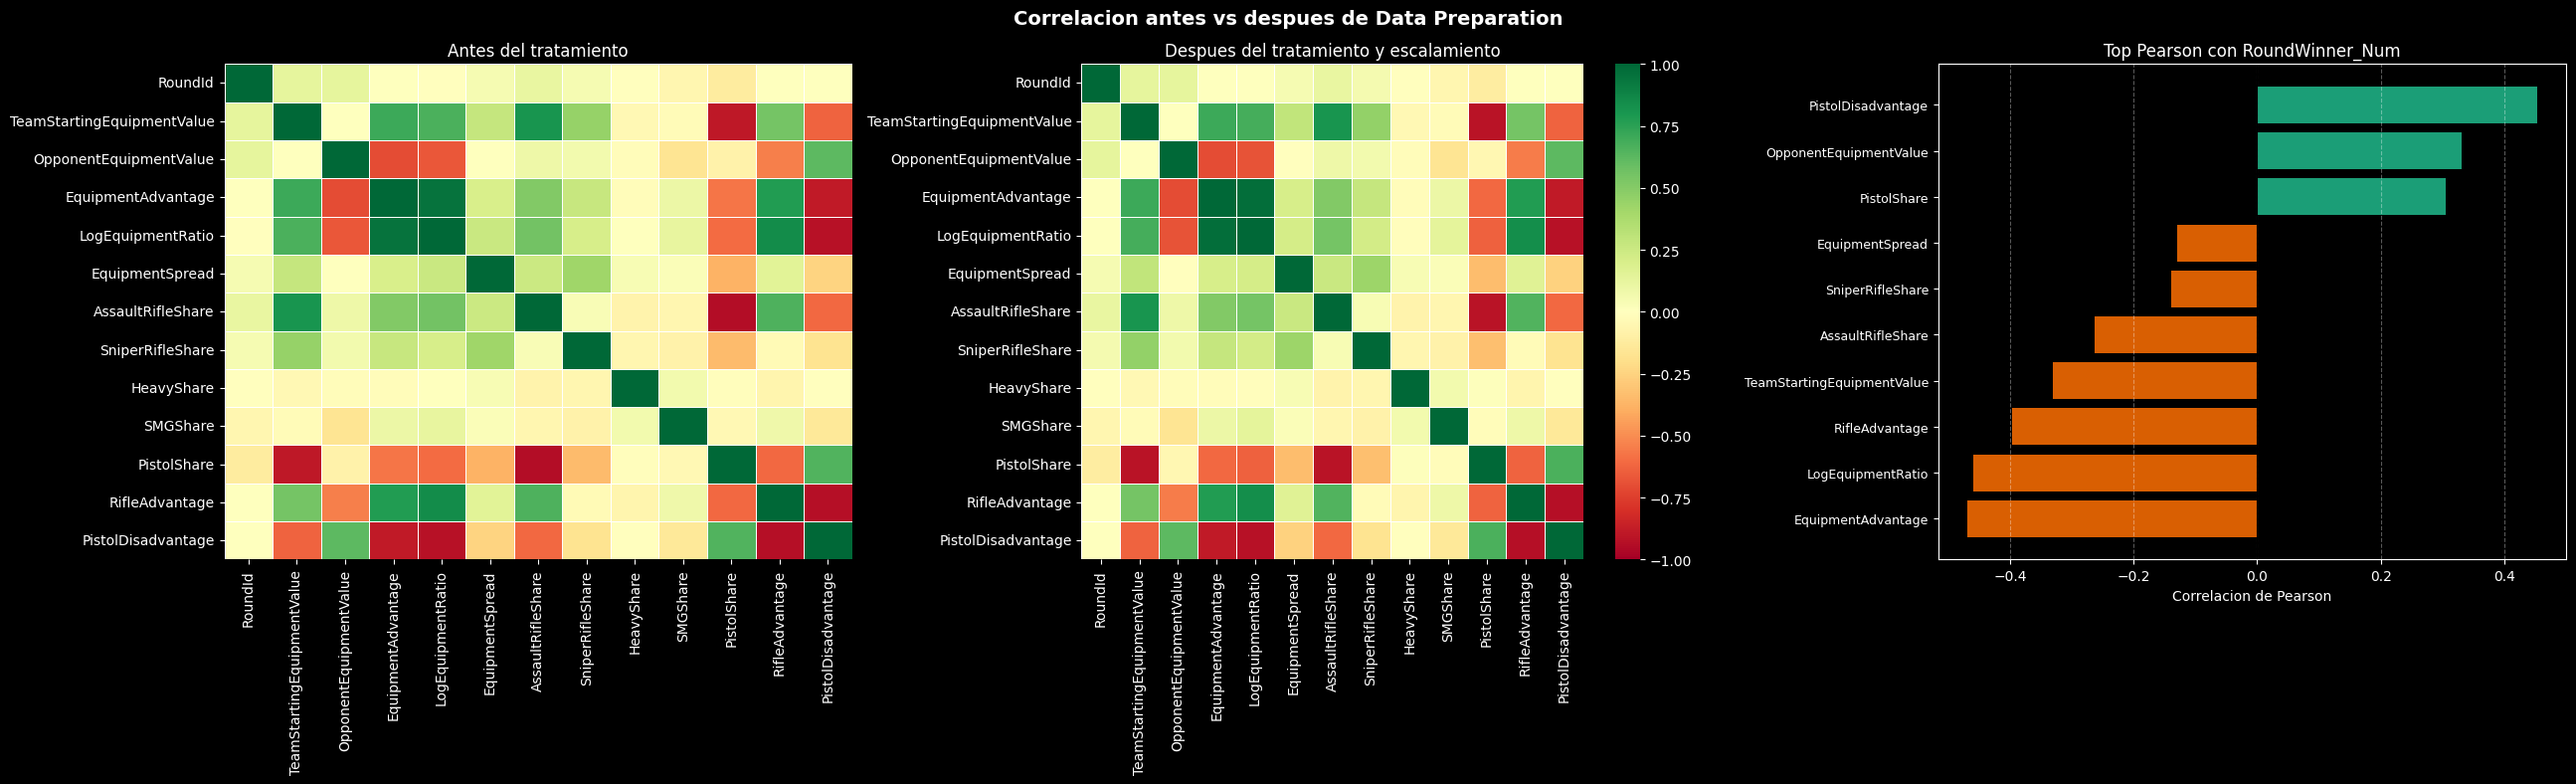

Diferencia absoluta promedio entre matrices: 0.0064
Diferencia absoluta maxima entre matrices: 0.0455

Top correlaciones de predictoras con RoundWinner_Num:
                            Pearson antes  Pearson despues  Diferencia  Abs Pearson despues
EquipmentAdvantage                -0.4698          -0.4698     -0.0000               0.4698
LogEquipmentRatio                 -0.4577          -0.4593     -0.0016               0.4593
PistolDisadvantage                 0.4537           0.4537      0.0000               0.4537
RifleAdvantage                    -0.3987          -0.3964      0.0023               0.3964
TeamStartingEquipmentValue        -0.3316          -0.3316      0.0000               0.3316
OpponentEquipmentValue             0.3306           0.3306     -0.0000               0.3306
PistolShare                        0.2980           0.3050      0.0069               0.3050
AssaultRifleShare                 -0.2626          -0.2626     -0.0000               0.2626
SniperRifleShar

In [41]:
corr_antes = X_train_clf_raw[numeric_features].corr().fillna(0)
corr_despues = X_train_clf[numeric_features].corr().fillna(0)

diff_corr = (corr_despues - corr_antes).abs()

corr_target_antes = (
    pd.concat([X_train_clf_raw[numeric_features], y_train_clf.rename('RoundWinner_Num')], axis=1)
    .corr(method='pearson')['RoundWinner_Num']
    .drop('RoundWinner_Num')
)
corr_target_despues = (
    pd.concat([X_train_clf[numeric_features], y_train_clf.rename('RoundWinner_Num')], axis=1)
    .corr(method='pearson')['RoundWinner_Num']
    .drop('RoundWinner_Num')
)

corr_target_comparacion = pd.DataFrame({
    'Pearson antes': corr_target_antes,
    'Pearson despues': corr_target_despues,
    'Diferencia': corr_target_despues - corr_target_antes
})
corr_target_comparacion['Abs Pearson despues'] = corr_target_comparacion['Pearson despues'].abs()
corr_target_comparacion = corr_target_comparacion.sort_values('Abs Pearson despues', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(26, 8))

sns.heatmap(
    corr_antes,
    ax=axes[0],
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    cbar=False
)
axes[0].set_title('Antes del tratamiento')
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    corr_despues,
    ax=axes[1],
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    cbar=True
)
axes[1].set_title('Despues del tratamiento y escalamiento')
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

top_corr_target = corr_target_comparacion['Pearson despues'].head(10).sort_values()
colors = ['#d95f02' if value < 0 else '#1b9e77' for value in top_corr_target]
axes[2].barh(top_corr_target.index, top_corr_target.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Top Pearson con RoundWinner_Num')
axes[2].set_xlabel('Correlacion de Pearson')
axes[2].tick_params(axis='y', labelsize=9)
axes[2].grid(axis='x', linestyle='--', alpha=0.35)

plt.suptitle('Correlacion antes vs despues de Data Preparation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Diferencia absoluta promedio entre matrices:', round(diff_corr.stack().mean(), 4))
print('Diferencia absoluta maxima entre matrices:', round(diff_corr.stack().max(), 4))
print('\nTop correlaciones de predictoras con RoundWinner_Num:')
print(corr_target_comparacion.round(4).head(10).to_string())
print('\nDiferencia absoluta entre matrices de correlacion:')
print(diff_corr.round(3).to_string())


**Analisis 3.7**

**Analisis del proceso 3.7:** La matriz de correlacion antes y despues permite revisar si la preparacion altero demasiado la estructura de relaciones entre predictoras. La diferencia absoluta promedio entre matrices es baja, cercana a 0,0058, lo que indica que el tratamiento conserva la forma general del dataset. La diferencia maxima ronda 0,0455, por lo que los cambios mas notorios siguen siendo pequenos.

El grafico muestra que las relaciones fuertes se mantienen principalmente en el bloque economico. `TeamStartingEquipmentValue`, `OpponentEquipmentValue`, `EquipmentAdvantage` y `LogEquipmentRatio` estan conectadas porque todas describen la economia propia o la economia relativa contra el rival. Esto confirma que la dimension economica es central, pero tambien advierte posible redundancia: no todas estas variables aportan informacion totalmente independiente.

La comparacion de Pearson con `RoundWinner_Num` muestra que las variables mas asociadas al target son `EquipmentAdvantage`, `LogEquipmentRatio`, `PistolDisadvantage`, `RifleAdvantage`, `TotalLethalGrenadesThrown`, `TeamStartingEquipmentValue` y `OpponentEquipmentValue`. En este dataset, varias correlaciones economicas aparecen con signo negativo respecto de la victoria. Esto no debe interpretarse como que invertir mas cause perder, sino como una senal de contexto: el bando, la economia rival, la situacion de la ronda y la definicion del registro influyen en la relacion observada.

`PistolDisadvantage` tiene relacion positiva con el target, mientras que `RifleAdvantage` aparece negativa. Este resultado es llamativo y refuerza que la lectura debe ser comparativa, no aislada. Las rondas con mas pistolas pueden corresponder a situaciones tacticas especificas o a diferencias de bando donde el resultado no depende solo del equipamiento. Por eso se mantienen variables de contexto como `Team`, `Map` e `InvestmentLevel`.

El grafico de barras ayuda a leer las predictoras frente a la variable objetivo: barras hacia la derecha indican relacion positiva con victoria y barras hacia la izquierda indican relacion negativa. La utilidad de Pearson aqui no es decidir por si solo que variables eliminar, sino entender el comportamiento inicial antes de modelar. En Fase 4, los modelos podran capturar combinaciones y relaciones no lineales que Pearson no ve.


### Conclusión Fase 3

La Fase 3 permite transformar el dataset original en una base mas coherente para modelado, pasando desde registros a nivel jugador-ronda hacia una unidad de analisis **equipo-ronda**. Esta decision es clave desde el punto de vista del negocio, porque el problema no busca evaluar jugadores aislados, sino apoyar decisiones estrategicas del equipo: cuanto invertir, que tipo de compra realizar, como influye el bando, como cambia el contexto por mapa y que ventaja o desventaja existe frente al rival.

Desde el punto de vista tecnico, la preparacion queda orientada a dos objetivos de Machine Learning. Para **clasificacion**, la variable objetivo principal es `RoundWinner_Num`, donde `1` representa victoria y `0` representa derrota. Para **regresion**, la variable objetivo es `AvgTeamTimeAliveSec`, que permite estimar el promedio de segundos de supervivencia del equipo durante la ronda.

Las variables predictoras seleccionadas tienen una justificacion clara. Las variables de **contexto** (`Map`, `Team`, `RoundId`) capturan diferencias tacticas entre mapas, bandos y momentos de la partida. Las variables de **economia** (`TeamStartingEquipmentValue`, `OpponentEquipmentValue`, `EquipmentAdvantage`, `LogEquipmentRatio`, `InvestmentLevel`) representan la capacidad de compra propia y rival. Las variables de **composicion tactica** (`AssaultRifleShare`, `PistolShare`, `RifleAdvantage`, `PistolDisadvantage`, `SniperRifleShare`, `SMGShare`) describen como esta armado el equipo y si su compra es mas fuerte o mas debil que la del oponente.

Metodologicamente, se aplicaron transformaciones adecuadas segun la naturaleza de cada dato. Las variables numericas se tratan con imputacion por **mediana**, porque la mediana es mas resistente a valores extremos que la media. Los outliers se controlan con **IQR Capping** y luego se usa **RobustScaler**, adecuado para variables economicas con rangos amplios. Las variables categoricas se imputan con **moda** y se transforman con **One-Hot Encoding**, evitando asignar un orden artificial a categorias como mapa, bando o nivel de inversion.

La division train/test tambien queda metodologicamente correcta. El preprocesamiento se ajusta solamente con los datos de entrenamiento y luego se aplica al conjunto de prueba. Esto evita fuga de informacion desde test hacia train. Para clasificacion se usa `stratify=y_clf`, manteniendo la proporcion de victorias y derrotas en ambos conjuntos.

Como resultado de este proceso, el dataset final cuenta con **16 variables predictoras antes de encoding** y **19 columnas despues del encoding**, con 0 valores nulos en los conjuntos transformados. La base final permite entrenar modelos de clasificacion para predecir victoria/derrota y modelos de regresion para estimar supervivencia promedio del equipo.

Como precaucion final, se excluyen de las predictoras variables que ocurren durante o despues de la ronda, como granadas lanzadas, kills y supervivencia observada directamente. Esta aclaracion demuestra control metodologico sobre la temporalidad de las variables y sobre el riesgo de fuga de informacion.

## Fase 4: Modeling


### Regresión

En esta subseccion se desarrolla solamente la tarea de regresion solicitada para la Fase 4. El objetivo es predecir `AvgTeamTimeAliveSec`, que representa el promedio de segundos de supervivencia del equipo en una ronda.

#### 4.1 Alcance del modelo de regresion

Antes de entrenar modelos, se deja documentada la tarea: target, predictoras y criterio de comparacion. Esto permite que el modelamiento sea auditable y que no se mezclen variables de clasificacion con variables de regresion.

In [42]:
regression_scope = pd.DataFrame({
    'Elemento': ['Target', 'Unidad de analisis', 'Predictoras', 'Criterio principal'],
    'Definicion': [
        'AvgTeamTimeAliveSec',
        'Equipo-ronda',
        f'{len(final_features)} variables antes de encoding',
        'Menor RMSE en test, revisando tambien MAE, MSE y R2'
    ]
})

print(regression_scope.to_string(index=False))

          Elemento                                          Definicion
            Target                                 AvgTeamTimeAliveSec
Unidad de analisis                                        Equipo-ronda
       Predictoras                      16 variables antes de encoding
Criterio principal Menor RMSE en test, revisando tambien MAE, MSE y R2


**Analisis 4.1:** El target seleccionado es continuo, por lo que corresponde a una tarea de regresion. La unidad equipo-ronda mantiene coherencia con la pregunta de negocio: evaluar condiciones tacticas y economicas de un equipo completo, no de jugadores aislados.

#### 4.2 Baseline de regresion

Se entrena un modelo base con `DummyRegressor`. Este modelo predice siempre la mediana del target y sirve como punto minimo de comparacion. Si los modelos reales no superan este baseline, no aportan valor predictivo.

In [43]:
baseline_reg = DummyRegressor(strategy='median')
baseline_reg.fit(X_train_reg_raw, y_train_reg)

y_pred_baseline = baseline_reg.predict(X_test_reg_raw)
baseline_mse = mean_squared_error(y_test_reg, y_pred_baseline)

baseline_result = pd.DataFrame([{
    'Modelo': f'Baseline - Mediana | {MODEL_RUN_TIMESTAMP}',
    'MAE_test': mean_absolute_error(y_test_reg, y_pred_baseline),
    'MSE_test': baseline_mse,
    'RMSE_test': np.sqrt(baseline_mse),
    'R2_test': r2_score(y_test_reg, y_pred_baseline)
}]).round(4)

print(baseline_result.to_string(index=False))

                               Modelo  MAE_test  MSE_test  RMSE_test  R2_test
Baseline - Mediana | 2026-05-23 12:40   21.6692 1388.0446    37.2565   -0.204


**Analisis 4.2:** El baseline no aprende patrones; solo entrega una referencia. Las tres alternativas de regresion deben evaluarse contra este valor para justificar que realmente aprovechan las variables de contexto, economia y armamento.

#### 4.3 Entrenamiento de tres modelos

Se comparan tres algoritmos alineados con el material del curso: `LinearRegression`, `DecisionTreeRegressor` y `RandomForestRegressor`. Los tres se entrenan mediante `Pipeline`, usando el mismo preprocesamiento para evitar diferencias artificiales entre modelos.

In [44]:
modelos_regresion = {
    f'Regresion - Lineal | {MODEL_RUN_TIMESTAMP}': LinearRegression(),
    f'Regresion - Arbol de decision | {MODEL_RUN_TIMESTAMP}': DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=25,
        random_state=42
    ),
    f'Regresion - Ensamble Random Forest | {MODEL_RUN_TIMESTAMP}': RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )
}

modelos_entrenados_reg = {}

for nombre_modelo, estimador in modelos_regresion.items():
    pipeline = Pipeline(steps=[
        ('preprocess', crear_preprocesador()),
        ('model', estimador)
    ])
    pipeline.fit(X_train_reg_raw, y_train_reg)
    modelos_entrenados_reg[nombre_modelo] = pipeline

print(f'Modelos entrenados: {len(modelos_entrenados_reg)}')
print('\n'.join(modelos_entrenados_reg.keys()))

Modelos entrenados: 3
Regresion - Lineal | 2026-05-23 12:40
Regresion - Arbol de decision | 2026-05-23 12:40
Regresion - Ensamble Random Forest | 2026-05-23 12:40


**Analisis 4.3:** La regresion lineal funciona como modelo interpretable y simple. El arbol de decision permite capturar cortes no lineales. Random Forest combina muchos arboles, por lo que suele ser mas estable que un arbol individual y es el candidato natural a mejor desempeno.

#### 4.4 Comparacion inicial de modelos

Se calculan `MAE`, `MSE`, `RMSE` y `R2` en entrenamiento y prueba. En esta fase se realiza una comparacion inicial; la interpretacion final mas profunda queda para Fase 5.

In [45]:
def metricas_regresion(nombre_modelo, modelo):
    pred_train = modelo.predict(X_train_reg_raw)
    pred_test = modelo.predict(X_test_reg_raw)
    mse_train = mean_squared_error(y_train_reg, pred_train)
    mse_test = mean_squared_error(y_test_reg, pred_test)
    return {
        'Modelo': nombre_modelo,
        'MAE_train': mean_absolute_error(y_train_reg, pred_train),
        'MAE_test': mean_absolute_error(y_test_reg, pred_test),
        'MSE_train': mse_train,
        'MSE_test': mse_test,
        'RMSE_train': np.sqrt(mse_train),
        'RMSE_test': np.sqrt(mse_test),
        'R2_train': r2_score(y_train_reg, pred_train),
        'R2_test': r2_score(y_test_reg, pred_test)
    }


resultados_regresion = pd.DataFrame([
    metricas_regresion(nombre, modelo)
    for nombre, modelo in modelos_entrenados_reg.items()
])

resultados_regresion = (
    pd.concat([baseline_result, resultados_regresion], ignore_index=True)
    .sort_values(['RMSE_test', 'MAE_test'])
    .reset_index(drop=True)
)

mejor_modelo_regresion = resultados_regresion.loc[0, 'Modelo']

print(resultados_regresion.round(4).to_string(index=False))
print(f'\nMejor modelo inicial segun RMSE_test: {mejor_modelo_regresion}')

                                               Modelo  MAE_test  MSE_test  RMSE_test  R2_test  MAE_train  MSE_train  RMSE_train  R2_train
                Regresion - Lineal | 2026-05-23 12:40   24.4394 1155.0955    33.9867  -0.0019    24.2425  1125.0999     33.5425    0.0040
Regresion - Ensamble Random Forest | 2026-05-23 12:40   24.5750 1163.7524    34.1138  -0.0095    22.0381   932.0232     30.5291    0.1749
     Regresion - Arbol de decision | 2026-05-23 12:40   24.5320 1189.5149    34.4893  -0.0318    23.4730  1073.6475     32.7666    0.0495
                Baseline - Mediana | 2026-05-23 12:40   21.6692 1388.0446    37.2565  -0.2040        NaN        NaN         NaN       NaN

Mejor modelo inicial segun RMSE_test: Regresion - Lineal | 2026-05-23 12:40


**Analisis 4.4:** La seleccion inicial se ordena por `RMSE_test`, porque esta metrica queda en segundos y penaliza mas los errores grandes. `MAE_test` complementa la lectura con el error absoluto promedio. `R2_test` ayuda a entender cuanta variabilidad explica el modelo, pero no se interpreta solo.

#### 4.5 Visualizacion del mejor modelo inicial

Se grafica valor real versus predicho para revisar si las predicciones siguen la tendencia general del target. Este grafico no reemplaza las metricas, pero ayuda a detectar rapidamente sesgos o dispersion excesiva.

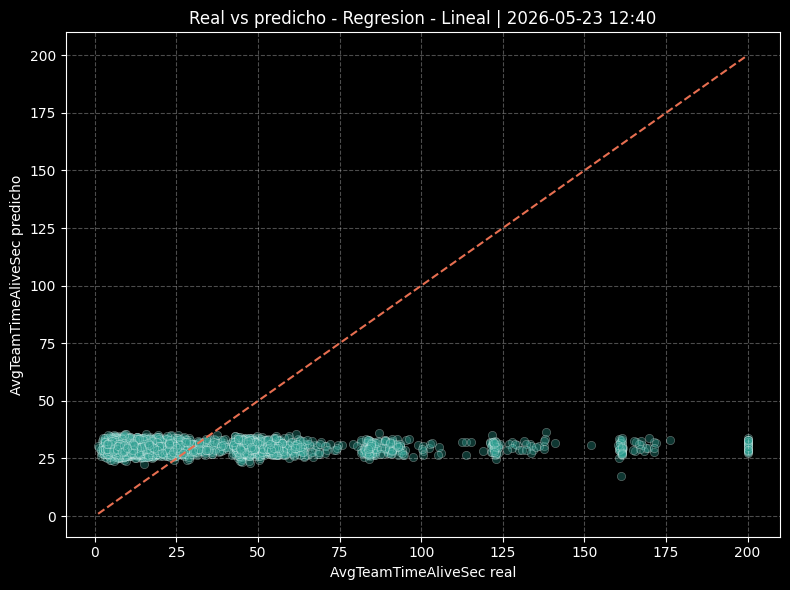

In [46]:
modelo_ganador_reg = modelos_entrenados_reg.get(mejor_modelo_regresion)

if modelo_ganador_reg is not None:
    y_pred_ganador = modelo_ganador_reg.predict(X_test_reg_raw)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test_reg, y=y_pred_ganador, alpha=0.35, color='#2a9d8f')
    limite_min = min(y_test_reg.min(), y_pred_ganador.min())
    limite_max = max(y_test_reg.max(), y_pred_ganador.max())
    plt.plot([limite_min, limite_max], [limite_min, limite_max], color='#e76f51', linestyle='--')
    plt.title(f'Real vs predicho - {mejor_modelo_regresion}')
    plt.xlabel('AvgTeamTimeAliveSec real')
    plt.ylabel('AvgTeamTimeAliveSec predicho')
    plt.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('El baseline quedo como mejor referencia; no se grafica modelo entrenado.')

**Analisis 4.5:** Si los puntos se acercan a la diagonal, el modelo reproduce mejor los valores reales. Si quedan muy dispersos, significa que las variables disponibles explican solo parte del fenomeno. Esta lectura sera retomada en Fase 5 para justificar el modelo seleccionado.

### Clasificación


In [47]:
# Insertar cuantos bloques de código consideren necesarios

# Realizar tarea de clasificación de datos orientado al caso entregado


## Fase 5: Evaluation


In [48]:
# Insertar cuantos bloques de código consideren necesarios

# Evaluar con las métricas que corresponda los mejores modelos, explicar cual es mejor para cada tarea y por qué


## Fase 5: Deployment


In [49]:
# Insertar cuantos bloques de código consideren necesarios

#dump para poder descargar / pickle libreria

# Realizar despliegue del modelo
